In [1]:
import sys
print(sys.executable)          # which Python / env this kernel actually uses
print(sys.version)
for pkg in ["pandas", "numpy", "matplotlib", "scikit-learn"]:
    try:
        mod = __import__("sklearn" if pkg == "scikit-learn" else pkg)
        print(f"{pkg:14s} {getattr(mod, '__version__', '?')}")
    except ImportError:
        print(f"{pkg:14s} MISSING")

C:\Users\conno\anaconda3\python.exe
3.13.9 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 19:09:58) [MSC v.1929 64 bit (AMD64)]
pandas         2.3.3
numpy          2.3.5
matplotlib     3.10.6
scikit-learn   1.7.2


In [2]:
### DELETE THE BELOW
# To resize the notebook
#from IPython.display import display, HTML
#display(HTML("<style>.container { width:90% !important; }</style>"))

In [3]:
# Import basic libraries 
import os 
import pandas as pd 
import numpy as np 
import scipy as sp 
import math

# Import plotting libraries 
import seaborn as sns
import matplotlib.pyplot as plt 
%matplotlib inline
# Set seaborn plotting attributes 
sns.set(context='talk',style='ticks',palette=sns.color_palette("husl"))

In [4]:
# Resolve the data folder relative to the repo (replaces os.chdir to local path)
from pathlib import Path

NB_DIR = Path.cwd()
REPO_ROOT = NB_DIR.parent if NB_DIR.name == "notebooks" else NB_DIR
_candidates = [
    REPO_ROOT / "data" / "metalearning_output_datasets",
    REPO_ROOT / "metalearning_output_datasets",
    REPO_ROOT / "data",
]
DATA_DIR = next((c for c in _candidates if c.exists() and any(c.glob("*.csv.gz"))), None)
assert DATA_DIR is not None, f"No .csv.gz found in: {[str(c) for c in _candidates]}"
print("DATA_DIR:", DATA_DIR)

DATA_DIR: C:\Users\conno\Documents\GitHub\ML_MetaLearning_SoftMatter\data


In [5]:
# Initialize dict to hold dataframes
df_dict = {}

# Make lists to store each file name and the total number of models produced 
names = []; trained_model_counts = []; total_rows = []; total_cols = []

# Go through each of the resulting file names 
for file in os.listdir(DATA_DIR):
    
    # If the filename contains "splits" you want to read it in and count the number of unique train/evaluation
    if "splits" in file:
        
        # Save the name of the file (specific materials dataset + ML problem followed by either in_splits or out_splits)
        file_name = file.split(".")[0]; names.append(file_name)
        
        # Read in the datafile
        data_frame = pd.read_csv(DATA_DIR / file, compression="gzip")
        
        # Correct iteration numbers for the first dataset (change 1,2,3, to 0,1,2)
        # >>> TEMP CLEANUP #1: to be fixed at the source, then this block gets removed <
        if "ext_qual_binary" in file_name:
            data_frame["iteration"] = data_frame["iteration"].map({1: 0, 2: 1, 3: 2})
        
        # Also store the number of trained models as well as the total number of rows (which includes both the training instances and the corresponding evaluation (val or test) instances)
        trained_model_counts.append(data_frame[data_frame["fold"] == "train"].shape[0])
        total_rows.append(data_frame.shape[0]); total_cols.append(data_frame.shape[1])
        
        # Add the dataframe to the dict and pair it with the appropriate filename key
        df_dict[file_name] = data_frame

# Break up the filenames for the outer and inner datasets (also save all of the filenames without the suffixes)
names_in_splits = [n for n in names if "in_splits" in n]
names_out_splits = [n for n in names if "out_splits" in n]
file_names = [*set([n.split("__")[0] for n in names])]; file_names.sort()

# Concatenate the results 
results_count = pd.DataFrame(data={"names": names, "trained_models": trained_model_counts,
                                   "total_rows": total_rows, "total_cols": total_cols})
print(round(results_count[results_count["names"].str.contains("in_splits")]["trained_models"].sum()/1e6, 3),
      "million model instances were trained and validated in the inner data splits of the nested CV")
print(round(results_count[results_count["names"].str.contains("out_splits")]["trained_models"].sum()/1e6, 3),
      "million model instances were trained and tested in the outer data splits of the nested CV")
print(round(results_count[results_count["names"].str.contains("in_splits")]["trained_models"].sum()/1e6, 3) +
      round(results_count[results_count["names"].str.contains("out_splits")]["trained_models"].sum()/1e6, 3),
      "million model instances were trained and evaluated in total")

18.79 million model instances were trained and validated in the inner data splits of the nested CV
0.783 million model instances were trained and tested in the outer data splits of the nested CV
19.573 million model instances were trained and evaluated in total


In [6]:
# Resolve the dataset-info sheet relative to the repo (replaces os.chdir to Dropbox).
# Robust to a couple of sensible locations so you can drop it in data/ or metadata/. ---
_info_candidates = [
    DATA_DIR / "basic_dataset_info.xlsx",
    REPO_ROOT / "metadata" / "basic_dataset_info.xlsx",
    REPO_ROOT / "basic_dataset_info.xlsx",
]
INFO_PATH = next((p for p in _info_candidates if p.exists()), None)
assert INFO_PATH is not None, f"basic_dataset_info.xlsx not found in: {[str(p) for p in _info_candidates]}"

# Read in the dataset information sheet
basic_info = pd.read_excel(INFO_PATH, index_col=0)

# Function to define the problem type and set of scoring metrics based on the filename
def define_problem_type(basic_info, file_name):

    # Extract the problem type (note: file_name cannot have the suffix (e.g. __in_splits or __out_splits) attached to it)
    problem_type = basic_info[basic_info['File_name'] == file_name]['Prob_type'].iloc[0]

    # Define model evaluation metrics according to problem type
    if problem_type == 'Binary Classification':
        scoring = ['accuracy', 'precision', 'recall', 'f1', 'balanced_accuracy', 'average_precision']

    elif problem_type == 'Multiclass Classification':
        scoring = ['accuracy', 'precision', 'recall', 'f1', 'balanced_accuracy']

    else:
        scoring = ['neg_mean_absolute_error', 'neg_median_absolute_error', 'neg_mean_absolute_percentage_error', 'r2', 'explained_variance', 'max_error']

    return problem_type, scoring

In [7]:
# Some regression instances produced error estimates that are billions-trillions of times greater than the actual range of the data
# To avoid skewing the analysis, filter out erroneous results beforehand by rejecting any model instance with an MAE 2X the dataset range

# Function to filter out failed model instances
def remove_erroneous_results(in_splits, out_splits, basic_info, file_name, problem_type, mult_factor):

    # Get the range of the outputs for the input dataset
    output_range = basic_info[basic_info['File_name'] == file_name]['Range'].values[0]

    # These model instances have MAE values more extreme than 2x the total range of actual outputs that could be predicted (will completely skew analysis)
    # These instances also have MAPE values more extreme than 1000% and r2 values more extreme than -1000
    in_splits_removed = in_splits[(in_splits['neg_mean_absolute_error'] < (-2*output_range)) & (in_splits['neg_mean_absolute_percentage_error'] < -1e3) & (in_splits['r2'] < -1e3)]
    out_splits_removed = out_splits[(out_splits['neg_mean_absolute_error'] < (-2*output_range)) & (out_splits['neg_mean_absolute_percentage_error'] < -1e3) & (out_splits['r2'] < -1e3)]

    # These model instances have MAE and MedAE within 2x the range of outputs and have MAPE<1000% and r2>-1000 (any erroneous values are replaced by NaN and ignored by pandas and seaborn)
    #in_splits = in_splits[(in_splits['neg_mean_absolute_error']>(-2*output_range)) & (in_splits['neg_mean_absolute_percentage_error']>-1e3) & (in_splits['r2']>-1e3)]
    #out_splits = out_splits[(out_splits['neg_mean_absolute_error']>(-2*output_range)) & (out_splits['neg_mean_absolute_percentage_error']>-1e3) & (out_splits['r2']>-1e3)]

    # Assign back instead of .mask(..., inplace=True): chained inplace masking is unreliable under
    # pandas 2.x (can silently no-op / raises ChainedAssignmentError). Same result, done safely.
    in_splits['neg_mean_absolute_error'] = in_splits['neg_mean_absolute_error'].mask(in_splits['neg_mean_absolute_error'] < (-2*output_range))
    in_splits['neg_median_absolute_error'] = in_splits['neg_median_absolute_error'].mask(in_splits['neg_median_absolute_error'] < (-2*output_range))
    in_splits['neg_mean_absolute_percentage_error'] = in_splits['neg_mean_absolute_percentage_error'].mask(in_splits['neg_mean_absolute_percentage_error'] < -1e3)
    in_splits['r2'] = in_splits['r2'].mask(in_splits['r2'] < -1e3)
    in_splits['explained_variance'] = in_splits['explained_variance'].mask(in_splits['explained_variance'] < -1e3)
    in_splits['max_error'] = in_splits['max_error'].mask(in_splits['max_error'] < (-2*output_range))

    out_splits['neg_mean_absolute_error'] = out_splits['neg_mean_absolute_error'].mask(out_splits['neg_mean_absolute_error'] < (-2*output_range))
    out_splits['neg_median_absolute_error'] = out_splits['neg_median_absolute_error'].mask(out_splits['neg_median_absolute_error'] < (-2*output_range))
    out_splits['neg_mean_absolute_percentage_error'] = out_splits['neg_mean_absolute_percentage_error'].mask(out_splits['neg_mean_absolute_percentage_error'] < -1e3)
    out_splits['r2'] = out_splits['r2'].mask(out_splits['r2'] < -1e3)
    out_splits['explained_variance'] = out_splits['explained_variance'].mask(out_splits['explained_variance'] < -1e3)
    out_splits['max_error'] = out_splits['max_error'].mask(out_splits['max_error'] < (-2*output_range))

    return in_splits, out_splits, in_splits_removed, out_splits_removed

# ##################################
# # Run the remove_erroneous_results if the problem type is a regression so you can filter out failed model instances that will skew results

In [8]:
# Function to calculate means, medians, stds, IQRs, for train and test 
def aggregated_stats(dataframe,scoring,stats,loop):

  df = dataframe.copy()
  
  i=0; list_for_stats = []
  # Go through each of the descriptive statistics in the list 
  for stat in stats: 

    # For the first result, save the computed stats AND all of the relevant dimensions
    if i==0:
      if loop=='inner':
        
        # Define the set of dimensions you want to groupby so you can generate aggregated stats across the remaining non-grouping columns 
        aggregator = ['iteration','outer_k','outer_split','inner_k','fold','algorithm','model_config_id','params']
        
        # For the inner loop data, drop 'inner split' columns since you're aggregating across these
        result = df.groupby(aggregator,as_index=False,sort=False).agg(stat).drop(columns={'inner_split'}).rename(columns=dict(zip(scoring,[stat+'_'+score for score in scoring])))

      if loop=='outer': 
        
        # Define the set of dimensions you want to groupby so you can generate aggregated stats across the remaining non-grouping columns 
        aggregator = ['iteration','outer_k','fold','algorithm','model_config_id','params']
        
        # For the outer loop data, drop 'outer split' columns since you're aggregating across these
        result = df.groupby(aggregator,as_index=False,sort=False).agg(stat).drop(columns={'outer_split'}).rename(columns=dict(zip(scoring,[stat+'_'+score for score in scoring])))

    # For the rest of the results, just save the computed stats 
    if i>0:
      result = df.groupby(aggregator,as_index=False,sort=False).agg(stat)[scoring].rename(columns=dict(zip(scoring,[stat+'_'+score for score in scoring])))

    # Add the computed stat to the list
    list_for_stats.append(result); i+=1

  # Compile all stats into a single aggregated dataframe
  agg_stats_df = pd.concat(list_for_stats,axis=1)

  return agg_stats_df

# ##################################
# # Use the aggregated_stats function to compute the aggregated stats for each grouping for the inner and outer loops


In [9]:
# Function to assign default configurations based on param vectors (no preprocessing of data for standard configs)
def assign_default(dataframe, problem_type):
  
  df=dataframe.copy()
  
  # Assign the default classifier configurations 
  if problem_type == 'Binary Classification' or problem_type == 'Multiclass Classification':

    # LINEAR MODEL
    default_string = "{'algo__alpha': 0.0001, 'algo__class_weight': None, 'algo__loss': 'hinge', 'algo__penalty': 'l2', 'preprocess': 'passthrough'}"
    df.loc[(df['algorithm']=='LR') & (df['params']==default_string),'default_config']='default'

    # GAUSSIAN PROCESS
    default_string = "{'algo__kernel': RBF(length_scale=1), 'preprocess': 'passthrough'}"
    df.loc[(df['algorithm']=='GP') & (df['params']==default_string),'default_config']='default'

    # K-NEAREST NEIGHBORS
    default_string = "{'algo__n_neighbors': 5, 'algo__p': 2, 'algo__weights': 'uniform', 'preprocess': 'passthrough'}"
    df.loc[(df['algorithm']=='KNN') & (df['params']==default_string),'default_config']='default'

    # SUPPORT VECTOR MACHINE
    default_string = "{'algo__C': 1, 'algo__class_weight': None, 'algo__kernel': 'rbf', 'preprocess': 'passthrough'}"
    df.loc[(df['algorithm']=='SVM') & (df['params']==default_string),'default_config']='default'

    # RANDOM FOREST
    default_string = "{'algo__class_weight': None, 'algo__max_features': 'sqrt', 'algo__min_samples_leaf': 1, 'algo__n_estimators': 100, 'preprocess': 'passthrough'}"
    df.loc[(df['algorithm']=='RF') & (df['params']==default_string),'default_config']='default'

    # GRADIENT BOOSTING
    default_string = "{'algo__learning_rate': 0.1, 'algo__min_samples_leaf': 1, 'algo__n_estimators': 100, 'algo__subsample': 1.0, 'preprocess': 'passthrough'}"
    df.loc[(df['algorithm']=='GB') & (df['params']==default_string),'default_config']='default'

    # MULTILAYER PERCEPTRON (NEURAL NETWORK)
    default_string = "{'algo__alpha': 0.0001, 'algo__hidden_layer_sizes': (100,), 'algo__learning_rate_init': 0.001, 'preprocess': 'passthrough'}"
    df.loc[(df['algorithm']=='MLP') & (df['params']==default_string),'default_config']='default'

  # Assign the default regressor configurations
  else: 

    # LINEAR MODEL
    #default_string = "{'algo__alpha': 0.0001, 'algo__loss': 'squared_error', 'algo__penalty': 'l2', 'algo__shuffle': True, 'preprocess': 'passthrough'}" -> note: linear models failed to converge for the regression problems if preprocess==passthrough
    default_string = "{'algo__alpha': 0.0001, 'algo__loss': 'squared_error', 'algo__penalty': 'l2', 'algo__shuffle': True, 'preprocess': MinMaxScaler()}" # note: just for linear models, use MinMaxScaler() as the default
    df.loc[(df['algorithm']=='LR') & (df['params']==default_string),'default_config']='default'

    # GAUSSIAN PROCESS
    default_string = "{'algo__kernel': 1**2 * RBF(length_scale=1), 'algo__normalize_y': False, 'preprocess': 'passthrough'}"
    df.loc[(df['algorithm']=='GP') & (df['params']==default_string),'default_config']='default'

    # K-NEAREST NEIGHBORS
    default_string = "{'algo__n_neighbors': 5, 'algo__p': 2, 'algo__weights': 'uniform', 'preprocess': 'passthrough'}"
    df.loc[(df['algorithm']=='KNN') & (df['params']==default_string),'default_config']='default'

    # SUPPORT VECTOR MACHINE
    default_string = "{'algo__C': 1, 'algo__epsilon': 0.1, 'algo__kernel': 'rbf', 'preprocess': 'passthrough'}"
    df.loc[(df['algorithm']=='SVM') & (df['params']==default_string),'default_config']='default'

    # RANDOM FOREST
    default_string = "{'algo__max_features': None, 'algo__min_samples_leaf': 1, 'algo__n_estimators': 100, 'preprocess': 'passthrough'}"
    df.loc[(df['algorithm']=='RF') & (df['params']==default_string),'default_config']='default'

    # GRADIENT BOOSTING
    default_string = "{'algo__learning_rate': 0.1, 'algo__min_samples_leaf': 1, 'algo__n_estimators': 100, 'algo__subsample': 1.0, 'preprocess': 'passthrough'}"
    df.loc[(df['algorithm']=='GB') & (df['params']==default_string),'default_config']='default'

    # MULTILAYER PERCEPTRON (NEURAL NETWORK)
    default_string = "{'algo__alpha': 0.0001, 'algo__hidden_layer_sizes': (100,), 'algo__learning_rate_init': 0.001, 'preprocess': 'passthrough'}"
    df.loc[(df['algorithm']=='MLP') & (df['params']==default_string),'default_config']='default'

  # Also fill remaining NaN spaces with 'alt' 
  df['default_config'] = df['default_config'].fillna('alt')

  return df

# ##################################
# # Use the assign_default function to assign the default configurations for each algorithm

In [10]:
# Function to perform rankings for AS (identify top-performing default algos), HPO (identify top-performing configurations on per-algorithm basis), CASH (identify top-performing algorithms AND configurations)
def as_hpo_cash_ranks(dataframe,scoring,loop):
  
  df=dataframe.copy()
  
  if loop=='inner':
    
    as_ranks = df[df['default_config']=='default'].groupby(['iteration','outer_k','outer_split','inner_k','fold',],as_index=False,sort=False).rank(ascending=False,method='min')
    as_ranks = as_ranks[['mean_'+score for score in scoring]].rename(columns=dict(zip(['mean_'+score for score in scoring],['rank_as_mean_'+score for score in scoring])))

    hpo_ranks = df.groupby(['iteration','outer_k','outer_split','inner_k','fold','algorithm',],as_index=False,sort=False).rank(ascending=False,method='min')
    hpo_ranks = hpo_ranks[['mean_'+score for score in scoring]].rename(columns=dict(zip(['mean_'+score for score in scoring],['rank_hpo_mean_'+score for score in scoring])))

    cash_ranks = df.groupby(['iteration','outer_k','outer_split','inner_k','fold',],as_index=False,sort=False).rank(ascending=False,method='min')
    cash_ranks = cash_ranks[['mean_'+score for score in scoring]].rename(columns=dict(zip(['mean_'+score for score in scoring],['rank_cash_mean_'+score for score in scoring])))
    
  if loop=='outer':
    
    as_ranks = df[df['default_config']=='default'].groupby(['iteration','outer_k','fold',],as_index=False,sort=False).rank(ascending=False,method='min')
    as_ranks = as_ranks[['mean_'+score for score in scoring]].rename(columns=dict(zip(['mean_'+score for score in scoring],['rank_as_mean_'+score for score in scoring])))

    hpo_ranks = df.groupby(['iteration','outer_k','fold','algorithm',],as_index=False,sort=False).rank(ascending=False,method='min')
    hpo_ranks = hpo_ranks[['mean_'+score for score in scoring]].rename(columns=dict(zip(['mean_'+score for score in scoring],['rank_hpo_mean_'+score for score in scoring])))

    cash_ranks = df.groupby(['iteration','outer_k','fold',],as_index=False,sort=False).rank(ascending=False,method='min')
    cash_ranks = cash_ranks[['mean_'+score for score in scoring]].rename(columns=dict(zip(['mean_'+score for score in scoring],['rank_cash_mean_'+score for score in scoring])))
    
  compiled = pd.concat([df,as_ranks,hpo_ranks,cash_ranks],axis=1)
  
  return compiled 

# ##################################
# # Use the as_hpo_cash_ranks function to perform the AS ranking, HPO ranking, and CASH rankings for each grouping for the inner and outer loops

In [11]:
# >>> FLAG (revisit before first real run): this min/max swap is buggy AND may be dead code.
#     Check whether min_/max_ aggregate columns actually exist. If not -> delete this block.
#     If yes -> replace with the collision-safe version. See worklog.

# NOTE: THE BELOW TEXT WAS TRANSFERRED AS-IS FROM THE OLD NOTEBOOK --> THE "SAFER" EDIT HAS NOT YET BEEN IMPLEMENTED

# Function to modify the scores for the regression problems since everything is negative (for ranking) and the names are too long
def modify_regression_datasets(dataframe):

    df = dataframe.copy()

    # Go through the columns and flip the signs of the negative columns (as long as they aren't the computed stds or the ranks because those are already positive)
    for col in df.columns:
        if 'neg_' in col:
            if 'std_' in col or 'rank_' in col:
                pass
            else:
                df[col] = -1 * df[col]

    # # Replace the extended column names with shorter names
    df.columns = [col.replace('neg_mean_absolute_error', 'MAE') for col in df.columns]
    df.columns = [col.replace('neg_median_absolute_error', 'MedAE') for col in df.columns]
    df.columns = [col.replace('neg_mean_absolute_percentage_error', 'MAPE') for col in df.columns]

    # Flip the min and max columns as well (min/max were applied to the negative scoring metrics, so max becomes min and min becomes max)
    # NOTE: only the sign-FLIPPED error metrics (MAE/MedAE/MAPE) need swapping. r2 (and explained_variance)
    # were never negative, so their min/max are already correct -> do NOT swap them. Collision-safe explicit
    # swap replaces the original positional-zip rename (which was fragile AND wrongly swapped r2's min/max).
    rename_map = {}
    for m in ['MAE', 'MedAE', 'MAPE']:
        lo, hi = 'min_' + m, 'max_' + m
        if lo in df.columns and hi in df.columns:
            rename_map[lo] = '__TMP_max_' + m   # min_<m> holds the max error after the sign flip
            rename_map[hi] = 'min_' + m         # max_<m> holds the min error after the sign flip
    df = df.rename(columns=rename_map)
    df.columns = [col.replace('__TMP_', '') for col in df.columns]

    return df

# ##################################
# # If the problem type is a regression, run the function to modify the dataframes (shorten the names and flip the signs of the negative error metrics (negative was used for ranking purposes))


In [12]:
# >>> FLAG 1 (schema): nested_cv is added to INNER frames only (outer has no inner_k).
#     Intended. If any later cell concatenates inner+outer or expects nested_cv on all
#     four frames, revisit — may need an outer-only label. See worklog.

# >>> FLAG 2 (fold labels): both inner-validation AND outer-testing folds are labeled 'val'.
#     Decide on a consistent scheme once we see the processing cells; may be intentional,
#     may be a relabel. Affects any plot that filters on a hardcoded fold string. See worklog.

# Function to generate additional unique ids to help with plotting and analysis
def combined_ids(in_splits,in_agg,out_splits,out_agg): 

  # To make a combined identifier that covers both the algorithm (e.g. algorithm=LR) and the specific configuration (e.g. model_config_id=23) -> (combo_id = LR23)

  in_splits['combo_id'] = [algo+str(config_id) for algo,config_id in zip(in_splits['algorithm'],in_splits['model_config_id'])]
  in_agg['combo_id'] = [algo+str(config_id) for algo,config_id in zip(in_agg['algorithm'],in_agg['model_config_id'])]
  out_splits['combo_id'] = [algo+str(config_id) for algo,config_id in zip(out_splits['algorithm'],out_splits['model_config_id'])]
  out_agg['combo_id'] = [algo+str(config_id) for algo,config_id in zip(out_agg['algorithm'],out_agg['model_config_id'])]


  # To make a combined identifier for the location of the fold (e.g. inner_train, inner_val, outer_train, outer_val) 

  in_splits['loopfold'] = 'inner_'+in_splits['fold']; 
  in_agg['loopfold'] = 'inner_'+in_agg['fold']
  out_splits['loopfold'] = 'outer_'+out_splits['fold']
  out_agg['loopfold'] = 'outer_'+out_agg['fold']


  # To make a combined identifier for the nested cv (e.g. if outer_k is 3 and inner_k is 4 then nested_cv = 3x4)

  in_splits['nested_cv'] = [str(outer_k)+'x'+str(inner_k) for outer_k,inner_k in zip(in_splits['outer_k'],in_splits['inner_k'])]
  in_agg['nested_cv'] = [str(outer_k)+'x'+str(inner_k) for outer_k,inner_k in zip(in_agg['outer_k'],in_agg['inner_k'])]
  
  return in_splits,in_agg,out_splits,out_agg

# ##################################
# # Run the combined_ids function to generate additional unique identifiers to facilitate analysis and plotting 

In [13]:
# >>> FLAG (porting): uses undefined GLOBAL `scores_to_analyze` (like `problem_type` in
#     assign_default). Works only if the call site sets it before calling. When porting to
#     utils, make it an explicit parameter: combine_inner_and_outer(..., scores_to_analyze).

# Function to produce combined dataframes which contain information from both the outer and inner construction/evaluation schemes 

def combine_inner_and_outer(in_agg,out_agg,out_splits,problem_type,scores_to_analyze):

  # Concatenate the in_agg and out_agg data (just stack them on top of each other) -> maintain tidy format... useful for some types of analysis and plotting

  in_agg_out_agg_concat = pd.concat([in_agg,out_agg]).reset_index(drop=True)


  # Merge the in_agg and out_splits data (merge left) -> pair the top inner results with the corresponding outer split results that you would get if you used refit=True in normal search protocol
  temp = out_splits[out_splits['fold']=='test'].rename(columns=dict(zip([score for score in scores_to_analyze],['outer_'+score for score in scores_to_analyze])))

  in_agg_out_splits_merge = in_agg[in_agg['fold']=='val'].merge(temp[['iteration','outer_k','outer_split','combo_id',*['outer_'+score for score in scores_to_analyze]]],
                                                                on=['iteration','outer_k','outer_split','combo_id',],
                                                                how='left').reset_index(drop=True)

  # Merge the in_agg and out_agg data (stack them sideways) -> break tidy format and provide different names to each column -> useful for some types of analysis and plotting
  # Look at the columns and copy the regression-related scores and ranks columns (need to be present in both in_agg and out_agg); 

  if problem_type == 'Binary Classification' or problem_type == 'Multiclass Classification':
    means_and_ranks = ['mean_accuracy', 'mean_precision', 'mean_recall', 'mean_f1',
                       'median_accuracy', 'median_precision', 'median_recall', 'median_f1',
                       'std_accuracy', 'std_precision', 'std_recall', 'std_f1', 
                       'max_accuracy','max_precision', 'max_recall', 'max_f1', 
                       'min_accuracy','min_precision', 'min_recall', 'min_f1',
                       'rank_as_mean_accuracy', 'rank_as_mean_precision','rank_as_mean_recall', 'rank_as_mean_f1', 
                       'rank_hpo_mean_accuracy','rank_hpo_mean_precision', 'rank_hpo_mean_recall', 'rank_hpo_mean_f1',
                       'rank_cash_mean_accuracy', 'rank_cash_mean_precision','rank_cash_mean_recall', 'rank_cash_mean_f1',]
  
# >>> NOTE: intentionally carries a metric subset (drops balanced_accuracy/average_precision for
#     classification, explained_variance/max_error for regression) to narrow the analysis space.
    
  if problem_type=='Cross-Section Regression' or problem_type=='Panel Regression':
    means_and_ranks = ['mean_MAE', 'mean_MedAE', 'mean_MAPE','mean_r2', 
                       'median_MAE', 'median_MedAE', 'median_MAPE', 'median_r2',
                       'std_MAE', 'std_MedAE', 'std_MAPE', 'std_r2', 
                       'max_MAE', 'max_MedAE','max_MAPE', 'max_r2', 
                       'min_MAE', 'min_MedAE', 'min_MAPE', 'min_r2', 
                       'rank_as_mean_MAE', 'rank_as_mean_MedAE','rank_as_mean_MAPE', 'rank_as_mean_r2', 
                       'rank_hpo_mean_MAE','rank_hpo_mean_MedAE', 'rank_hpo_mean_MAPE', 'rank_hpo_mean_r2',
                       'rank_cash_mean_MAE', 'rank_cash_mean_MedAE', 'rank_cash_mean_MAPE','rank_cash_mean_r2',]

  # Make temporary dataframes for each fold of in_agg where the means and ranks columns have been renamed (based on the inner fold (train or val))
  temp_itrn=in_agg[in_agg['fold']=='train'].rename(columns=dict(zip([col for col in means_and_ranks],['itrn_'+col for col in means_and_ranks])))
  temp_ival=in_agg[in_agg['fold']=='val'].rename(columns=dict(zip([col for col in means_and_ranks],['ival_'+col for col in means_and_ranks])))

  # Merge the two renamed inner dataframes 
  temp_in = temp_itrn.merge(temp_ival[['iteration','outer_k','outer_split','inner_k','combo_id',*['ival_'+col for col in means_and_ranks]]],
                            on=['iteration','outer_k','outer_split','inner_k','combo_id'],how='left').reset_index(drop=True)

  # Make temporary dataframes for each fold of out_agg where the means and ranks columns have been renamed (based on the outer fold (train or test))
  temp_otrn=out_agg[out_agg['fold']=='train'].rename(columns=dict(zip([col for col in means_and_ranks],['otrn_'+col for col in means_and_ranks])))
  temp_otst=out_agg[out_agg['fold']=='test'].rename(columns=dict(zip([col for col in means_and_ranks],['otst_'+col for col in means_and_ranks])))

  # Merge the two renamed outer dataframes 
  temp_out = temp_otrn.merge(temp_otst[['iteration','outer_k','combo_id',*['otst_'+col for col in means_and_ranks]]],
                             on=['iteration','outer_k','combo_id'],how='left').reset_index(drop=True)

# >>> FLAG (analysis): outer means/ranks are DUPLICATED across inner splits and inner_k values
#     when broadcast onto the finer inner rows (see note below). De-duplicate on the outer keys
#     (iteration, outer_k, combo_id) BEFORE averaging/counting over this frame, or outer values
#     get multiply-counted. Applies to anything built on in_agg_out_agg_merge.
    
  # Put everything together -> now you can follow the aggregated scores and ranks across all folds (train-val-train-test) across all iterations and all outer k values 
  # Note, outer means/ranks are duplicated for different outer splits and different inner k values because those dimensions are only applicable to the inner loops
  in_agg_out_agg_merge = temp_in.merge(temp_out[['iteration','outer_k','combo_id',*['otrn_'+col for col in means_and_ranks],*['otst_'+col for col in means_and_ranks]]],
                                       on=['iteration','outer_k','combo_id'],how='left').reset_index(drop=True)
  
  return in_agg_out_agg_concat, in_agg_out_splits_merge, in_agg_out_agg_merge

# ##################################
# # Run combine_inner_and_outer to generate combined dataframes (simple concatention of inner_agg and outer_agg, merging of inner_agg and outer_splits for performance evaluations, merging of in_agg and out_agg with performance evaluations and rankings)


In [14]:
# Go through each file and produce the processed datasets (in_splits,out_splits,in_agg,out_agg,in_agg_out_agg_concat,in_agg_out_splits_merge,in_agg_out_agg_merge)

# Initialize the dicts to hold all of the results
problem_type_dict={}; scores_to_analyze_dict={}; in_splits_dict={};out_splits_dict={};in_agg_dict={};out_agg_dict={}; in_agg_out_agg_concat_dict={}; in_agg_out_splits_merge_dict={}; in_agg_out_agg_merge_dict={};

# Iterate through and assign file names 
for file_name in file_names:
  print('---',file_name)
  
  ################################## 
  # Get the split-by-split inner and outer data from the appropriate dicts (the datasets) and rearrange the datasets so you have train,val for the inner and train,test for the outer 
  in_splits = df_dict[file_name+'__in_splits']; out_splits = df_dict[file_name+'__out_splits']; 
  in_splits = pd.concat([in_splits[in_splits['fold']=='train'],in_splits[in_splits['fold']=='val']]); out_splits = pd.concat([out_splits[out_splits['fold']=='train'],out_splits[out_splits['fold']=='test']])

  ##################################
  # Run the define_problem_type function to assign the ML problem type and corresponding scoring metrics 
  problem_type, scoring = define_problem_type(basic_info,file_name)

  ##################################
  # Run the remove_erroneous_results (if the problem type is a regression) so you can filter out failed model instances that will skew results
  if problem_type=='Cross-Section Regression' or problem_type=='Panel Regression':
    mult_factor=2; in_splits,out_splits,_,_ = remove_erroneous_results(in_splits,out_splits,basic_info,file_name,problem_type,mult_factor)
  
  ##################################
  # Run the aggregated_stats function to compute the aggregated stats for each grouping for the inner and outer loops (need to define the stats you want and the scoring metrics that you actually want to analyze)
  stats = ['mean','median','std','max','min']; scores_to_analyze = scoring[:4]
  in_agg = aggregated_stats(in_splits,scores_to_analyze,stats,'inner').drop(columns=[score for score in scoring if score not in scores_to_analyze]); out_agg = aggregated_stats(out_splits,scores_to_analyze,stats,'outer').drop(columns=[score for score in scoring if score not in scores_to_analyze])

  ##################################
  # Run the assign_default function to assign the default configurations for each algorithm
  in_agg = assign_default(in_agg); out_agg = assign_default(out_agg)

  ##################################
  # Run the as_hpo_cash_ranks function to perform the AS ranking, HPO ranking, and CASH rankings for each grouping for the inner and outer loops
  in_agg = as_hpo_cash_ranks(in_agg,scores_to_analyze,'inner'); out_agg = as_hpo_cash_ranks(out_agg,scores_to_analyze,'outer')

  ##################################
  # If the problem type is a regression, run the modify_regression_datasets function to shorten the score names and flip the signs of the negative error metrics (negative was used for ranking purposes)) -> also redefine the scores_to_analyze list
  if problem_type=='Cross-Section Regression' or problem_type=='Panel Regression':
    in_splits = modify_regression_datasets(in_splits); in_agg = modify_regression_datasets(in_agg); out_splits = modify_regression_datasets(out_splits); out_agg = modify_regression_datasets(out_agg); scores_to_analyze = ['MAE','MedAE','MAPE','r2']

  ##################################
  # Run the combined_ids function to generate additional unique identifiers to facilitate analysis and plotting 
  in_splits,in_agg,out_splits,out_agg = combined_ids(in_splits,in_agg,out_splits,out_agg)

  ##################################
  # Run combine_inner_and_outer to generate combined dataframes (simple concatention of inner_agg and outer_agg, merging of inner_agg and outer_splits for performance evaluations, merging of in_agg and out_agg with performance evaluations and rankings)
  in_agg_out_agg_concat, in_agg_out_splits_merge, in_agg_out_agg_merge = combine_inner_and_outer(in_agg,out_agg,out_splits,problem_type)
  
  ##################################
  # Add the processed outputs/dataframes to their corresponding dicts and pair them with the appropriate filename key 
  problem_type_dict[file_name]=problem_type; scores_to_analyze_dict[file_name]=scores_to_analyze;
  in_splits_dict[file_name]=in_splits; out_splits_dict[file_name]=out_splits; in_agg_dict[file_name]=in_agg; out_agg_dict[file_name]=out_agg
  in_agg_out_agg_concat_dict[file_name]=in_agg_out_agg_concat; in_agg_out_splits_merge_dict[file_name]=in_agg_out_splits_merge; in_agg_out_agg_merge_dict[file_name]=in_agg_out_agg_merge;

--- ext_qual_binary
--- ext_qual_failure_mode
--- ext_qual_filament_outcome
--- ext_quant_avg_force
--- ext_quant_avg_force_under4
--- ext_quant_curves
--- ext_quant_max_force
--- ext_quant_max_force_under5
--- ext_quant_stability
--- ext_quant_std_force
--- microgel_formation
--- microgel_init_size
--- microgel_jamming_curves
--- microgel_jamming_curves_over08
--- microgel_shape
--- microgel_size_evolution
--- microgel_size_evolution_under300
--- rheo_osc_plateau_loss
--- rheo_osc_plateau_loss_under20
--- rheo_osc_plateau_storage
--- rheo_osc_plateau_storage_over1000
--- rheo_osc_strain_loss_curves
--- rheo_osc_strain_storage_curves
--- rheo_osc_stress_loss_curves
--- rheo_osc_stress_storage_curves
--- rheo_osc_yield_strain
--- rheo_osc_yield_strain_over10
--- rheo_osc_yield_stress
--- rheo_osc_yield_stress_over20
--- rheo_rot_shear_curves
--- rheo_rot_yield


In [48]:
### TURNED PROCESSING CELL INTO SELF-CONTAINED FUNCTION 

def process_all_tasks(file_names=None, basic_info=None):
    if file_names is None:
        file_names = list_tasks()
    if basic_info is None:
        basic_info = load_basic_info()

    # build df_dict 
    df_dict = {}
    for f in file_names:
        df_dict[f + '__in_splits']  = load_raw(f, 'in_splits')
        df_dict[f + '__out_splits'] = load_raw(f, 'out_splits')

    # Go through each file and produce the processed datasets (in_splits,out_splits,in_agg,out_agg,in_agg_out_agg_concat,in_agg_out_splits_merge,in_agg_out_agg_merge)
    
    # Initialize the dicts to hold all of the results
    problem_type_dict={}; scores_to_analyze_dict={}; in_splits_dict={};out_splits_dict={};in_agg_dict={};out_agg_dict={}; in_agg_out_agg_concat_dict={}; in_agg_out_splits_merge_dict={}; in_agg_out_agg_merge_dict={};
    
    # Iterate through and assign file names 
    for file_name in file_names:
        print('---',file_name)
        
        ################################## 
        # Get the split-by-split inner and outer data from the appropriate dicts (the datasets) and rearrange the datasets so you have train,val for the inner and train,test for the outer 
        in_splits = df_dict[file_name+'__in_splits']; out_splits = df_dict[file_name+'__out_splits']; 
        in_splits = pd.concat([in_splits[in_splits['fold']=='train'],in_splits[in_splits['fold']=='val']]); out_splits = pd.concat([out_splits[out_splits['fold']=='train'],out_splits[out_splits['fold']=='test']])
        
        ##################################
        # Run the define_problem_type function to assign the ML problem type and corresponding scoring metrics 
        problem_type, scoring = define_problem_type(basic_info,file_name)
        
        ##################################
        # Run the remove_erroneous_results (if the problem type is a regression) so you can filter out failed model instances that will skew results
        if problem_type=='Cross-Section Regression' or problem_type=='Panel Regression':
            mult_factor=2; in_splits,out_splits,_,_ = remove_erroneous_results(in_splits,out_splits,basic_info,file_name,problem_type,mult_factor)
        
        ##################################
        # Run the aggregated_stats function to compute the aggregated stats for each grouping for the inner and outer loops (need to define the stats you want and the scoring metrics that you actually want to analyze)
        stats = ['mean','median','std','max','min']; scores_to_analyze = scoring[:4]
        in_agg = aggregated_stats(in_splits,scores_to_analyze,stats,'inner').drop(columns=[score for score in scoring if score not in scores_to_analyze]); out_agg = aggregated_stats(out_splits,scores_to_analyze,stats,'outer').drop(columns=[score for score in scoring if score not in scores_to_analyze])
        
        ##################################
        # Run the assign_default function to assign the default configurations for each algorithm
        in_agg = assign_default(in_agg,problem_type); out_agg = assign_default(out_agg,problem_type)
        
        ##################################
        # Run the as_hpo_cash_ranks function to perform the AS ranking, HPO ranking, and CASH rankings for each grouping for the inner and outer loops
        in_agg = as_hpo_cash_ranks(in_agg,scores_to_analyze,'inner'); out_agg = as_hpo_cash_ranks(out_agg,scores_to_analyze,'outer')
        
        ##################################
        # If the problem type is a regression, run the modify_regression_datasets function to shorten the score names and flip the signs of the negative error metrics (negative was used for ranking purposes)) -> also redefine the scores_to_analyze list
        if problem_type=='Cross-Section Regression' or problem_type=='Panel Regression':
            in_splits = modify_regression_datasets(in_splits); in_agg = modify_regression_datasets(in_agg); out_splits = modify_regression_datasets(out_splits); out_agg = modify_regression_datasets(out_agg); scores_to_analyze = ['MAE','MedAE','MAPE','r2']
        
        ##################################
        # Run the combined_ids function to generate additional unique identifiers to facilitate analysis and plotting 
        in_splits,in_agg,out_splits,out_agg = combined_ids(in_splits,in_agg,out_splits,out_agg)
        
        ##################################
        # Run combine_inner_and_outer to generate combined dataframes (simple concatention of inner_agg and outer_agg, merging of inner_agg and outer_splits for performance evaluations, merging of in_agg and out_agg with performance evaluations and rankings)
        in_agg_out_agg_concat, in_agg_out_splits_merge, in_agg_out_agg_merge = combine_inner_and_outer(in_agg,out_agg,out_splits,problem_type,scores_to_analyze)
        
        ##################################
        # Add the processed outputs/dataframes to their corresponding dicts and pair them with the appropriate filename key 
        problem_type_dict[file_name]=problem_type; scores_to_analyze_dict[file_name]=scores_to_analyze;
        in_splits_dict[file_name]=in_splits; out_splits_dict[file_name]=out_splits; in_agg_dict[file_name]=in_agg; out_agg_dict[file_name]=out_agg
        in_agg_out_agg_concat_dict[file_name]=in_agg_out_agg_concat; in_agg_out_splits_merge_dict[file_name]=in_agg_out_splits_merge; in_agg_out_agg_merge_dict[file_name]=in_agg_out_agg_merge;

    return {
        'problem_type':  problem_type_dict,
        'scores':        scores_to_analyze_dict,
        'in_splits':     in_splits_dict,
        'out_splits':    out_splits_dict,
        'in_agg':        in_agg_dict,
        'out_agg':       out_agg_dict,
        'ia_oa_concat':  in_agg_out_agg_concat_dict,
        'ia_os_merge':   in_agg_out_splits_merge_dict,
        'ia_oa_merge':   in_agg_out_agg_merge_dict,
    }

In [ ]:
    # Go through each file and produce the processed datasets (in_splits,out_splits,in_agg,out_agg,in_agg_out_agg_concat,in_agg_out_splits_merge,in_agg_out_agg_merge)
    
    # Initialize the dicts to hold all of the results
    problem_type_dict={}; scores_to_analyze_dict={}; in_splits_dict={};out_splits_dict={};in_agg_dict={};out_agg_dict={}; in_agg_out_agg_concat_dict={}; in_agg_out_splits_merge_dict={}; in_agg_out_agg_merge_dict={};
    
    # Iterate through and assign file names 
    for file_name in file_names:
      print('---',file_name)
      
      ################################## 
      # Get the split-by-split inner and outer data from the appropriate dicts (the datasets) and rearrange the datasets so you have train,val for the inner and train,test for the outer 
      in_splits = df_dict[file_name+'__in_splits']; out_splits = df_dict[file_name+'__out_splits']; 
      in_splits = pd.concat([in_splits[in_splits['fold']=='train'],in_splits[in_splits['fold']=='val']]); out_splits = pd.concat([out_splits[out_splits['fold']=='train'],out_splits[out_splits['fold']=='test']])
    
      ##################################
      # Run the define_problem_type function to assign the ML problem type and corresponding scoring metrics 
      problem_type, scoring = define_problem_type(basic_info,file_name)
    
      ##################################
      # Run the remove_erroneous_results (if the problem type is a regression) so you can filter out failed model instances that will skew results
      if problem_type=='Cross-Section Regression' or problem_type=='Panel Regression':
        mult_factor=2; in_splits,out_splits,_,_ = remove_erroneous_results(in_splits,out_splits,basic_info,file_name,problem_type,mult_factor)
      
      ##################################
      # Run the aggregated_stats function to compute the aggregated stats for each grouping for the inner and outer loops (need to define the stats you want and the scoring metrics that you actually want to analyze)
      stats = ['mean','median','std','max','min']; scores_to_analyze = scoring[:4]
      in_agg = aggregated_stats(in_splits,scores_to_analyze,stats,'inner').drop(columns=[score for score in scoring if score not in scores_to_analyze]); out_agg = aggregated_stats(out_splits,scores_to_analyze,stats,'outer').drop(columns=[score for score in scoring if score not in scores_to_analyze])
    
      ##################################
      # Run the assign_default function to assign the default configurations for each algorithm
      in_agg = assign_default(in_agg); out_agg = assign_default(out_agg)
    
      ##################################
      # Run the as_hpo_cash_ranks function to perform the AS ranking, HPO ranking, and CASH rankings for each grouping for the inner and outer loops
      in_agg = as_hpo_cash_ranks(in_agg,scores_to_analyze,'inner'); out_agg = as_hpo_cash_ranks(out_agg,scores_to_analyze,'outer')
    
      ##################################
      # If the problem type is a regression, run the modify_regression_datasets function to shorten the score names and flip the signs of the negative error metrics (negative was used for ranking purposes)) -> also redefine the scores_to_analyze list
      if problem_type=='Cross-Section Regression' or problem_type=='Panel Regression':
        in_splits = modify_regression_datasets(in_splits); in_agg = modify_regression_datasets(in_agg); out_splits = modify_regression_datasets(out_splits); out_agg = modify_regression_datasets(out_agg); scores_to_analyze = ['MAE','MedAE','MAPE','r2']
    
      ##################################
      # Run the combined_ids function to generate additional unique identifiers to facilitate analysis and plotting 
      in_splits,in_agg,out_splits,out_agg = combined_ids(in_splits,in_agg,out_splits,out_agg)
    
      ##################################
      # Run combine_inner_and_outer to generate combined dataframes (simple concatention of inner_agg and outer_agg, merging of inner_agg and outer_splits for performance evaluations, merging of in_agg and out_agg with performance evaluations and rankings)
      in_agg_out_agg_concat, in_agg_out_splits_merge, in_agg_out_agg_merge = combine_inner_and_outer(in_agg,out_agg,out_splits,problem_type)
      
      ##################################
      # Add the processed outputs/dataframes to their corresponding dicts and pair them with the appropriate filename key 
      problem_type_dict[file_name]=problem_type; scores_to_analyze_dict[file_name]=scores_to_analyze;
      in_splits_dict[file_name]=in_splits; out_splits_dict[file_name]=out_splits; in_agg_dict[file_name]=in_agg; out_agg_dict[file_name]=out_agg
      in_agg_out_agg_concat_dict[file_name]=in_agg_out_agg_concat; in_agg_out_splits_merge_dict[file_name]=in_agg_out_splits_merge; in_agg_out_agg_merge_dict[file_name]=in_agg_out_agg_merge;

In [45]:
# Get lists of the classification problems and regression problems 
list_class_problems = []; list_reg_problems = []

for file_name in file_names:

  if problem_type_dict[file_name] == 'Binary Classification' or problem_type_dict[file_name] == 'Multiclass Classification':
    list_class_problems.append(file_name)
  elif problem_type_dict[file_name] == 'Cross-Section Regression' or problem_type_dict[file_name] == 'Panel Regression':
    list_reg_problems.append(file_name)
  else: 
    print(file_name)

print('Number of classification problems:',len(list_class_problems))
print('Number of regression problems:',len(list_reg_problems))

print('Classification problems')
print(' Probability of randomly picking best default algorithm =',round(100*1/out_agg_dict[file_names[0]]['algorithm'].unique().shape[0],1),'%')
print(' Probability of randomly picking best HP configuration =',round(100*1/(out_agg_dict[file_names[0]]['combo_id'].unique().shape[0]/out_agg_dict[file_names[0]]['algorithm'].unique().shape[0]),1),'%')
print(' Probability of randomly picking best algorithm AND best HP configuration =',round(100*1/out_agg_dict[file_names[0]]['combo_id'].unique().shape[0],1),'%')
print('Regression problems')
print(' Probability of randomly picking best default algorithm =',round(100*1/out_agg_dict[file_names[5]]['algorithm'].unique().shape[0],1),'%')
print(' Probability of randomly picking best HP configuration =',round(100*1/(out_agg_dict[file_names[5]]['combo_id'].unique().shape[0]/out_agg_dict[file_names[5]]['algorithm'].unique().shape[0]),1),'%')
print(' Probability of randomly picking best algorithm AND best HP configuration =',round(100*1/out_agg_dict[file_names[5]]['combo_id'].unique().shape[0],1),'%')

Number of classification problems: 14
Number of regression problems: 17
Classification problems
 Probability of randomly picking best default algorithm = 14.3 %
 Probability of randomly picking best HP configuration = 1.9 %
 Probability of randomly picking best algorithm AND best HP configuration = 0.3 %
Regression problems
 Probability of randomly picking best default algorithm = 14.3 %
 Probability of randomly picking best HP configuration = 2.1 %
 Probability of randomly picking best algorithm AND best HP configuration = 0.3 %


C:\Users\conno\AppData\Local\Temp\ipykernel_2100\3182295113.py:5: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(x='algorithm',y='rank_as_mean_'+metrics[0],data=df[(df['default_config']=='default') & (df['fold']=='test')],errorbar='sd',join=False,markers='D',ax=ax[0],estimator=np.median,color=sns.color_palette("husl")[4])
C:\Users\conno\AppData\Local\Temp\ipykernel_2100\3182295113.py:6: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(x='algorithm',y='rank_as_mean_'+metrics[0],data=df[(df['default_config']=='default') & (df['fold']=='test')],errorbar='ci',join=False,markers='D',ax=ax[0])
C:\Users\conno\AppData\Local\Temp\ipykernel_2100\3182295113.py:10: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line be

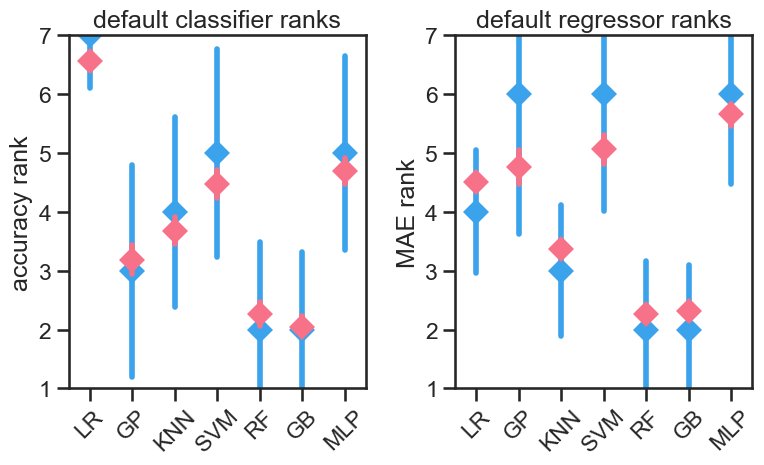

In [16]:
fig,ax=plt.subplots(1,2,figsize=(4*2,5))

df = pd.concat([out_agg_dict[file_name] for file_name in list_class_problems],keys=list_class_problems).reset_index()
metrics=scores_to_analyze_dict[list_class_problems[0]]
sns.pointplot(x='algorithm',y='rank_as_mean_'+metrics[0],data=df[(df['default_config']=='default') & (df['fold']=='test')],errorbar='sd',join=False,markers='D',ax=ax[0],estimator=np.median,color=sns.color_palette("husl")[4])
sns.pointplot(x='algorithm',y='rank_as_mean_'+metrics[0],data=df[(df['default_config']=='default') & (df['fold']=='test')],errorbar='ci',join=False,markers='D',ax=ax[0])

df = pd.concat([out_agg_dict[file_name] for file_name in list_reg_problems],keys=list_reg_problems).reset_index()
metrics=scores_to_analyze_dict[list_reg_problems[0]]
sns.pointplot(x='algorithm',y='rank_as_mean_'+metrics[0],data=df[(df['default_config']=='default') & (df['fold']=='test')],errorbar='sd',join=False,markers='D',ax=ax[1],estimator=np.median,color=sns.color_palette("husl")[4])
sns.pointplot(x='algorithm',y='rank_as_mean_'+metrics[0],data=df[(df['default_config']=='default') & (df['fold']=='test')],errorbar='ci',join=False,markers='D',ax=ax[1])

ax[0].set_ylabel('accuracy rank'); ax[0].set_title('default classifier ranks'); 
ax[1].set_ylabel('MAE rank'); ax[1].set_title('default regressor ranks'); 

for ax in plt.gcf().axes:
  ax.set_ylim(1,7); ax.set_xlabel(''); ax.tick_params(axis='x',labelrotation=45)

fig.tight_layout()

C:\Users\conno\AppData\Local\Temp\ipykernel_2100\215606948.py:5: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(x='algorithm',y='rank_as_mean_'+metrics[0],data=df[(df['default_config']=='default') & (df['fold']=='test')],errorbar='sd',join=False,markers='D',ax=ax[0],hue='level_0')
C:\Users\conno\AppData\Local\Temp\ipykernel_2100\215606948.py:9: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(x='algorithm',y='rank_as_mean_'+metrics[0],data=df[(df['default_config']=='default') & (df['fold']=='test')],errorbar='sd',join=False,markers='D',ax=ax[1],hue='level_0')


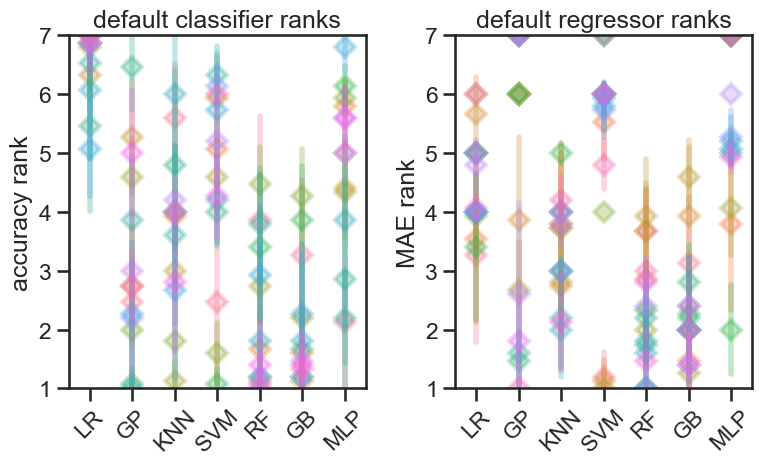

In [17]:
fig,ax=plt.subplots(1,2,figsize=(4*2,5))

df = pd.concat([out_agg_dict[file_name] for file_name in list_class_problems],keys=list_class_problems).reset_index()
metrics=scores_to_analyze_dict[list_class_problems[0]]
sns.pointplot(x='algorithm',y='rank_as_mean_'+metrics[0],data=df[(df['default_config']=='default') & (df['fold']=='test')],errorbar='sd',join=False,markers='D',ax=ax[0],hue='level_0')

df = pd.concat([out_agg_dict[file_name] for file_name in list_reg_problems],keys=list_reg_problems).reset_index()
metrics=scores_to_analyze_dict[list_reg_problems[0]]
sns.pointplot(x='algorithm',y='rank_as_mean_'+metrics[0],data=df[(df['default_config']=='default') & (df['fold']=='test')],errorbar='sd',join=False,markers='D',ax=ax[1],hue='level_0')


ax[0].set_ylabel('accuracy rank'); ax[0].set_title('default classifier ranks'); 
ax[1].set_ylabel('MAE rank'); ax[1].set_title('default regressor ranks');

for ax in plt.gcf().axes:
  ax.set_ylim(1,7); ax.set_xlabel(''); ax.tick_params(axis='x',labelrotation=45); ax.legend().remove() #ax.legend(bbox_to_anchor=[1,1.02,0,0],fontsize='xx-small')
  plt.setp(ax.collections, alpha=.3); plt.setp(ax.lines, alpha=.3); 

fig.tight_layout()

C:\Users\conno\AppData\Local\Temp\ipykernel_2100\2625008612.py:6: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(x='algorithm',y='value',data=data_to_plot,errorbar='ci',join=False,hue='variable',dodge=0.5,markers='D',ax=ax)
C:\Users\conno\AppData\Local\Temp\ipykernel_2100\2625008612.py:19: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(x='algorithm',y='value',data=data_to_plot,errorbar='ci',join=False,hue='variable',dodge=0.5,markers='D',ax=ax)


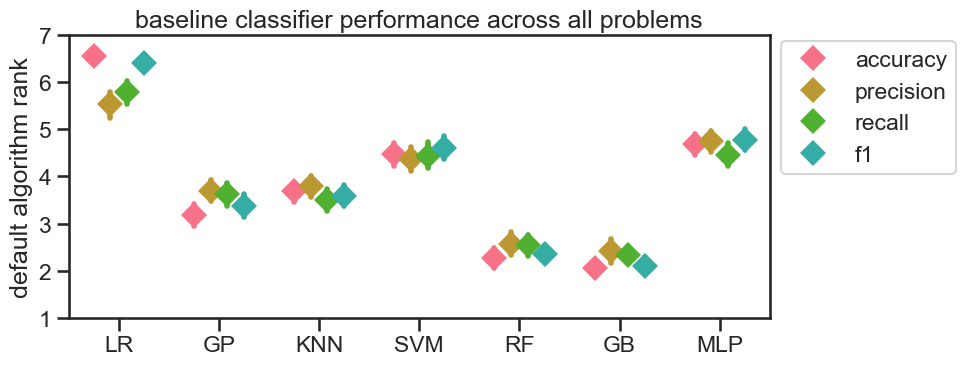

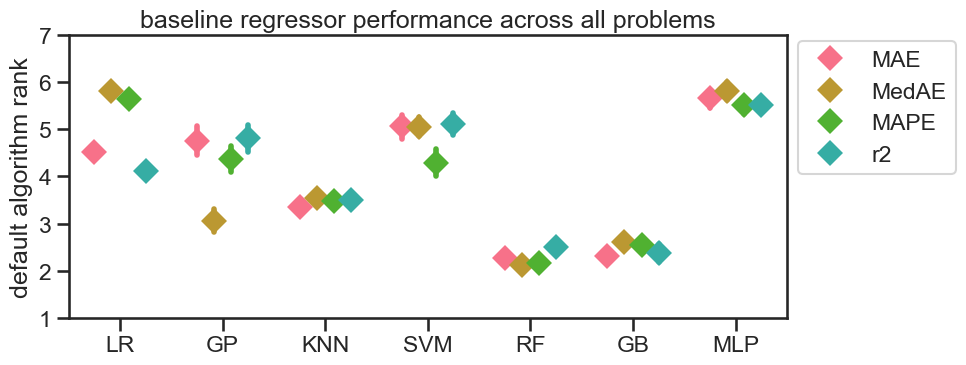

In [18]:
df = pd.concat([out_agg_dict[file_name] for file_name in list_class_problems],keys=list_class_problems).reset_index()
metrics=scores_to_analyze_dict[list_class_problems[0]]
data_to_plot = df[(df['default_config']=='default') & (df['fold']=='test')].melt(id_vars=df.columns[:8],value_vars=['rank_as_mean_'+metric for metric in metrics])

fig,ax=plt.subplots(figsize=(10,4))
sns.pointplot(x='algorithm',y='value',data=data_to_plot,errorbar='ci',join=False,hue='variable',dodge=0.5,markers='D',ax=ax)
label_list = [lab for lab in ax.get_legend_handles_labels()]
ax.legend(handles=label_list[0], labels=metrics, bbox_to_anchor=[1,1.02,0,0],); #ax.legend(bbox_to_anchor=[1,1.02,0,0],).get_texts()[0].set_text('short')
ax.set_ylabel('default algorithm rank'); ax.set_ylim(1,7); ax.set_xlabel(''); ax.set_title('baseline classifier performance across all problems')
fig.tight_layout()


# Compile all of the out_agg datasets for all of problems of the same type
df = pd.concat([out_agg_dict[file_name] for file_name in list_reg_problems],keys=list_reg_problems).reset_index()
metrics=scores_to_analyze_dict[list_reg_problems[0]]
data_to_plot = df[(df['default_config']=='default') & (df['fold']=='test')].melt(id_vars=df.columns[:8],value_vars=['rank_as_mean_'+metric for metric in metrics])

fig,ax=plt.subplots(figsize=(10,4))
sns.pointplot(x='algorithm',y='value',data=data_to_plot,errorbar='ci',join=False,hue='variable',dodge=0.5,markers='D',ax=ax)
label_list = [lab for lab in ax.get_legend_handles_labels()]
ax.legend(handles=label_list[0], labels=metrics, bbox_to_anchor=[1,1.02,0,0],); #ax.legend(bbox_to_anchor=[1,1.02,0,0],).get_texts()[0].set_text('short')
ax.set_ylabel('default algorithm rank'); ax.set_ylim(1,7); ax.set_xlabel(''); ax.set_title('baseline regressor performance across all problems')
fig.tight_layout()

C:\Users\conno\AppData\Local\Temp\ipykernel_2100\733219594.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax[0].vlines(x=row[1][0],ymin=1,ymax=row[1][1],color='grey',linewidth=4,alpha=0.3)
C:\Users\conno\AppData\Local\Temp\ipykernel_2100\733219594.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax[0].vlines(x=row[1][0],ymin=1,ymax=row[1][1],color='grey',linewidth=4,alpha=0.3)
C:\Users\conno\AppData\Local\Temp\ipykernel_2100\733219594.py:11: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(x='alg

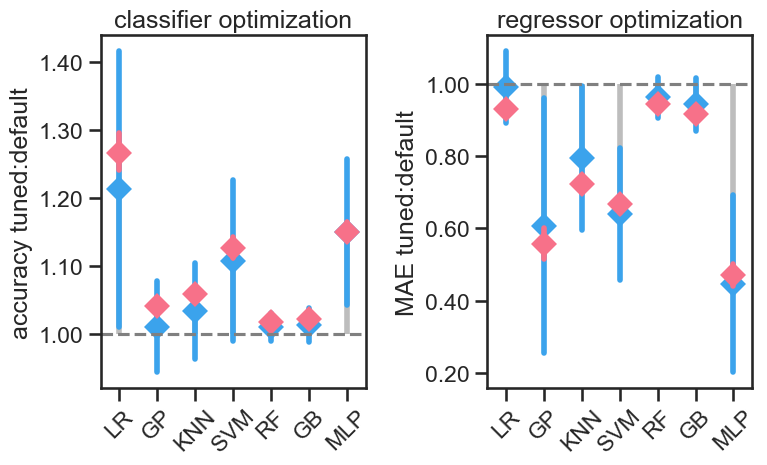

In [19]:
fig,ax=plt.subplots(1,2,figsize=(4*2,5))

df = pd.concat([out_agg_dict[file_name] for file_name in list_class_problems],keys=list_class_problems).reset_index(); df=df[df['fold']=='test']
metrics=scores_to_analyze_dict[list_class_problems[0]]
data_to_plot = (df[df['rank_hpo_mean_'+metrics[0]]==1].groupby(['level_0','iteration','outer_k','algorithm'],sort=False)['mean_'+metrics[0]].mean() 
                / df[df['default_config']=='default'].groupby(['level_0','iteration','outer_k','algorithm'],sort=False)['mean_'+metrics[0]].mean()).reset_index()
for row in data_to_plot.groupby('algorithm',sort=False)['mean_'+metrics[0]].median().reset_index().iterrows():
  ax[0].vlines(x=row[1][0],ymin=1,ymax=row[1][1],color='grey',linewidth=4,alpha=0.3)
for row in data_to_plot.groupby('algorithm',sort=False)['mean_'+metrics[0]].mean().reset_index().iterrows():
  ax[0].vlines(x=row[1][0],ymin=1,ymax=row[1][1],color='grey',linewidth=4,alpha=0.3)
sns.pointplot(x='algorithm',y='mean_'+metrics[0],data=data_to_plot,errorbar='sd',join=False,markers='D',ax=ax[0],estimator=np.median,color=sns.color_palette("husl")[4])
sns.pointplot(x='algorithm',y='mean_'+metrics[0],data=data_to_plot,errorbar='ci',join=False,markers='D',ax=ax[0])

df = pd.concat([out_agg_dict[file_name] for file_name in list_reg_problems],keys=list_reg_problems).reset_index(); df=df[df['fold']=='test']
metrics=scores_to_analyze_dict[list_reg_problems[0]]
data_to_plot = (df[df['rank_hpo_mean_'+metrics[0]]==1].groupby(['level_0','iteration','outer_k','algorithm'],sort=False)['mean_'+metrics[0]].mean().reset_index()
                .merge(df[df['default_config']=='default'].groupby(['level_0','iteration','outer_k','algorithm'],sort=False)['mean_'+metrics[0]].mean().reset_index(),on=['level_0','iteration','outer_k','algorithm']))
data_to_plot['mean_'+metrics[0]] = data_to_plot['mean_'+metrics[0]+'_x']/data_to_plot['mean_'+metrics[0]+'_y']
for row in data_to_plot.groupby('algorithm',sort=False)['mean_'+metrics[0]].median().reset_index().iterrows():
  ax[1].vlines(x=row[1][0],ymin=row[1][1],ymax=1,color='grey',linewidth=4,alpha=0.3)
for row in data_to_plot.groupby('algorithm',sort=False)['mean_'+metrics[0]].mean().reset_index().iterrows():
  ax[1].vlines(x=row[1][0],ymin=row[1][1],ymax=1,color='grey',linewidth=4,alpha=0.3)
sns.pointplot(x='algorithm',y='mean_'+metrics[0],data=data_to_plot,errorbar='sd',join=False,markers='D',ax=ax[1],estimator=np.median,color=sns.color_palette("husl")[4])
sns.pointplot(x='algorithm',y='mean_'+metrics[0],data=data_to_plot,errorbar='ci',join=False,markers='D',ax=ax[1])


ax[0].set_ylabel('accuracy tuned:default'); ax[0].set_title('classifier optimization'); 
ax[1].set_ylabel('MAE tuned:default'); ax[1].set_title('regressor optimization'); 

import matplotlib.ticker as ticker

for ax in plt.gcf().axes:
  #ax.set_ylim(1,7); 
  ax.set_xlabel(''); ax.tick_params(axis='x',labelrotation=45); ax.axhline(1,color='grey',linestyle='--'); ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))

fig.tight_layout()

C:\Users\conno\AppData\Local\Temp\ipykernel_2100\4095902619.py:7: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(x='algorithm',y='mean_'+metrics[0],data=data_to_plot,errorbar='ci',join=False,markers='D',ax=ax[0],hue='level_0')
C:\Users\conno\AppData\Local\Temp\ipykernel_2100\4095902619.py:14: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(x='algorithm',y='mean_'+metrics[0],data=data_to_plot,errorbar='ci',join=False,markers='D',ax=ax[1],hue='level_0')


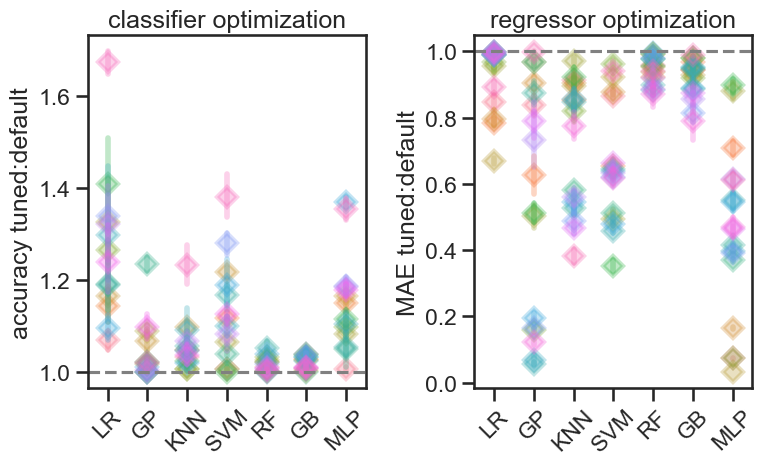

In [20]:
fig,ax=plt.subplots(1,2,figsize=(4*2,5))

df = pd.concat([out_agg_dict[file_name] for file_name in list_class_problems],keys=list_class_problems).reset_index(); df=df[df['fold']=='test']
metrics=scores_to_analyze_dict[list_class_problems[0]]
data_to_plot = (df[df['rank_hpo_mean_'+metrics[0]]==1].groupby(['level_0','iteration','outer_k','algorithm'],sort=False)['mean_'+metrics[0]].mean() 
                / df[df['default_config']=='default'].groupby(['level_0','iteration','outer_k','algorithm'],sort=False)['mean_'+metrics[0]].mean()).reset_index()
sns.pointplot(x='algorithm',y='mean_'+metrics[0],data=data_to_plot,errorbar='ci',join=False,markers='D',ax=ax[0],hue='level_0')

df = pd.concat([out_agg_dict[file_name] for file_name in list_reg_problems],keys=list_reg_problems).reset_index(); df=df[df['fold']=='test']
metrics=scores_to_analyze_dict[list_reg_problems[0]]
data_to_plot = (df[df['rank_hpo_mean_'+metrics[0]]==1].groupby(['level_0','iteration','outer_k','algorithm'],sort=False)['mean_'+metrics[0]].mean().reset_index()
                .merge(df[df['default_config']=='default'].groupby(['level_0','iteration','outer_k','algorithm'],sort=False)['mean_'+metrics[0]].mean().reset_index(),on=['level_0','iteration','outer_k','algorithm']))
data_to_plot['mean_'+metrics[0]] = data_to_plot['mean_'+metrics[0]+'_x']/data_to_plot['mean_'+metrics[0]+'_y']
sns.pointplot(x='algorithm',y='mean_'+metrics[0],data=data_to_plot,errorbar='ci',join=False,markers='D',ax=ax[1],hue='level_0')


ax[0].set_ylabel('accuracy tuned:default'); ax[0].set_title('classifier optimization'); 
ax[1].set_ylabel('MAE tuned:default'); ax[1].set_title('regressor optimization'); 

for ax in plt.gcf().axes:
  #ax.set_ylim(1,7); 
  ax.set_xlabel(''); ax.tick_params(axis='x',labelrotation=45); ax.legend().remove(); plt.setp(ax.collections, alpha=.3); plt.setp(ax.lines, alpha=.3); ax.axhline(1,color='grey',linestyle='--')
  

fig.tight_layout()

C:\Users\conno\AppData\Local\Temp\ipykernel_2100\487682397.py:7: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(x='algorithm',y='values',data=data_to_plot,errorbar='sd',join=False,markers='D',ax=ax[0],estimator=np.median,color=sns.color_palette("husl")[4])
C:\Users\conno\AppData\Local\Temp\ipykernel_2100\487682397.py:8: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(x='algorithm',y='values',data=data_to_plot,errorbar='sd',join=False,markers='D',ax=ax[0])
C:\Users\conno\AppData\Local\Temp\ipykernel_2100\487682397.py:14: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(x='algorithm',y='values',data=data_to_plot,errorbar='sd',join=False,markers='D',

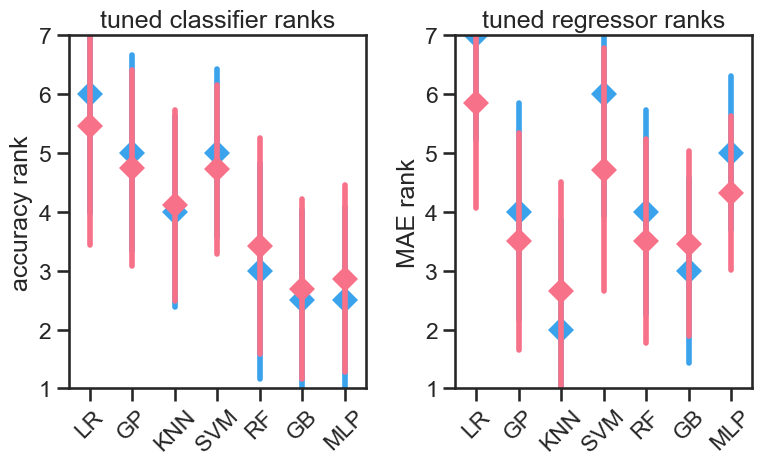

In [21]:
fig,ax=plt.subplots(1,2,figsize=(4*2,5))

df = pd.concat([out_agg_dict[file_name] for file_name in list_class_problems],keys=list_class_problems).reset_index()
metrics=scores_to_analyze_dict[list_class_problems[0]]
data_to_plot = df[(df['rank_hpo_mean_'+metrics[0]]==1) & (df['fold']=='test')].groupby(['level_0','iteration','outer_k','algorithm'],sort=False)['mean_'+metrics[0]].mean().reset_index()
data_to_plot['values'] = data_to_plot.groupby(['level_0','iteration','outer_k'],sort=False)['mean_'+metrics[0]].rank(ascending=False)
sns.pointplot(x='algorithm',y='values',data=data_to_plot,errorbar='sd',join=False,markers='D',ax=ax[0],estimator=np.median,color=sns.color_palette("husl")[4])
sns.pointplot(x='algorithm',y='values',data=data_to_plot,errorbar='sd',join=False,markers='D',ax=ax[0])

df = pd.concat([out_agg_dict[file_name] for file_name in list_reg_problems],keys=list_reg_problems).reset_index()
metrics=scores_to_analyze_dict[list_reg_problems[0]]
data_to_plot = df[(df['rank_hpo_mean_'+metrics[0]]==1) & (df['fold']=='test')].groupby(['level_0','iteration','outer_k','algorithm'],sort=False)['mean_'+metrics[0]].mean().reset_index()
data_to_plot['values'] = data_to_plot.groupby(['level_0','iteration','outer_k'],sort=False)['mean_'+metrics[0]].rank(ascending=True)
sns.pointplot(x='algorithm',y='values',data=data_to_plot,errorbar='sd',join=False,markers='D',ax=ax[1],estimator=np.median,color=sns.color_palette("husl")[4])
sns.pointplot(x='algorithm',y='values',data=data_to_plot,errorbar='sd',join=False,markers='D',ax=ax[1])

ax[0].set_ylabel('accuracy rank'); ax[0].set_title('tuned classifier ranks'); 
ax[1].set_ylabel('MAE rank'); ax[1].set_title('tuned regressor ranks'); 

for ax in plt.gcf().axes:
  ax.set_ylim(1,7); 
  ax.set_xlabel(''); ax.tick_params(axis='x',labelrotation=45)

fig.tight_layout()

C:\Users\conno\AppData\Local\Temp\ipykernel_2100\3312568484.py:9: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(x='algorithm',y='values',data=data_to_plot,errorbar='sd',join=False,markers='D',ax=ax[0],hue='level_0')
C:\Users\conno\AppData\Local\Temp\ipykernel_2100\3312568484.py:15: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(x='algorithm',y='values',data=data_to_plot,errorbar='sd',join=False,markers='D',ax=ax[1],hue='level_0')


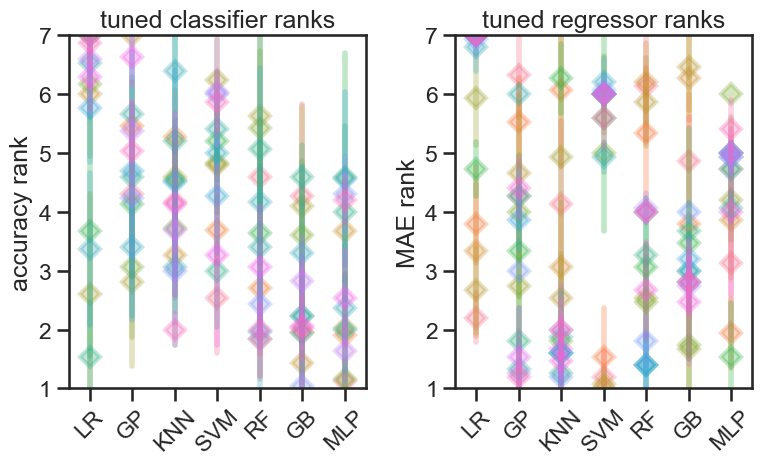

In [22]:
# Compile all of the out_agg datasets for all of problems of the same type

fig,ax=plt.subplots(1,2,figsize=(4*2,5))

df = pd.concat([out_agg_dict[file_name] for file_name in list_class_problems],keys=list_class_problems).reset_index()
metrics=scores_to_analyze_dict[list_class_problems[0]]
data_to_plot = df[(df['rank_hpo_mean_'+metrics[0]]==1) & (df['fold']=='test')].groupby(['level_0','iteration','outer_k','algorithm'],sort=False)['mean_'+metrics[0]].mean().reset_index()
data_to_plot['values'] = data_to_plot.groupby(['level_0','iteration','outer_k'],sort=False)['mean_'+metrics[0]].rank(ascending=False)
sns.pointplot(x='algorithm',y='values',data=data_to_plot,errorbar='sd',join=False,markers='D',ax=ax[0],hue='level_0')

df = pd.concat([out_agg_dict[file_name] for file_name in list_reg_problems],keys=list_reg_problems).reset_index()
metrics=scores_to_analyze_dict[list_reg_problems[0]]
data_to_plot = df[(df['rank_hpo_mean_'+metrics[0]]==1) & (df['fold']=='test')].groupby(['level_0','iteration','outer_k','algorithm'],sort=False)['mean_'+metrics[0]].mean().reset_index()
data_to_plot['values'] = data_to_plot.groupby(['level_0','iteration','outer_k'],sort=False)['mean_'+metrics[0]].rank(ascending=True)
sns.pointplot(x='algorithm',y='values',data=data_to_plot,errorbar='sd',join=False,markers='D',ax=ax[1],hue='level_0')

ax[0].set_ylabel('accuracy rank'); ax[0].set_title('tuned classifier ranks'); 
ax[1].set_ylabel('MAE rank'); ax[1].set_title('tuned regressor ranks'); 

for ax in plt.gcf().axes:
  ax.set_ylim(1,7);   ax.set_xlabel(''); ax.tick_params(axis='x',labelrotation=45); ax.get_legend().remove(); plt.setp(ax.collections, alpha=.3); plt.setp(ax.lines, alpha=.3); 

fig.tight_layout()

C:\Users\conno\AppData\Local\Temp\ipykernel_2100\3460956721.py:6: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0.

  sns.pointplot(x='outer_k',y='normed_to_2fold_mean_'+metrics[0],data=df,errorbar='sd',join=True,markers='D',ax=ax[0],estimator=np.median,color=sns.color_palette("husl")[4])
C:\Users\conno\AppData\Local\Temp\ipykernel_2100\3460956721.py:7: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0.

  sns.pointplot(x='outer_k',y='normed_to_2fold_mean_'+metrics[0],data=df,errorbar='sd',join=True,markers='D',ax=ax[0])
C:\Users\conno\AppData\Local\Temp\ipykernel_2100\3460956721.py:12: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0.

  sns.pointplot(x='outer_k',y='normed_to_2fold_mean_'+metrics[0],data=df,errorbar='sd',join=True,markers='D',ax=ax[1],estimator=np.median,color=sns.color_palette("husl")[4])
C:\Users\conno\AppData\Local\Temp\ipykernel_2100\3460956721.py:13: UserWarning: 

The

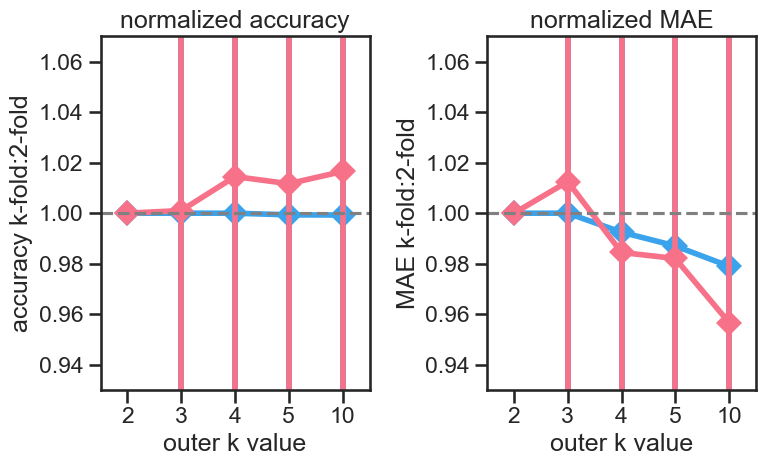

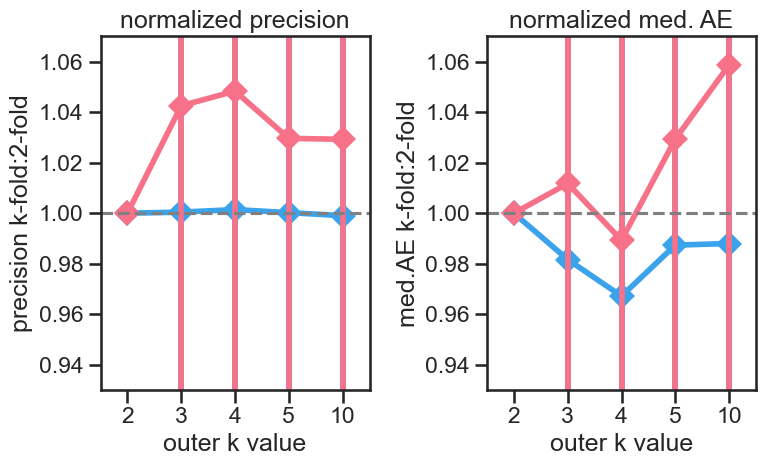

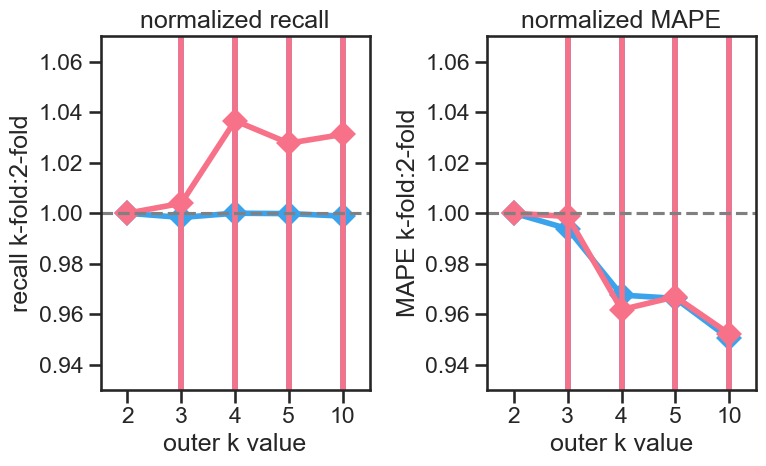

In [23]:
fig,ax=plt.subplots(1,2,figsize=(4*2,5))

df = pd.concat([out_agg_dict[file_name] for file_name in list_class_problems],keys=list_class_problems).reset_index(); df=df[(df['fold']=='test')]
metrics=scores_to_analyze_dict[list_class_problems[0]]
df['normed_to_2fold_mean_'+metrics[0]] = df['mean_'+metrics[0]] / df.groupby(['level_0','iteration','algorithm','model_config_id'],sort=False)['mean_'+metrics[0]].transform('first')
sns.pointplot(x='outer_k',y='normed_to_2fold_mean_'+metrics[0],data=df,errorbar='sd',join=True,markers='D',ax=ax[0],estimator=np.median,color=sns.color_palette("husl")[4])
sns.pointplot(x='outer_k',y='normed_to_2fold_mean_'+metrics[0],data=df,errorbar='sd',join=True,markers='D',ax=ax[0])

df = pd.concat([out_agg_dict[file_name] for file_name in list_reg_problems],keys=list_reg_problems).reset_index(); df=df[(df['fold']=='test')]
metrics=scores_to_analyze_dict[list_reg_problems[0]]
df['normed_to_2fold_mean_'+metrics[0]] = df['mean_'+metrics[0]] / df.groupby(['level_0','iteration','algorithm','model_config_id'],sort=False)['mean_'+metrics[0]].transform('first')
sns.pointplot(x='outer_k',y='normed_to_2fold_mean_'+metrics[0],data=df,errorbar='sd',join=True,markers='D',ax=ax[1],estimator=np.median,color=sns.color_palette("husl")[4])
sns.pointplot(x='outer_k',y='normed_to_2fold_mean_'+metrics[0],data=df,errorbar='sd',join=True,markers='D',ax=ax[1])

ax[0].set_ylabel('accuracy k-fold:2-fold'); ax[0].set_title('normalized accuracy'); 
ax[1].set_ylabel('MAE k-fold:2-fold'); ax[1].set_title('normalized MAE'); 

for ax in plt.gcf().axes:
  ax.set_ylim(0.93,1.07); ax.set_xlabel('outer k value'); ax.axhline(1,color='grey',linestyle='--'); ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f')); 

fig.tight_layout()

fig,ax=plt.subplots(1,2,figsize=(4*2,5))

df = pd.concat([out_agg_dict[file_name] for file_name in list_class_problems],keys=list_class_problems).reset_index(); df=df[(df['fold']=='test')]
metrics=scores_to_analyze_dict[list_class_problems[0]]
df['normed_to_2fold_mean_'+metrics[1]] = df['mean_'+metrics[1]] / df.groupby(['level_0','iteration','algorithm','model_config_id'],sort=False)['mean_'+metrics[1]].transform('first'); df.replace([np.inf, -np.inf], np.nan, inplace=True)
sns.pointplot(x='outer_k',y='normed_to_2fold_mean_'+metrics[1],data=df[df['normed_to_2fold_mean_precision'].notna()],errorbar='sd',join=True,markers='D',ax=ax[0],estimator=np.median,color=sns.color_palette("husl")[4])
sns.pointplot(x='outer_k',y='normed_to_2fold_mean_'+metrics[1],data=df[df['normed_to_2fold_mean_precision'].notna()],errorbar='sd',join=True,markers='D',ax=ax[0])

df = pd.concat([out_agg_dict[file_name] for file_name in list_reg_problems],keys=list_reg_problems).reset_index(); df=df[(df['fold']=='test')]
metrics=scores_to_analyze_dict[list_reg_problems[0]]
df['normed_to_2fold_mean_'+metrics[1]] = df['mean_'+metrics[1]] / df.groupby(['level_0','iteration','algorithm','model_config_id'],sort=False)['mean_'+metrics[1]].transform('first')
sns.pointplot(x='outer_k',y='normed_to_2fold_mean_'+metrics[1],data=df,errorbar='sd',join=True,markers='D',ax=ax[1],estimator=np.median,color=sns.color_palette("husl")[4])
sns.pointplot(x='outer_k',y='normed_to_2fold_mean_'+metrics[1],data=df,errorbar='sd',join=True,markers='D',ax=ax[1])

ax[0].set_ylabel('precision k-fold:2-fold'); ax[0].set_title('normalized precision'); 
ax[1].set_ylabel('med.AE k-fold:2-fold'); ax[1].set_title('normalized med. AE'); 

for ax in plt.gcf().axes:
  ax.set_ylim(0.93,1.07); ax.set_xlabel('outer k value'); ax.axhline(1,color='grey',linestyle='--'); ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))

fig.tight_layout()

fig,ax=plt.subplots(1,2,figsize=(4*2,5))

df = pd.concat([out_agg_dict[file_name] for file_name in list_class_problems],keys=list_class_problems).reset_index(); df=df[(df['fold']=='test')]
metrics=scores_to_analyze_dict[list_class_problems[0]]
df['normed_to_2fold_mean_'+metrics[2]] = df['mean_'+metrics[2]] / df.groupby(['level_0','iteration','algorithm','model_config_id'],sort=False)['mean_'+metrics[2]].transform('first'); df.replace([np.inf, -np.inf], np.nan, inplace=True)
sns.pointplot(x='outer_k',y='normed_to_2fold_mean_'+metrics[2],data=df[df['normed_to_2fold_mean_'+metrics[2]].notna()],errorbar='sd',join=True,markers='D',ax=ax[0],estimator=np.median,color=sns.color_palette("husl")[4])
sns.pointplot(x='outer_k',y='normed_to_2fold_mean_'+metrics[2],data=df[df['normed_to_2fold_mean_'+metrics[2]].notna()],errorbar='sd',join=True,markers='D',ax=ax[0])

df = pd.concat([out_agg_dict[file_name] for file_name in list_reg_problems],keys=list_reg_problems).reset_index(); df=df[(df['fold']=='test')]
metrics=scores_to_analyze_dict[list_reg_problems[0]]
df['normed_to_2fold_mean_'+metrics[2]] = df['mean_'+metrics[2]] / df.groupby(['level_0','iteration','algorithm','model_config_id'],sort=False)['mean_'+metrics[2]].transform('first')
sns.pointplot(x='outer_k',y='normed_to_2fold_mean_'+metrics[2],data=df,errorbar='sd',join=True,markers='D',ax=ax[1],estimator=np.median,color=sns.color_palette("husl")[4])
sns.pointplot(x='outer_k',y='normed_to_2fold_mean_'+metrics[2],data=df,errorbar='sd',join=True,markers='D',ax=ax[1])

ax[0].set_ylabel('recall k-fold:2-fold'); ax[0].set_title('normalized recall'); 
ax[1].set_ylabel('MAPE k-fold:2-fold'); ax[1].set_title('normalized MAPE'); 

for ax in plt.gcf().axes:
  ax.set_ylim(0.93,1.07); ax.set_xlabel('outer k value'); ax.axhline(1,color='grey',linestyle='--'); ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))

fig.tight_layout()

C:\Users\conno\AppData\Local\Temp\ipykernel_2100\1727871108.py:6: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0.

  sns.pointplot(x='outer_k',y='normed_to_2fold_mean_'+metrics[0],data=df,errorbar='sd',join=True,markers='D',ax=ax[0],hue='level_0')
C:\Users\conno\AppData\Local\Temp\ipykernel_2100\1727871108.py:11: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0.

  sns.pointplot(x='outer_k',y='normed_to_2fold_mean_'+metrics[0],data=df,errorbar='sd',join=True,markers='D',ax=ax[1],hue='level_0')
C:\Users\conno\AppData\Local\Temp\ipykernel_2100\1727871108.py:27: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0.

  sns.pointplot(x='outer_k',y='normed_to_2fold_mean_'+metrics[1],data=df[df['normed_to_2fold_mean_precision'].notna()],errorbar='sd',join=True,markers='D',ax=ax[0],hue='level_0')
C:\Users\conno\AppData\Local\Temp\ipykernel_2100\1727871108.py:32: UserWarning: 

The `join` parameter is 

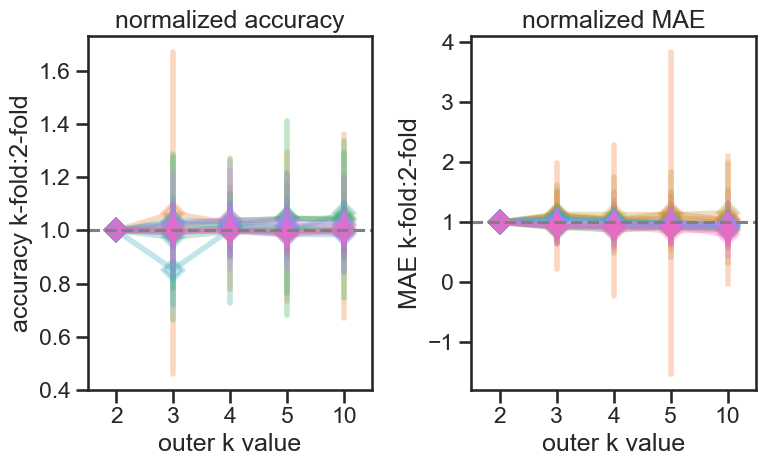

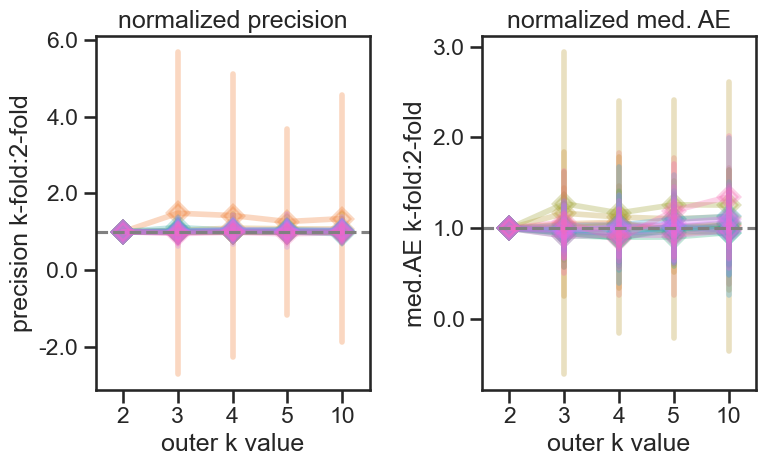

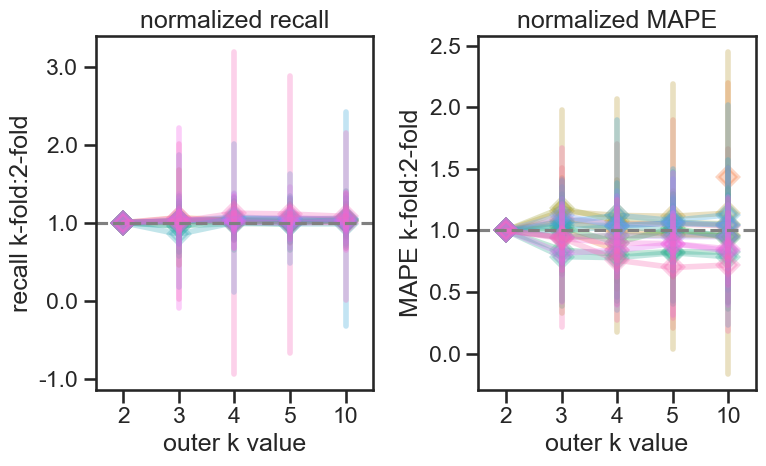

In [24]:
fig,ax=plt.subplots(1,2,figsize=(4*2,5))

df = pd.concat([out_agg_dict[file_name] for file_name in list_class_problems],keys=list_class_problems).reset_index(); df=df[(df['fold']=='test')]
metrics=scores_to_analyze_dict[list_class_problems[0]]
df['normed_to_2fold_mean_'+metrics[0]] = df['mean_'+metrics[0]] / df.groupby(['level_0','iteration','algorithm','model_config_id'],sort=False)['mean_'+metrics[0]].transform('first')
sns.pointplot(x='outer_k',y='normed_to_2fold_mean_'+metrics[0],data=df,errorbar='sd',join=True,markers='D',ax=ax[0],hue='level_0')

df = pd.concat([out_agg_dict[file_name] for file_name in list_reg_problems],keys=list_reg_problems).reset_index(); df=df[(df['fold']=='test')]
metrics=scores_to_analyze_dict[list_reg_problems[0]]
df['normed_to_2fold_mean_'+metrics[0]] = df['mean_'+metrics[0]] / df.groupby(['level_0','iteration','algorithm','model_config_id'],sort=False)['mean_'+metrics[0]].transform('first')
sns.pointplot(x='outer_k',y='normed_to_2fold_mean_'+metrics[0],data=df,errorbar='sd',join=True,markers='D',ax=ax[1],hue='level_0')

ax[0].set_ylabel('accuracy k-fold:2-fold'); ax[0].set_title('normalized accuracy'); #ax[0].set_ylim(0.9,1.1)
ax[1].set_ylabel('MAE k-fold:2-fold'); ax[1].set_title('normalized MAE'); #ax[1].set_ylim(0.8,1.2); 

for ax in plt.gcf().axes:
  #ax.set_ylim(0.75,1.25)
  ax.set_xlabel('outer k value'); plt.setp(ax.collections, alpha=.3); plt.setp(ax.lines, alpha=.3); ax.axhline(1,color='grey',linestyle='--'); ax.get_legend().remove(); #ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))

fig.tight_layout()

fig,ax=plt.subplots(1,2,figsize=(4*2,5))

df = pd.concat([out_agg_dict[file_name] for file_name in list_class_problems],keys=list_class_problems).reset_index(); df=df[(df['fold']=='test')]
metrics=scores_to_analyze_dict[list_class_problems[0]]
df['normed_to_2fold_mean_'+metrics[1]] = df['mean_'+metrics[1]] / df.groupby(['level_0','iteration','algorithm','model_config_id'],sort=False)['mean_'+metrics[1]].transform('first'); df.replace([np.inf, -np.inf], np.nan, inplace=True)
sns.pointplot(x='outer_k',y='normed_to_2fold_mean_'+metrics[1],data=df[df['normed_to_2fold_mean_precision'].notna()],errorbar='sd',join=True,markers='D',ax=ax[0],hue='level_0')

df = pd.concat([out_agg_dict[file_name] for file_name in list_reg_problems],keys=list_reg_problems).reset_index(); df=df[(df['fold']=='test')]
metrics=scores_to_analyze_dict[list_reg_problems[0]]
df['normed_to_2fold_mean_'+metrics[1]] = df['mean_'+metrics[1]] / df.groupby(['level_0','iteration','algorithm','model_config_id'],sort=False)['mean_'+metrics[1]].transform('first')
sns.pointplot(x='outer_k',y='normed_to_2fold_mean_'+metrics[1],data=df,errorbar='sd',join=True,markers='D',ax=ax[1],hue='level_0')

ax[0].set_ylabel('precision k-fold:2-fold'); ax[0].set_title('normalized precision'); 
ax[1].set_ylabel('med.AE k-fold:2-fold'); ax[1].set_title('normalized med. AE'); 

for ax in plt.gcf().axes:
  #ax.set_ylim(0.75,1.25); 
  ax.set_xlabel('outer k value'); plt.setp(ax.collections, alpha=.3); plt.setp(ax.lines, alpha=.3); ax.axhline(1,color='grey',linestyle='--'); ax.get_legend().remove(); ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))

fig.tight_layout()

fig,ax=plt.subplots(1,2,figsize=(4*2,5))

df = pd.concat([out_agg_dict[file_name] for file_name in list_class_problems],keys=list_class_problems).reset_index(); df=df[(df['fold']=='test')]
metrics=scores_to_analyze_dict[list_class_problems[0]]
df['normed_to_2fold_mean_'+metrics[2]] = df['mean_'+metrics[2]] / df.groupby(['level_0','iteration','algorithm','model_config_id'],sort=False)['mean_'+metrics[2]].transform('first'); df.replace([np.inf, -np.inf], np.nan, inplace=True)
sns.pointplot(x='outer_k',y='normed_to_2fold_mean_'+metrics[2],data=df[df['normed_to_2fold_mean_'+metrics[2]].notna()],errorbar='sd',join=True,markers='D',ax=ax[0],hue='level_0')

df = pd.concat([out_agg_dict[file_name] for file_name in list_reg_problems],keys=list_reg_problems).reset_index(); df=df[(df['fold']=='test')]
metrics=scores_to_analyze_dict[list_reg_problems[0]]
df['normed_to_2fold_mean_'+metrics[2]] = df['mean_'+metrics[2]] / df.groupby(['level_0','iteration','algorithm','model_config_id'],sort=False)['mean_'+metrics[2]].transform('first')
sns.pointplot(x='outer_k',y='normed_to_2fold_mean_'+metrics[2],data=df,errorbar='sd',join=True,markers='D',ax=ax[1],hue='level_0')

ax[0].set_ylabel('recall k-fold:2-fold'); ax[0].set_title('normalized recall'); 
ax[1].set_ylabel('MAPE k-fold:2-fold'); ax[1].set_title('normalized MAPE'); 

for ax in plt.gcf().axes:
  #ax.set_ylim(0.75,1.25); 
  ax.set_xlabel('outer k value'); plt.setp(ax.collections, alpha=.3); plt.setp(ax.lines, alpha=.3); ax.axhline(1,color='grey',linestyle='--'); ax.get_legend().remove(); ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))

fig.tight_layout()

C:\Users\conno\AppData\Local\Temp\ipykernel_2100\462112228.py:6: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0.

  sns.pointplot(x='outer_k',y='normed_to_2fold_mean_'+metrics[0],data=df,join=True,markers='D',ax=ax[0],hue='algorithm')
C:\Users\conno\AppData\Local\Temp\ipykernel_2100\462112228.py:11: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0.

  sns.pointplot(x='outer_k',y='normed_to_2fold_mean_'+metrics[0],data=df,join=True,markers='D',ax=ax[1],hue='algorithm')
C:\Users\conno\AppData\Local\Temp\ipykernel_2100\462112228.py:27: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0.

  sns.pointplot(x='outer_k',y='normed_to_2fold_mean_'+metrics[1],data=df[df['normed_to_2fold_mean_precision'].notna()],errorbar='sd',join=True,markers='D',ax=ax[0],hue='algorithm')
C:\Users\conno\AppData\Local\Temp\ipykernel_2100\462112228.py:32: UserWarning: 

The `join` parameter is deprecated and will be rem

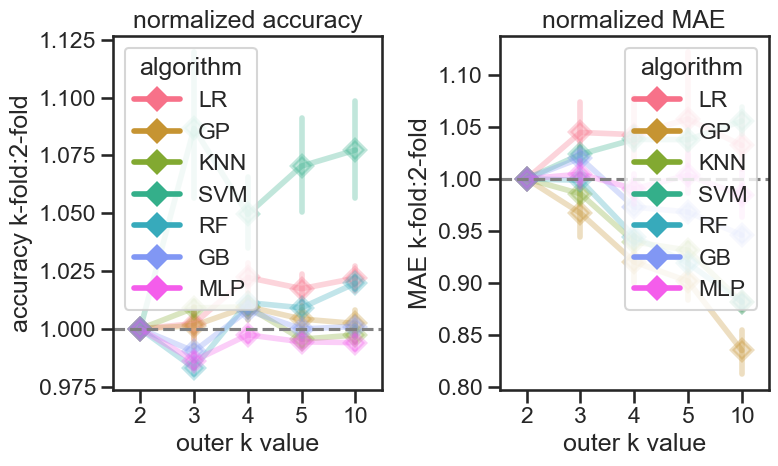

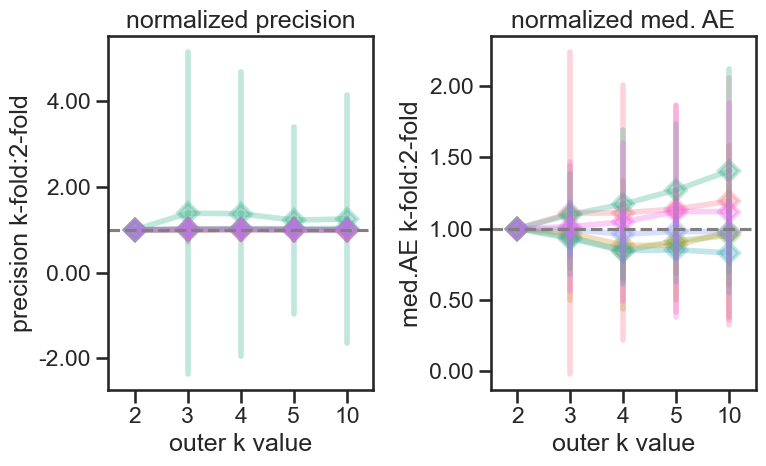

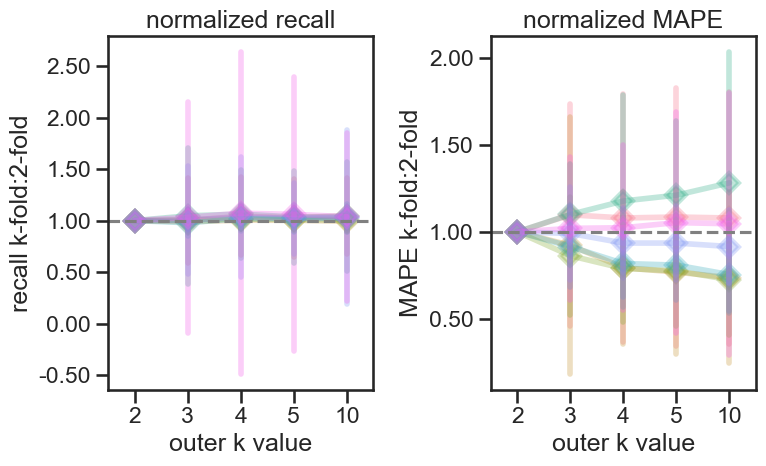

In [25]:
fig,ax=plt.subplots(1,2,figsize=(4*2,5))

df = pd.concat([out_agg_dict[file_name] for file_name in list_class_problems],keys=list_class_problems).reset_index(); df=df[(df['fold']=='test')]
metrics=scores_to_analyze_dict[list_class_problems[0]]
df['normed_to_2fold_mean_'+metrics[0]] = df['mean_'+metrics[0]] / df.groupby(['level_0','iteration','algorithm','model_config_id'],sort=False)['mean_'+metrics[0]].transform('first')
sns.pointplot(x='outer_k',y='normed_to_2fold_mean_'+metrics[0],data=df,join=True,markers='D',ax=ax[0],hue='algorithm')

df = pd.concat([out_agg_dict[file_name] for file_name in list_reg_problems],keys=list_reg_problems).reset_index(); df=df[(df['fold']=='test')]
metrics=scores_to_analyze_dict[list_reg_problems[0]]
df['normed_to_2fold_mean_'+metrics[0]] = df['mean_'+metrics[0]] / df.groupby(['level_0','iteration','algorithm','model_config_id'],sort=False)['mean_'+metrics[0]].transform('first')
sns.pointplot(x='outer_k',y='normed_to_2fold_mean_'+metrics[0],data=df,join=True,markers='D',ax=ax[1],hue='algorithm')

ax[0].set_ylabel('accuracy k-fold:2-fold'); ax[0].set_title('normalized accuracy'); #ax[0].set_ylim(0.9,1.1)
ax[1].set_ylabel('MAE k-fold:2-fold'); ax[1].set_title('normalized MAE'); #ax[1].set_ylim(0.8,1.2); 

for ax in plt.gcf().axes:
  #ax.set_ylim(0.75,1.25)
  ax.set_xlabel('outer k value'); plt.setp(ax.collections, alpha=.3); plt.setp(ax.lines, alpha=.3); ax.axhline(1,color='grey',linestyle='--'); #ax.get_legend().remove(); ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))

fig.tight_layout()

fig,ax=plt.subplots(1,2,figsize=(4*2,5))

df = pd.concat([out_agg_dict[file_name] for file_name in list_class_problems],keys=list_class_problems).reset_index(); df=df[(df['fold']=='test')]
metrics=scores_to_analyze_dict[list_class_problems[0]]
df['normed_to_2fold_mean_'+metrics[1]] = df['mean_'+metrics[1]] / df.groupby(['level_0','iteration','algorithm','model_config_id'],sort=False)['mean_'+metrics[1]].transform('first'); df.replace([np.inf, -np.inf], np.nan, inplace=True)
sns.pointplot(x='outer_k',y='normed_to_2fold_mean_'+metrics[1],data=df[df['normed_to_2fold_mean_precision'].notna()],errorbar='sd',join=True,markers='D',ax=ax[0],hue='algorithm')

df = pd.concat([out_agg_dict[file_name] for file_name in list_reg_problems],keys=list_reg_problems).reset_index(); df=df[(df['fold']=='test')]
metrics=scores_to_analyze_dict[list_reg_problems[0]]
df['normed_to_2fold_mean_'+metrics[1]] = df['mean_'+metrics[1]] / df.groupby(['level_0','iteration','algorithm','model_config_id'],sort=False)['mean_'+metrics[1]].transform('first')
sns.pointplot(x='outer_k',y='normed_to_2fold_mean_'+metrics[1],data=df,errorbar='sd',join=True,markers='D',ax=ax[1],hue='algorithm')

ax[0].set_ylabel('precision k-fold:2-fold'); ax[0].set_title('normalized precision'); 
ax[1].set_ylabel('med.AE k-fold:2-fold'); ax[1].set_title('normalized med. AE'); 

for ax in plt.gcf().axes:
  #ax.set_ylim(0.75,1.25); 
  ax.set_xlabel('outer k value'); plt.setp(ax.collections, alpha=.3); plt.setp(ax.lines, alpha=.3); ax.axhline(1,color='grey',linestyle='--'); ax.get_legend().remove(); ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))

fig.tight_layout()

fig,ax=plt.subplots(1,2,figsize=(4*2,5))

df = pd.concat([out_agg_dict[file_name] for file_name in list_class_problems],keys=list_class_problems).reset_index(); df=df[(df['fold']=='test')]
metrics=scores_to_analyze_dict[list_class_problems[0]]
df['normed_to_2fold_mean_'+metrics[2]] = df['mean_'+metrics[2]] / df.groupby(['level_0','iteration','algorithm','model_config_id'],sort=False)['mean_'+metrics[2]].transform('first'); df.replace([np.inf, -np.inf], np.nan, inplace=True)
sns.pointplot(x='outer_k',y='normed_to_2fold_mean_'+metrics[2],data=df[df['normed_to_2fold_mean_'+metrics[2]].notna()],errorbar='sd',join=True,markers='D',ax=ax[0],hue='algorithm')

df = pd.concat([out_agg_dict[file_name] for file_name in list_reg_problems],keys=list_reg_problems).reset_index(); df=df[(df['fold']=='test')]
metrics=scores_to_analyze_dict[list_reg_problems[0]]
df['normed_to_2fold_mean_'+metrics[2]] = df['mean_'+metrics[2]] / df.groupby(['level_0','iteration','algorithm','model_config_id'],sort=False)['mean_'+metrics[2]].transform('first')
sns.pointplot(x='outer_k',y='normed_to_2fold_mean_'+metrics[2],data=df,errorbar='sd',join=True,markers='D',ax=ax[1],hue='algorithm')

ax[0].set_ylabel('recall k-fold:2-fold'); ax[0].set_title('normalized recall'); 
ax[1].set_ylabel('MAPE k-fold:2-fold'); ax[1].set_title('normalized MAPE'); 

for ax in plt.gcf().axes:
  #ax.set_ylim(0.75,1.25); 
  ax.set_xlabel('outer k value'); plt.setp(ax.collections, alpha=.3); plt.setp(ax.lines, alpha=.3); ax.axhline(1,color='grey',linestyle='--'); ax.get_legend().remove(); ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))

fig.tight_layout()

C:\Users\conno\AppData\Local\Temp\ipykernel_2100\3954158951.py:8: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(x='iteration',y='normed_to_iter1_mean_'+metrics[0],data=df,errorbar='sd',join=False,markers='D',ax=ax[0],estimator=np.median,color=sns.color_palette("husl")[4])
C:\Users\conno\AppData\Local\Temp\ipykernel_2100\3954158951.py:9: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(x='iteration',y='normed_to_iter1_mean_'+metrics[0],data=df,errorbar='sd',join=False,markers='D',ax=ax[0])
C:\Users\conno\AppData\Local\Temp\ipykernel_2100\3954158951.py:14: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(x='iteration',y='normed_to_iter1_mean_'+metri

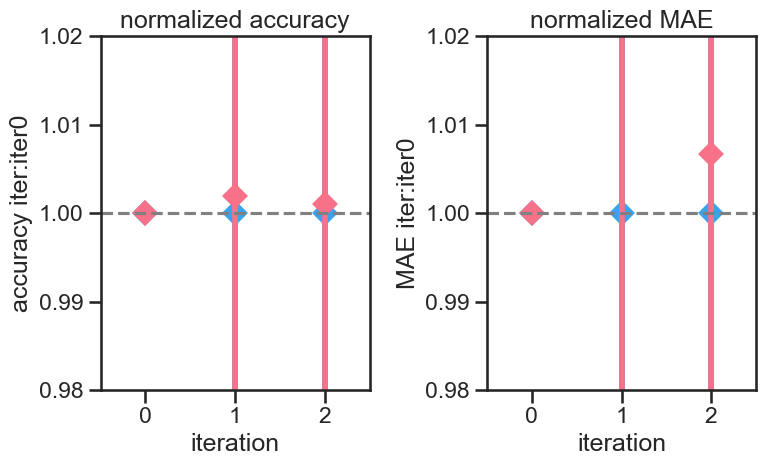

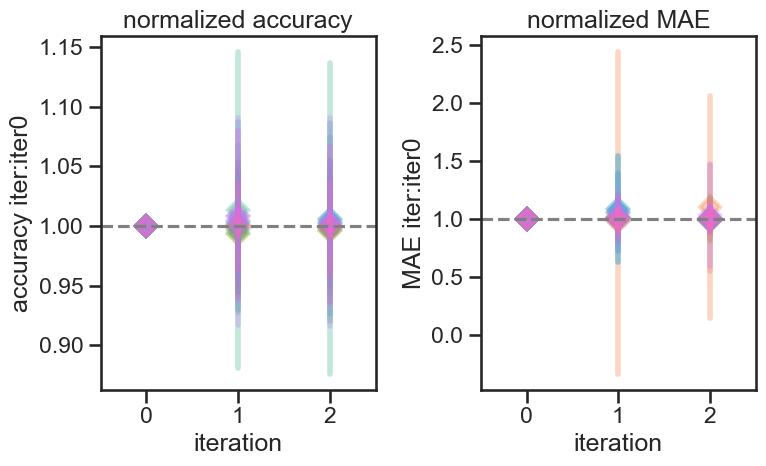

In [26]:
# Compile all of the out_agg datasets for all of problems of the same type

fig,ax=plt.subplots(1,2,figsize=(4*2,5))

df = pd.concat([out_agg_dict[file_name] for file_name in list_class_problems],keys=list_class_problems).reset_index(); df=df[(df['fold']=='test')]
metrics=scores_to_analyze_dict[list_class_problems[0]]
df['normed_to_iter1_mean_'+metrics[0]] = df['mean_'+metrics[0]] / df.groupby(['level_0','outer_k','algorithm','model_config_id'],sort=False)['mean_'+metrics[0]].transform('first')
sns.pointplot(x='iteration',y='normed_to_iter1_mean_'+metrics[0],data=df,errorbar='sd',join=False,markers='D',ax=ax[0],estimator=np.median,color=sns.color_palette("husl")[4])
sns.pointplot(x='iteration',y='normed_to_iter1_mean_'+metrics[0],data=df,errorbar='sd',join=False,markers='D',ax=ax[0])

df = pd.concat([out_agg_dict[file_name] for file_name in list_reg_problems],keys=list_reg_problems).reset_index(); df=df[(df['fold']=='test')]
metrics=scores_to_analyze_dict[list_reg_problems[0]]
df['normed_to_iter1_mean_'+metrics[0]] = df['mean_'+metrics[0]] / df.groupby(['level_0','outer_k','algorithm','model_config_id'],sort=False)['mean_'+metrics[0]].transform('first')
sns.pointplot(x='iteration',y='normed_to_iter1_mean_'+metrics[0],data=df,errorbar='sd',join=False,markers='D',ax=ax[1],estimator=np.median,color=sns.color_palette("husl")[4])
sns.pointplot(x='iteration',y='normed_to_iter1_mean_'+metrics[0],data=df,errorbar='sd',join=False,markers='D',ax=ax[1])

ax[0].set_ylabel('accuracy iter:iter0'); ax[0].set_title('normalized accuracy'); 
ax[1].set_ylabel('MAE iter:iter0'); ax[1].set_title('normalized MAE'); 

for ax in plt.gcf().axes:
  ax.set_ylim(0.98,1.02); ax.set_xlabel('iteration'); ax.axhline(1,color='grey',linestyle='--')

fig.tight_layout()

# Compile all of the out_agg datasets for all of problems of the same type

fig,ax=plt.subplots(1,2,figsize=(4*2,5))

df = pd.concat([out_agg_dict[file_name] for file_name in list_class_problems],keys=list_class_problems).reset_index(); df=df[(df['fold']=='test')]
metrics=scores_to_analyze_dict[list_class_problems[0]]
df['normed_to_iter1_mean_'+metrics[0]] = df['mean_'+metrics[0]] / df.groupby(['level_0','outer_k','algorithm','model_config_id'],sort=False)['mean_'+metrics[0]].transform('first')
sns.pointplot(x='iteration',y='normed_to_iter1_mean_'+metrics[0],data=df,errorbar='sd',join=False,markers='D',ax=ax[0],hue='level_0')

df = pd.concat([out_agg_dict[file_name] for file_name in list_reg_problems],keys=list_reg_problems).reset_index(); df=df[(df['fold']=='test')]
metrics=scores_to_analyze_dict[list_reg_problems[0]]
df['normed_to_iter1_mean_'+metrics[0]] = df['mean_'+metrics[0]] / df.groupby(['level_0','outer_k','algorithm','model_config_id'],sort=False)['mean_'+metrics[0]].transform('first')
sns.pointplot(x='iteration',y='normed_to_iter1_mean_'+metrics[0],data=df,errorbar='sd',join=False,markers='D',ax=ax[1],hue='level_0')

ax[0].set_ylabel('accuracy iter:iter0'); ax[0].set_title('normalized accuracy'); #ax[0].set_ylim(0.98,1.02)
ax[1].set_ylabel('MAE iter:iter0'); ax[1].set_title('normalized MAE'); #ax[1].set_ylim(0.95,1.1); 

for ax in plt.gcf().axes:
  ax.set_xlabel('iteration'); plt.setp(ax.collections, alpha=.3); plt.setp(ax.lines, alpha=.3); ax.axhline(1,color='grey',linestyle='--'); ax.get_legend().remove(); #ax.set_ylim(0.9,1.1) 

fig.tight_layout()

C:\Users\conno\AppData\Local\Temp\ipykernel_2100\45899284.py:8: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(x='iteration',y='normed_to_iter1_mean_'+metrics[0],data=df,join=False,markers='D',ax=ax[0],hue='algorithm')
C:\Users\conno\AppData\Local\Temp\ipykernel_2100\45899284.py:13: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(x='iteration',y='normed_to_iter1_mean_'+metrics[0],data=df,join=False,markers='D',ax=ax[1],hue='algorithm')


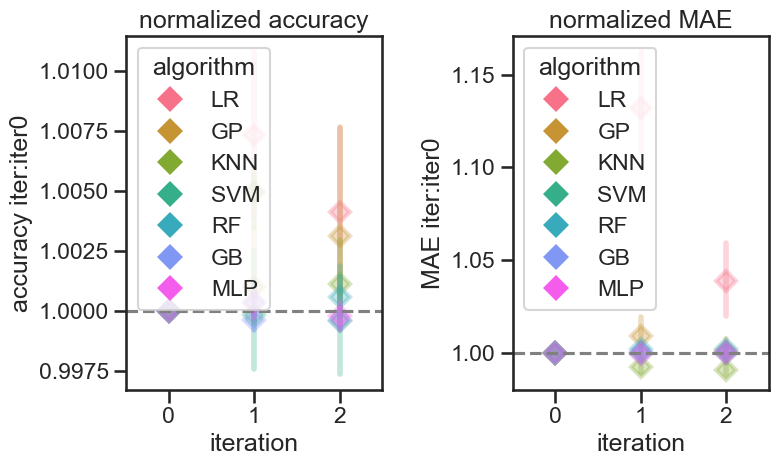

In [27]:
# Compile all of the out_agg datasets for all of problems of the same type

fig,ax=plt.subplots(1,2,figsize=(4*2,5))

df = pd.concat([out_agg_dict[file_name] for file_name in list_class_problems],keys=list_class_problems).reset_index(); df=df[(df['fold']=='test')]
metrics=scores_to_analyze_dict[list_class_problems[0]]
df['normed_to_iter1_mean_'+metrics[0]] = df['mean_'+metrics[0]] / df.groupby(['level_0','outer_k','algorithm','model_config_id'],sort=False)['mean_'+metrics[0]].transform('first')
sns.pointplot(x='iteration',y='normed_to_iter1_mean_'+metrics[0],data=df,join=False,markers='D',ax=ax[0],hue='algorithm')

df = pd.concat([out_agg_dict[file_name] for file_name in list_reg_problems],keys=list_reg_problems).reset_index(); df=df[(df['fold']=='test')]
metrics=scores_to_analyze_dict[list_reg_problems[0]]
df['normed_to_iter1_mean_'+metrics[0]] = df['mean_'+metrics[0]] / df.groupby(['level_0','outer_k','algorithm','model_config_id'],sort=False)['mean_'+metrics[0]].transform('first')
sns.pointplot(x='iteration',y='normed_to_iter1_mean_'+metrics[0],data=df,join=False,markers='D',ax=ax[1],hue='algorithm')

ax[0].set_ylabel('accuracy iter:iter0'); ax[0].set_title('normalized accuracy'); #ax[0].set_ylim(0.98,1.02)
ax[1].set_ylabel('MAE iter:iter0'); ax[1].set_title('normalized MAE'); #ax[1].set_ylim(0.95,1.1); 

for ax in plt.gcf().axes:
  ax.set_xlabel('iteration'); plt.setp(ax.collections, alpha=.3); plt.setp(ax.lines, alpha=.3); ax.axhline(1,color='grey',linestyle='--'); #ax.get_legend().remove(); #ax.set_ylim(0.9,1.1) 

fig.tight_layout()

C:\Users\conno\AppData\Local\Temp\ipykernel_2100\3924283272.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax[0].vlines(x=row[1][0],ymin=1,ymax=row[1][1],color='grey',linewidth=4,alpha=0.6)
C:\Users\conno\AppData\Local\Temp\ipykernel_2100\3924283272.py:13: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(x='approach',y='mean_'+metrics[0],data=data_to_plot,errorbar='sd',join=False,markers='D',ax=ax[0],estimator=np.median,color=sns.color_palette("husl")[4])
C:\Users\conno\AppData\Local\Temp\ipykernel_2100\3924283272.py:14: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(x=

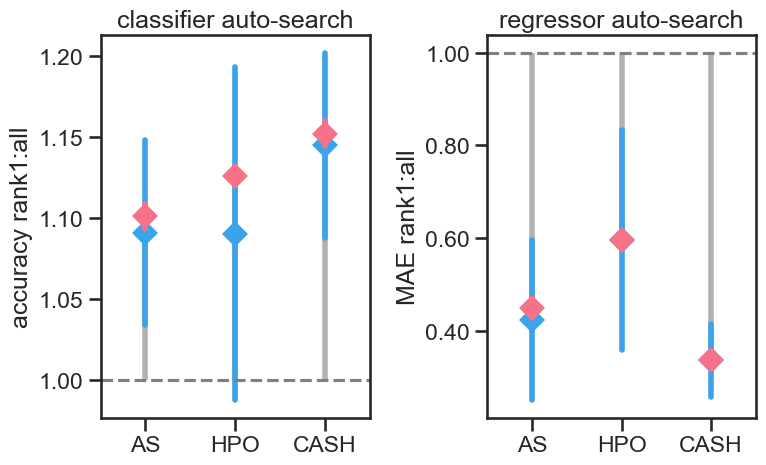

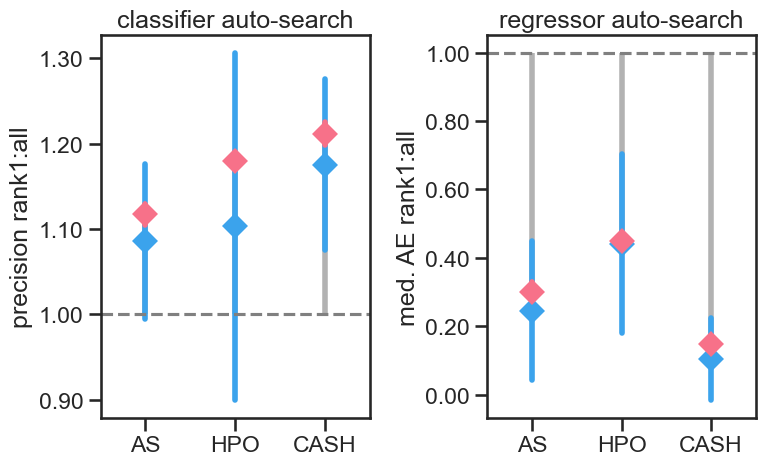

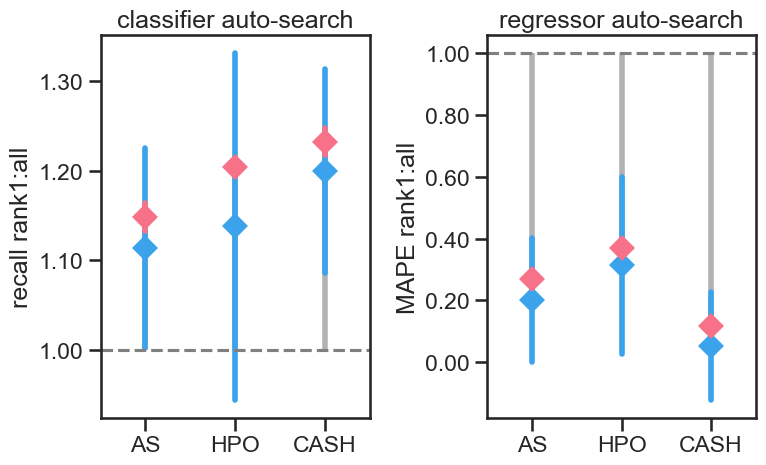

In [28]:
fig,ax=plt.subplots(1,2,figsize=(4*2,5))

df = pd.concat([out_agg_dict[file_name] for file_name in list_class_problems],keys=list_class_problems).reset_index(); df=df[(df['fold']=='test')]
metrics=scores_to_analyze_dict[list_class_problems[0]]

df_as = (df[df['rank_as_mean_'+metrics[0]]==1].groupby(['level_0','iteration', 'outer_k'],sort=False)['mean_'+metrics[0]].mean() / df[df['default_config']=='default'].groupby(['level_0','iteration', 'outer_k'],sort=False)['mean_'+metrics[0]].mean()).reset_index()
df_hpo = (df[df['rank_hpo_mean_'+metrics[0]]==1].groupby(['level_0','iteration', 'outer_k','algorithm'],sort=False)['mean_'+metrics[0]].mean() / df.groupby(['level_0','iteration', 'outer_k','algorithm'],sort=False)['mean_'+metrics[0]].mean()).reset_index()
df_cash = (df[df['rank_cash_mean_'+metrics[0]]==1].groupby(['level_0','iteration', 'outer_k'],sort=False)['mean_'+metrics[0]].mean() / df.groupby(['level_0','iteration', 'outer_k'],sort=False)['mean_'+metrics[0]].mean()).reset_index()
data_to_plot = pd.concat([df_as,df_hpo,df_cash],keys=['AS','HPO','CASH']).rename(columns={'level_0':'dataset'}).reset_index().rename(columns={'level_0':'approach'})

for row in data_to_plot.groupby('approach',sort=False)['mean_'+metrics[0]].mean().reset_index().iterrows():
  ax[0].vlines(x=row[1][0],ymin=1,ymax=row[1][1],color='grey',linewidth=4,alpha=0.6)
sns.pointplot(x='approach',y='mean_'+metrics[0],data=data_to_plot,errorbar='sd',join=False,markers='D',ax=ax[0],estimator=np.median,color=sns.color_palette("husl")[4])
sns.pointplot(x='approach',y='mean_'+metrics[0],data=data_to_plot,errorbar='ci',join=False,markers='D',ax=ax[0])

df = pd.concat([out_agg_dict[file_name] for file_name in list_reg_problems],keys=list_reg_problems).reset_index(); df=df[(df['fold']=='test')]
metrics=scores_to_analyze_dict[list_reg_problems[0]]

df_as = (df[df['rank_as_mean_'+metrics[0]]==1].groupby(['level_0','iteration', 'outer_k'],sort=False)['mean_'+metrics[0]].mean() / df[df['default_config']=='default'].groupby(['level_0','iteration', 'outer_k'],sort=False)['mean_'+metrics[0]].mean()).reset_index()
df_hpo = (df[df['rank_hpo_mean_'+metrics[0]]==1].groupby(['level_0','iteration', 'outer_k','algorithm'],sort=False)['mean_'+metrics[0]].mean() / df.groupby(['level_0','iteration', 'outer_k','algorithm'],sort=False)['mean_'+metrics[0]].mean()).reset_index()
df_cash = (df[df['rank_cash_mean_'+metrics[0]]==1].groupby(['level_0','iteration', 'outer_k'],sort=False)['mean_'+metrics[0]].mean() / df.groupby(['level_0','iteration', 'outer_k'],sort=False)['mean_'+metrics[0]].mean()).reset_index()
data_to_plot = pd.concat([df_as,df_hpo,df_cash],keys=['AS','HPO','CASH']).rename(columns={'level_0':'dataset'}).reset_index().rename(columns={'level_0':'approach'})

for row in data_to_plot.groupby('approach',sort=False)['mean_'+metrics[0]].mean().reset_index().iterrows():
  ax[1].vlines(x=row[1][0],ymax=1,ymin=row[1][1],color='grey',linewidth=4,alpha=0.6)
sns.pointplot(x='approach',y='mean_'+metrics[0],data=data_to_plot,errorbar='sd',join=False,markers='D',ax=ax[1],estimator=np.median,color=sns.color_palette("husl")[4])
sns.pointplot(x='approach',y='mean_'+metrics[0],data=data_to_plot,errorbar='ci',join=False,markers='D',ax=ax[1])


ax[0].set_ylabel('accuracy rank1:all'); ax[0].set_title('classifier auto-search'); 
ax[1].set_ylabel('MAE rank1:all'); ax[1].set_title('regressor auto-search'); 

for ax in plt.gcf().axes:
  ax.set_xlabel(''); ax.axhline(1,color='grey',linestyle='--'); ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))

fig.tight_layout()


fig,ax=plt.subplots(1,2,figsize=(4*2,5))

df = pd.concat([out_agg_dict[file_name] for file_name in list_class_problems],keys=list_class_problems).reset_index(); df=df[(df['fold']=='test')]
metrics=scores_to_analyze_dict[list_class_problems[0]]

df_as = (df[df['rank_as_mean_'+metrics[1]]==1].groupby(['level_0','iteration', 'outer_k'],sort=False)['mean_'+metrics[1]].mean() / df[df['default_config']=='default'].groupby(['level_0','iteration', 'outer_k'],sort=False)['mean_'+metrics[1]].mean()).reset_index()
df_hpo = (df[df['rank_hpo_mean_'+metrics[1]]==1].groupby(['level_0','iteration', 'outer_k','algorithm'],sort=False)['mean_'+metrics[1]].mean() / df.groupby(['level_0','iteration', 'outer_k','algorithm'],sort=False)['mean_'+metrics[1]].mean()).reset_index()
df_cash = (df[df['rank_cash_mean_'+metrics[1]]==1].groupby(['level_0','iteration', 'outer_k'],sort=False)['mean_'+metrics[1]].mean() / df.groupby(['level_0','iteration', 'outer_k'],sort=False)['mean_'+metrics[1]].mean()).reset_index()
data_to_plot = pd.concat([df_as,df_hpo,df_cash],keys=['AS','HPO','CASH']).rename(columns={'level_0':'dataset'}).reset_index().rename(columns={'level_0':'approach'})

# for row in data_to_plot.groupby('approach',sort=False)['mean_'+metrics[1]].median().reset_index().iterrows():
#   ax[0].vlines(x=row[1][0],ymin=1,ymax=row[1][1],color='grey',linewidth=4,alpha=0.3)
for row in data_to_plot.groupby('approach',sort=False)['mean_'+metrics[1]].mean().reset_index().iterrows():
  ax[0].vlines(x=row[1][0],ymin=1,ymax=row[1][1],color='grey',linewidth=4,alpha=0.6)
sns.pointplot(x='approach',y='mean_'+metrics[1],data=data_to_plot,errorbar='sd',join=False,markers='D',ax=ax[0],estimator=np.median,color=sns.color_palette("husl")[4])
sns.pointplot(x='approach',y='mean_'+metrics[1],data=data_to_plot,errorbar='ci',join=False,markers='D',ax=ax[0])

df = pd.concat([out_agg_dict[file_name] for file_name in list_reg_problems],keys=list_reg_problems).reset_index(); df=df[(df['fold']=='test')]
metrics=scores_to_analyze_dict[list_reg_problems[0]]

df_as = (df[df['rank_as_mean_'+metrics[1]]==1].groupby(['level_0','iteration', 'outer_k'],sort=False)['mean_'+metrics[1]].mean() / df[df['default_config']=='default'].groupby(['level_0','iteration', 'outer_k'],sort=False)['mean_'+metrics[1]].mean()).reset_index()
df_hpo = (df[df['rank_hpo_mean_'+metrics[1]]==1].groupby(['level_0','iteration', 'outer_k','algorithm'],sort=False)['mean_'+metrics[1]].mean() / df.groupby(['level_0','iteration', 'outer_k','algorithm'],sort=False)['mean_'+metrics[1]].mean()).reset_index()
df_cash = (df[df['rank_cash_mean_'+metrics[1]]==1].groupby(['level_0','iteration', 'outer_k'],sort=False)['mean_'+metrics[1]].mean() / df.groupby(['level_0','iteration', 'outer_k'],sort=False)['mean_'+metrics[1]].mean()).reset_index()
data_to_plot = pd.concat([df_as,df_hpo,df_cash],keys=['AS','HPO','CASH']).rename(columns={'level_0':'dataset'}).reset_index().rename(columns={'level_0':'approach'})

# for row in data_to_plot.groupby('approach',sort=False)['mean_'+metrics[1]].median().reset_index().iterrows():
#   ax[1].vlines(x=row[1][0],ymax=1,ymin=row[1][1],color='grey',linewidth=4,alpha=0.3)
for row in data_to_plot.groupby('approach',sort=False)['mean_'+metrics[1]].mean().reset_index().iterrows():
  ax[1].vlines(x=row[1][0],ymax=1,ymin=row[1][1],color='grey',linewidth=4,alpha=0.6)
sns.pointplot(x='approach',y='mean_'+metrics[1],data=data_to_plot,errorbar='sd',join=False,markers='D',ax=ax[1],estimator=np.median,color=sns.color_palette("husl")[4])
sns.pointplot(x='approach',y='mean_'+metrics[1],data=data_to_plot,errorbar='ci',join=False,markers='D',ax=ax[1])


ax[0].set_ylabel('precision rank1:all'); ax[0].set_title('classifier auto-search'); 
ax[1].set_ylabel('med. AE rank1:all'); ax[1].set_title('regressor auto-search'); 

for ax in plt.gcf().axes:
  ax.set_xlabel(''); ax.axhline(1,color='grey',linestyle='--'); ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))

fig.tight_layout()


fig,ax=plt.subplots(1,2,figsize=(4*2,5))

df = pd.concat([out_agg_dict[file_name] for file_name in list_class_problems],keys=list_class_problems).reset_index(); df=df[(df['fold']=='test')]
metrics=scores_to_analyze_dict[list_class_problems[0]]

df_as = (df[df['rank_as_mean_'+metrics[2]]==1].groupby(['level_0','iteration', 'outer_k'],sort=False)['mean_'+metrics[2]].mean() / df[df['default_config']=='default'].groupby(['level_0','iteration', 'outer_k'],sort=False)['mean_'+metrics[2]].mean()).reset_index()
df_hpo = (df[df['rank_hpo_mean_'+metrics[2]]==1].groupby(['level_0','iteration', 'outer_k','algorithm'],sort=False)['mean_'+metrics[2]].mean() / df.groupby(['level_0','iteration', 'outer_k','algorithm'],sort=False)['mean_'+metrics[2]].mean()).reset_index()
df_cash = (df[df['rank_cash_mean_'+metrics[2]]==1].groupby(['level_0','iteration', 'outer_k'],sort=False)['mean_'+metrics[2]].mean() / df.groupby(['level_0','iteration', 'outer_k'],sort=False)['mean_'+metrics[2]].mean()).reset_index()
data_to_plot = pd.concat([df_as,df_hpo,df_cash],keys=['AS','HPO','CASH']).rename(columns={'level_0':'dataset'}).reset_index().rename(columns={'level_0':'approach'})

# for row in data_to_plot.groupby('approach',sort=False)['mean_'+metrics[2]].median().reset_index().iterrows():
#   ax[0].vlines(x=row[1][0],ymin=1,ymax=row[1][1],color='grey',linewidth=4,alpha=0.3)
for row in data_to_plot.groupby('approach',sort=False)['mean_'+metrics[2]].mean().reset_index().iterrows():
  ax[0].vlines(x=row[1][0],ymin=1,ymax=row[1][1],color='grey',linewidth=4,alpha=0.6)
sns.pointplot(x='approach',y='mean_'+metrics[2],data=data_to_plot,errorbar='sd',join=False,markers='D',ax=ax[0],estimator=np.median,color=sns.color_palette("husl")[4])
sns.pointplot(x='approach',y='mean_'+metrics[2],data=data_to_plot,errorbar='ci',join=False,markers='D',ax=ax[0])

df = pd.concat([out_agg_dict[file_name] for file_name in list_reg_problems],keys=list_reg_problems).reset_index(); df=df[(df['fold']=='test')]
metrics=scores_to_analyze_dict[list_reg_problems[0]]

df_as = (df[df['rank_as_mean_'+metrics[2]]==1].groupby(['level_0','iteration', 'outer_k'],sort=False)['mean_'+metrics[2]].mean() / df[df['default_config']=='default'].groupby(['level_0','iteration', 'outer_k'],sort=False)['mean_'+metrics[2]].mean()).reset_index()
df_hpo = (df[df['rank_hpo_mean_'+metrics[2]]==1].groupby(['level_0','iteration', 'outer_k','algorithm'],sort=False)['mean_'+metrics[2]].mean() / df.groupby(['level_0','iteration', 'outer_k','algorithm'],sort=False)['mean_'+metrics[2]].mean()).reset_index()
df_cash = (df[df['rank_cash_mean_'+metrics[2]]==1].groupby(['level_0','iteration', 'outer_k'],sort=False)['mean_'+metrics[2]].mean() / df.groupby(['level_0','iteration', 'outer_k'],sort=False)['mean_'+metrics[2]].mean()).reset_index()
data_to_plot = pd.concat([df_as,df_hpo,df_cash],keys=['AS','HPO','CASH']).rename(columns={'level_0':'dataset'}).reset_index().rename(columns={'level_0':'approach'})

# for row in data_to_plot.groupby('approach',sort=False)['mean_'+metrics[2]].median().reset_index().iterrows():
#   ax[1].vlines(x=row[1][0],ymax=1,ymin=row[1][1],color='grey',linewidth=4,alpha=0.3)
for row in data_to_plot.groupby('approach',sort=False)['mean_'+metrics[2]].mean().reset_index().iterrows():
  ax[1].vlines(x=row[1][0],ymax=1,ymin=row[1][1],color='grey',linewidth=4,alpha=0.6)
sns.pointplot(x='approach',y='mean_'+metrics[2],data=data_to_plot,errorbar='sd',join=False,markers='D',ax=ax[1],estimator=np.median,color=sns.color_palette("husl")[4])
sns.pointplot(x='approach',y='mean_'+metrics[2],data=data_to_plot,errorbar='ci',join=False,markers='D',ax=ax[1])


ax[0].set_ylabel('recall rank1:all'); ax[0].set_title('classifier auto-search'); 
ax[1].set_ylabel('MAPE rank1:all'); ax[1].set_title('regressor auto-search'); 

for ax in plt.gcf().axes:
  ax.set_xlabel(''); ax.axhline(1,color='grey',linestyle='--'); ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))

fig.tight_layout()

C:\Users\conno\AppData\Local\Temp\ipykernel_2100\3050369527.py:11: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(x='approach',y='mean_'+metrics[0],data=data_to_plot,errorbar='ci',join=False,markers='D',ax=ax[0],hue='dataset')
C:\Users\conno\AppData\Local\Temp\ipykernel_2100\3050369527.py:21: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(x='approach',y='mean_'+metrics[0],data=data_to_plot,errorbar='ci',join=False,markers='D',ax=ax[1],hue='dataset')
C:\Users\conno\AppData\Local\Temp\ipykernel_2100\3050369527.py:42: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(x='approach',y='mean_'+metrics[1],data=data_to_plot,errorbar='ci',join=False,markers

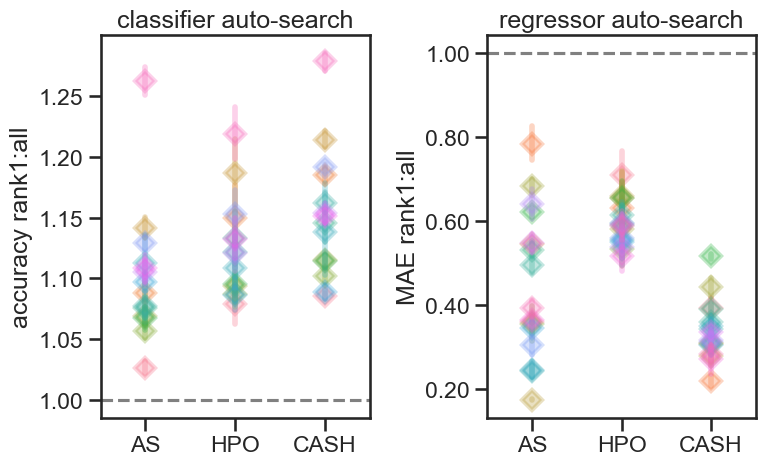

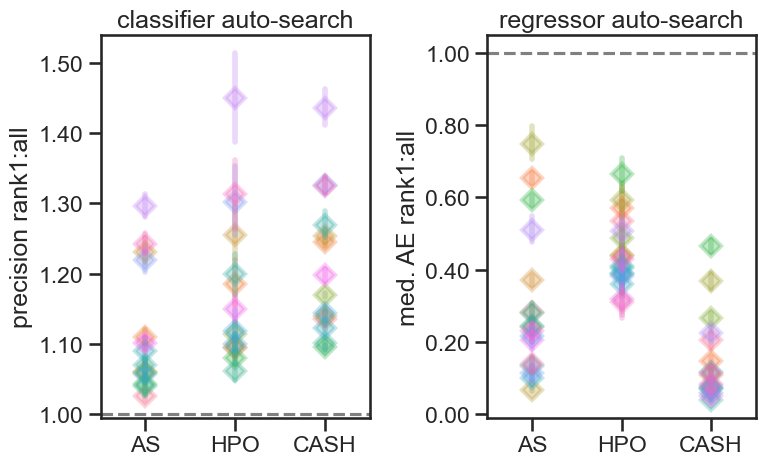

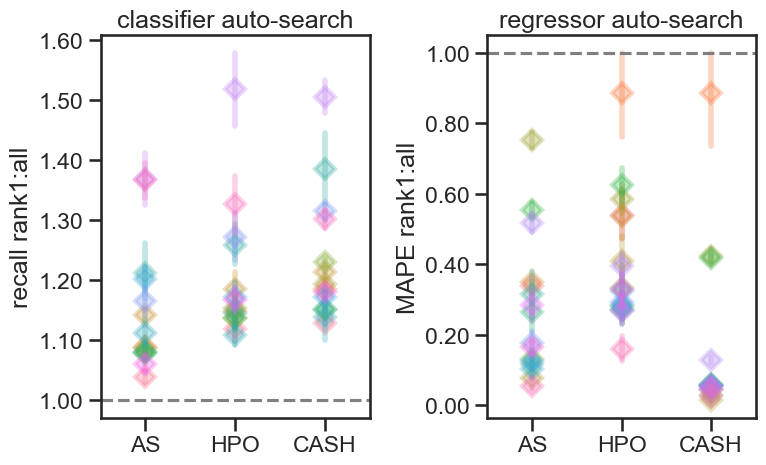

In [29]:
fig,ax=plt.subplots(1,2,figsize=(4*2,5))

df = pd.concat([out_agg_dict[file_name] for file_name in list_class_problems],keys=list_class_problems).reset_index(); df=df[(df['fold']=='test')]
metrics=scores_to_analyze_dict[list_class_problems[0]]

df_as = (df[df['rank_as_mean_'+metrics[0]]==1].groupby(['level_0','iteration', 'outer_k'],sort=False)['mean_'+metrics[0]].mean() / df[df['default_config']=='default'].groupby(['level_0','iteration', 'outer_k'],sort=False)['mean_'+metrics[0]].mean()).reset_index()
df_hpo = (df[df['rank_hpo_mean_'+metrics[0]]==1].groupby(['level_0','iteration', 'outer_k','algorithm'],sort=False)['mean_'+metrics[0]].mean() / df.groupby(['level_0','iteration', 'outer_k','algorithm'],sort=False)['mean_'+metrics[0]].mean()).reset_index()
df_cash = (df[df['rank_cash_mean_'+metrics[0]]==1].groupby(['level_0','iteration', 'outer_k'],sort=False)['mean_'+metrics[0]].mean() / df.groupby(['level_0','iteration', 'outer_k'],sort=False)['mean_'+metrics[0]].mean()).reset_index()
data_to_plot = pd.concat([df_as,df_hpo,df_cash],keys=['AS','HPO','CASH']).rename(columns={'level_0':'dataset'}).reset_index().rename(columns={'level_0':'approach'})

sns.pointplot(x='approach',y='mean_'+metrics[0],data=data_to_plot,errorbar='ci',join=False,markers='D',ax=ax[0],hue='dataset')

df = pd.concat([out_agg_dict[file_name] for file_name in list_reg_problems],keys=list_reg_problems).reset_index(); df=df[(df['fold']=='test')]
metrics=scores_to_analyze_dict[list_reg_problems[0]]

df_as = (df[df['rank_as_mean_'+metrics[0]]==1].groupby(['level_0','iteration', 'outer_k'],sort=False)['mean_'+metrics[0]].mean() / df[df['default_config']=='default'].groupby(['level_0','iteration', 'outer_k'],sort=False)['mean_'+metrics[0]].mean()).reset_index()
df_hpo = (df[df['rank_hpo_mean_'+metrics[0]]==1].groupby(['level_0','iteration', 'outer_k','algorithm'],sort=False)['mean_'+metrics[0]].mean() / df.groupby(['level_0','iteration', 'outer_k','algorithm'],sort=False)['mean_'+metrics[0]].mean()).reset_index()
df_cash = (df[df['rank_cash_mean_'+metrics[0]]==1].groupby(['level_0','iteration', 'outer_k'],sort=False)['mean_'+metrics[0]].mean() / df.groupby(['level_0','iteration', 'outer_k'],sort=False)['mean_'+metrics[0]].mean()).reset_index()
data_to_plot = pd.concat([df_as,df_hpo,df_cash],keys=['AS','HPO','CASH']).rename(columns={'level_0':'dataset'}).reset_index().rename(columns={'level_0':'approach'})

sns.pointplot(x='approach',y='mean_'+metrics[0],data=data_to_plot,errorbar='ci',join=False,markers='D',ax=ax[1],hue='dataset')


ax[0].set_ylabel('accuracy rank1:all'); ax[0].set_title('classifier auto-search'); 
ax[1].set_ylabel('MAE rank1:all'); ax[1].set_title('regressor auto-search'); 

for ax in plt.gcf().axes:
  ax.set_xlabel(''); plt.setp(ax.collections, alpha=.3); plt.setp(ax.lines, alpha=.3); ax.axhline(1,color='grey',linestyle='--'); ax.get_legend().remove(); ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))

fig.tight_layout()

fig,ax=plt.subplots(1,2,figsize=(4*2,5))

df = pd.concat([out_agg_dict[file_name] for file_name in list_class_problems],keys=list_class_problems).reset_index(); df=df[(df['fold']=='test')]
metrics=scores_to_analyze_dict[list_class_problems[0]]

df_as = (df[df['rank_as_mean_'+metrics[1]]==1].groupby(['level_0','iteration', 'outer_k'],sort=False)['mean_'+metrics[1]].mean() / df[df['default_config']=='default'].groupby(['level_0','iteration', 'outer_k'],sort=False)['mean_'+metrics[1]].mean()).reset_index()
df_hpo = (df[df['rank_hpo_mean_'+metrics[1]]==1].groupby(['level_0','iteration', 'outer_k','algorithm'],sort=False)['mean_'+metrics[1]].mean() / df.groupby(['level_0','iteration', 'outer_k','algorithm'],sort=False)['mean_'+metrics[1]].mean()).reset_index()
df_cash = (df[df['rank_cash_mean_'+metrics[1]]==1].groupby(['level_0','iteration', 'outer_k'],sort=False)['mean_'+metrics[1]].mean() / df.groupby(['level_0','iteration', 'outer_k'],sort=False)['mean_'+metrics[1]].mean()).reset_index()
data_to_plot = pd.concat([df_as,df_hpo,df_cash],keys=['AS','HPO','CASH']).rename(columns={'level_0':'dataset'}).reset_index().rename(columns={'level_0':'approach'})

sns.pointplot(x='approach',y='mean_'+metrics[1],data=data_to_plot,errorbar='ci',join=False,markers='D',ax=ax[0],hue='dataset')

df = pd.concat([out_agg_dict[file_name] for file_name in list_reg_problems],keys=list_reg_problems).reset_index(); df=df[(df['fold']=='test')]
metrics=scores_to_analyze_dict[list_reg_problems[0]]

df_as = (df[df['rank_as_mean_'+metrics[1]]==1].groupby(['level_0','iteration', 'outer_k'],sort=False)['mean_'+metrics[1]].mean() / df[df['default_config']=='default'].groupby(['level_0','iteration', 'outer_k'],sort=False)['mean_'+metrics[1]].mean()).reset_index()
df_hpo = (df[df['rank_hpo_mean_'+metrics[1]]==1].groupby(['level_0','iteration', 'outer_k','algorithm'],sort=False)['mean_'+metrics[1]].mean() / df.groupby(['level_0','iteration', 'outer_k','algorithm'],sort=False)['mean_'+metrics[1]].mean()).reset_index()
df_cash = (df[df['rank_cash_mean_'+metrics[1]]==1].groupby(['level_0','iteration', 'outer_k'],sort=False)['mean_'+metrics[1]].mean() / df.groupby(['level_0','iteration', 'outer_k'],sort=False)['mean_'+metrics[1]].mean()).reset_index()
data_to_plot = pd.concat([df_as,df_hpo,df_cash],keys=['AS','HPO','CASH']).rename(columns={'level_0':'dataset'}).reset_index().rename(columns={'level_0':'approach'})

sns.pointplot(x='approach',y='mean_'+metrics[1],data=data_to_plot,errorbar='ci',join=False,markers='D',ax=ax[1],hue='dataset')


ax[0].set_ylabel('precision rank1:all'); ax[0].set_title('classifier auto-search'); 
ax[1].set_ylabel('med. AE rank1:all'); ax[1].set_title('regressor auto-search'); 

for ax in plt.gcf().axes:
  ax.set_xlabel(''); plt.setp(ax.collections, alpha=.3); plt.setp(ax.lines, alpha=.3); ax.axhline(1,color='grey',linestyle='--'); ax.get_legend().remove(); ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))

fig.tight_layout()

fig,ax=plt.subplots(1,2,figsize=(4*2,5))

df = pd.concat([out_agg_dict[file_name] for file_name in list_class_problems],keys=list_class_problems).reset_index(); df=df[(df['fold']=='test')]
metrics=scores_to_analyze_dict[list_class_problems[0]]

df_as = (df[df['rank_as_mean_'+metrics[2]]==1].groupby(['level_0','iteration', 'outer_k'],sort=False)['mean_'+metrics[2]].mean() / df[df['default_config']=='default'].groupby(['level_0','iteration', 'outer_k'],sort=False)['mean_'+metrics[2]].mean()).reset_index()
df_hpo = (df[df['rank_hpo_mean_'+metrics[2]]==1].groupby(['level_0','iteration', 'outer_k','algorithm'],sort=False)['mean_'+metrics[2]].mean() / df.groupby(['level_0','iteration', 'outer_k','algorithm'],sort=False)['mean_'+metrics[2]].mean()).reset_index()
df_cash = (df[df['rank_cash_mean_'+metrics[2]]==1].groupby(['level_0','iteration', 'outer_k'],sort=False)['mean_'+metrics[2]].mean() / df.groupby(['level_0','iteration', 'outer_k'],sort=False)['mean_'+metrics[2]].mean()).reset_index()
data_to_plot = pd.concat([df_as,df_hpo,df_cash],keys=['AS','HPO','CASH']).rename(columns={'level_0':'dataset'}).reset_index().rename(columns={'level_0':'approach'})

sns.pointplot(x='approach',y='mean_'+metrics[2],data=data_to_plot,errorbar='ci',join=False,markers='D',ax=ax[0],hue='dataset')

df = pd.concat([out_agg_dict[file_name] for file_name in list_reg_problems],keys=list_reg_problems).reset_index(); df=df[(df['fold']=='test')]
metrics=scores_to_analyze_dict[list_reg_problems[0]]

df_as = (df[df['rank_as_mean_'+metrics[2]]==1].groupby(['level_0','iteration', 'outer_k'],sort=False)['mean_'+metrics[2]].mean() / df[df['default_config']=='default'].groupby(['level_0','iteration', 'outer_k'],sort=False)['mean_'+metrics[2]].mean()).reset_index()
df_hpo = (df[df['rank_hpo_mean_'+metrics[2]]==1].groupby(['level_0','iteration', 'outer_k','algorithm'],sort=False)['mean_'+metrics[2]].mean() / df.groupby(['level_0','iteration', 'outer_k','algorithm'],sort=False)['mean_'+metrics[2]].mean()).reset_index()
df_cash = (df[df['rank_cash_mean_'+metrics[2]]==1].groupby(['level_0','iteration', 'outer_k'],sort=False)['mean_'+metrics[2]].mean() / df.groupby(['level_0','iteration', 'outer_k'],sort=False)['mean_'+metrics[2]].mean()).reset_index()
data_to_plot = pd.concat([df_as,df_hpo,df_cash],keys=['AS','HPO','CASH']).rename(columns={'level_0':'dataset'}).reset_index().rename(columns={'level_0':'approach'})

sns.pointplot(x='approach',y='mean_'+metrics[2],data=data_to_plot,errorbar='ci',join=False,markers='D',ax=ax[1],hue='dataset')


ax[0].set_ylabel('recall rank1:all'); ax[0].set_title('classifier auto-search'); 
ax[1].set_ylabel('MAPE rank1:all'); ax[1].set_title('regressor auto-search'); 

for ax in plt.gcf().axes:
  ax.set_xlabel(''); plt.setp(ax.collections, alpha=.3); plt.setp(ax.lines, alpha=.3); ax.axhline(1,color='grey',linestyle='--'); ax.get_legend().remove(); ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))

fig.tight_layout()

C:\Users\conno\AppData\Local\Temp\ipykernel_2100\1394590637.py:17: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax[0].vlines(x=row[1][0],ymin=1,ymax=row[1][1],color='grey',linewidth=4,alpha=0.6)
C:\Users\conno\AppData\Local\Temp\ipykernel_2100\1394590637.py:18: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(x='approach',y='outer_'+metrics[0],data=data_to_plot,errorbar='sd',join=False,markers='D',ax=ax[0],estimator=np.median,color=sns.color_palette("husl")[4])
C:\Users\conno\AppData\Local\Temp\ipykernel_2100\1394590637.py:19: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(x

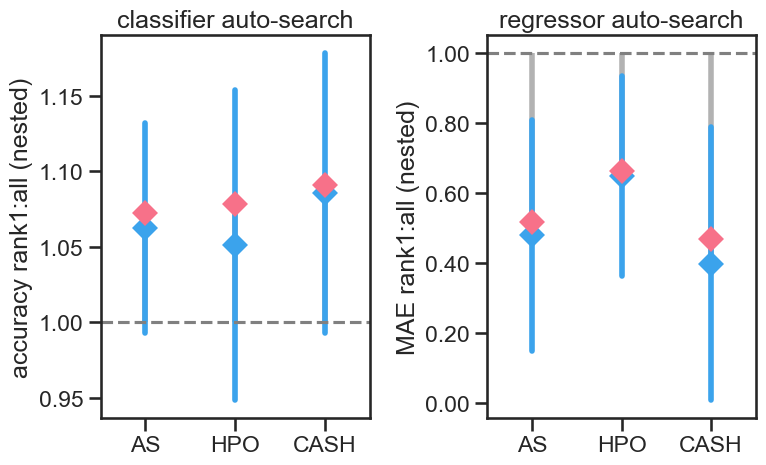

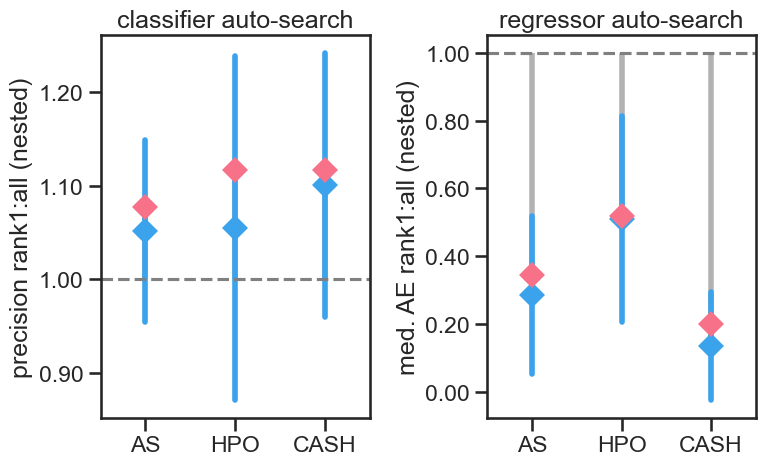

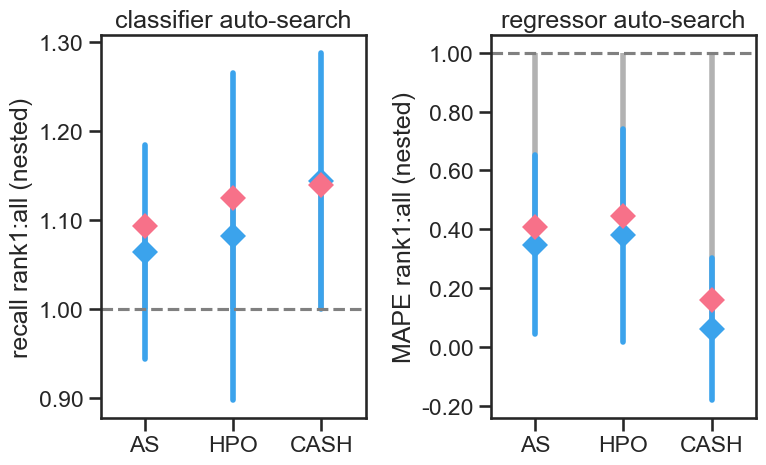

In [30]:
fig,ax=plt.subplots(1,2,figsize=(4*2,5))

holder=[]
metrics=scores_to_analyze_dict[list_class_problems[0]]
for file_name in list_class_problems:
  df=in_agg_out_splits_merge_dict[file_name]
  df_as = (df[df['rank_as_mean_'+metrics[0]]==1].groupby(['iteration', 'outer_k','inner_k'],sort=False)['outer_'+metrics[0]].mean() / df[df['default_config']=='default'].groupby(['iteration', 'outer_k','inner_k'],sort=False)['outer_'+metrics[0]].mean()).reset_index()
  df_hpo = (df[df['rank_hpo_mean_'+metrics[0]]==1].groupby(['iteration', 'outer_k','inner_k','algorithm'],sort=False)['outer_'+metrics[0]].mean() / df.groupby(['iteration', 'outer_k','inner_k','algorithm'],sort=False)['outer_'+metrics[0]].mean()).reset_index()
  df_cash = (df[df['rank_cash_mean_'+metrics[0]]==1].groupby(['iteration', 'outer_k','inner_k'],sort=False)['outer_'+metrics[0]].mean() / df.groupby(['iteration', 'outer_k','inner_k'],sort=False)['outer_'+metrics[0]].mean()).reset_index()
  df_compiled = pd.concat([df_as,df_hpo,df_cash],keys=['AS','HPO','CASH']).reset_index().rename(columns={'level_0':'approach'}).drop(columns='level_1')
  holder.append(df_compiled)
data_to_plot=pd.concat(holder,keys=list_class_problems).reset_index()

# for row in data_to_plot.groupby('approach',sort=False)['mean_'+metrics[0]].median().reset_index().iterrows():
#   ax[0].vlines(x=row[1][0],ymin=1,ymax=row[1][1],color='grey',linewidth=4,alpha=0.3)
for row in data_to_plot.groupby('approach',sort=False)['outer_'+metrics[0]].mean().reset_index().iterrows():
  ax[0].vlines(x=row[1][0],ymin=1,ymax=row[1][1],color='grey',linewidth=4,alpha=0.6)
sns.pointplot(x='approach',y='outer_'+metrics[0],data=data_to_plot,errorbar='sd',join=False,markers='D',ax=ax[0],estimator=np.median,color=sns.color_palette("husl")[4])
sns.pointplot(x='approach',y='outer_'+metrics[0],data=data_to_plot,errorbar='ci',join=False,markers='D',ax=ax[0])

holder=[]
metrics=scores_to_analyze_dict[list_reg_problems[0]]
for file_name in list_reg_problems:
  df=in_agg_out_splits_merge_dict[file_name]
  df_as = (df[df['rank_as_mean_'+metrics[0]]==1].groupby(['iteration', 'outer_k','inner_k'],sort=False)['outer_'+metrics[0]].mean() / df[df['default_config']=='default'].groupby(['iteration', 'outer_k','inner_k'],sort=False)['outer_'+metrics[0]].mean()).reset_index()
  df_hpo = (df[df['rank_hpo_mean_'+metrics[0]]==1].groupby(['iteration', 'outer_k','inner_k','algorithm'],sort=False)['outer_'+metrics[0]].mean() / df.groupby(['iteration', 'outer_k','inner_k','algorithm'],sort=False)['outer_'+metrics[0]].mean()).reset_index()
  df_cash = (df[df['rank_cash_mean_'+metrics[0]]==1].groupby(['iteration', 'outer_k','inner_k'],sort=False)['outer_'+metrics[0]].mean() / df.groupby(['iteration', 'outer_k','inner_k'],sort=False)['outer_'+metrics[0]].mean()).reset_index()
  df_compiled = pd.concat([df_as,df_hpo,df_cash],keys=['AS','HPO','CASH']).reset_index().rename(columns={'level_0':'approach'}).drop(columns='level_1')
  holder.append(df_compiled)
data_to_plot=pd.concat(holder,keys=list_reg_problems).reset_index()

# for row in data_to_plot.groupby('approach',sort=False)['mean_'+metrics[0]].median().reset_index().iterrows():
#   ax[1].vlines(x=row[1][0],ymax=1,ymin=row[1][1],color='grey',linewidth=4,alpha=0.3)
for row in data_to_plot.groupby('approach',sort=False)['outer_'+metrics[0]].median().reset_index().iterrows():
  ax[1].vlines(x=row[1][0],ymax=1,ymin=row[1][1],color='grey',linewidth=4,alpha=0.6)
sns.pointplot(x='approach',y='outer_'+metrics[0],data=data_to_plot,errorbar='sd',join=False,markers='D',ax=ax[1],estimator=np.median,color=sns.color_palette("husl")[4])
sns.pointplot(x='approach',y='outer_'+metrics[0],data=data_to_plot,errorbar='ci',join=False,markers='D',ax=ax[1])

ax[0].set_ylabel('accuracy rank1:all (nested)'); ax[0].set_title('classifier auto-search'); 
ax[1].set_ylabel('MAE rank1:all (nested)'); ax[1].set_title('regressor auto-search'); 

for ax in plt.gcf().axes:
  ax.set_xlabel(''); ax.axhline(1,color='grey',linestyle='--'); ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))

fig.tight_layout()


fig,ax=plt.subplots(1,2,figsize=(4*2,5))

holder=[]
metrics=scores_to_analyze_dict[list_class_problems[0]]
for file_name in list_class_problems:
  df=in_agg_out_splits_merge_dict[file_name]
  df_as = (df[df['rank_as_mean_'+metrics[1]]==1].groupby(['iteration', 'outer_k','inner_k'],sort=False)['outer_'+metrics[1]].mean() / df[df['default_config']=='default'].groupby(['iteration', 'outer_k','inner_k'],sort=False)['outer_'+metrics[1]].mean()).reset_index()
  df_hpo = (df[df['rank_hpo_mean_'+metrics[1]]==1].groupby(['iteration', 'outer_k','inner_k','algorithm'],sort=False)['outer_'+metrics[1]].mean() / df.groupby(['iteration', 'outer_k','inner_k','algorithm'],sort=False)['outer_'+metrics[1]].mean()).reset_index()
  df_cash = (df[df['rank_cash_mean_'+metrics[1]]==1].groupby(['iteration', 'outer_k','inner_k'],sort=False)['outer_'+metrics[1]].mean() / df.groupby(['iteration', 'outer_k','inner_k'],sort=False)['outer_'+metrics[1]].mean()).reset_index()
  df_compiled = pd.concat([df_as,df_hpo,df_cash],keys=['AS','HPO','CASH']).reset_index().rename(columns={'level_0':'approach'}).drop(columns='level_1')
  holder.append(df_compiled)
data_to_plot=pd.concat(holder,keys=list_class_problems).reset_index()

# for row in data_to_plot.groupby('approach',sort=False)['mean_'+metrics[1]].median().reset_index().iterrows():
#   ax[0].vlines(x=row[1][0],ymin=1,ymax=row[1][1],color='grey',linewidth=4,alpha=0.3)
for row in data_to_plot.groupby('approach',sort=False)['outer_'+metrics[1]].mean().reset_index().iterrows():
  ax[0].vlines(x=row[1][0],ymin=1,ymax=row[1][1],color='grey',linewidth=4,alpha=0.6)
sns.pointplot(x='approach',y='outer_'+metrics[1],data=data_to_plot,errorbar='sd',join=False,markers='D',ax=ax[0],estimator=np.median,color=sns.color_palette("husl")[4])
sns.pointplot(x='approach',y='outer_'+metrics[1],data=data_to_plot,errorbar='ci',join=False,markers='D',ax=ax[0])

holder=[]
metrics=scores_to_analyze_dict[list_reg_problems[0]]
for file_name in list_reg_problems:
  df=in_agg_out_splits_merge_dict[file_name]
  df_as = (df[df['rank_as_mean_'+metrics[1]]==1].groupby(['iteration', 'outer_k','inner_k'],sort=False)['outer_'+metrics[1]].mean() / df[df['default_config']=='default'].groupby(['iteration', 'outer_k','inner_k'],sort=False)['outer_'+metrics[1]].mean()).reset_index()
  df_hpo = (df[df['rank_hpo_mean_'+metrics[1]]==1].groupby(['iteration', 'outer_k','inner_k','algorithm'],sort=False)['outer_'+metrics[1]].mean() / df.groupby(['iteration', 'outer_k','inner_k','algorithm'],sort=False)['outer_'+metrics[1]].mean()).reset_index()
  df_cash = (df[df['rank_cash_mean_'+metrics[1]]==1].groupby(['iteration', 'outer_k','inner_k'],sort=False)['outer_'+metrics[1]].mean() / df.groupby(['iteration', 'outer_k','inner_k'],sort=False)['outer_'+metrics[1]].mean()).reset_index()
  df_compiled = pd.concat([df_as,df_hpo,df_cash],keys=['AS','HPO','CASH']).reset_index().rename(columns={'level_0':'approach'}).drop(columns='level_1')
  holder.append(df_compiled)
data_to_plot=pd.concat(holder,keys=list_reg_problems).reset_index()

# for row in data_to_plot.groupby('approach',sort=False)['mean_'+metrics[1]].median().reset_index().iterrows():
#   ax[1].vlines(x=row[1][0],ymax=1,ymin=row[1][1],color='grey',linewidth=4,alpha=0.3)
for row in data_to_plot.groupby('approach',sort=False)['outer_'+metrics[1]].median().reset_index().iterrows():
  ax[1].vlines(x=row[1][0],ymax=1,ymin=row[1][1],color='grey',linewidth=4,alpha=0.6)
sns.pointplot(x='approach',y='outer_'+metrics[1],data=data_to_plot,errorbar='sd',join=False,markers='D',ax=ax[1],estimator=np.median,color=sns.color_palette("husl")[4])
sns.pointplot(x='approach',y='outer_'+metrics[1],data=data_to_plot,errorbar='ci',join=False,markers='D',ax=ax[1])

ax[0].set_ylabel('precision rank1:all (nested)'); ax[0].set_title('classifier auto-search'); 
ax[1].set_ylabel('med. AE rank1:all (nested)'); ax[1].set_title('regressor auto-search'); 

for ax in plt.gcf().axes:
  ax.set_xlabel(''); ax.axhline(1,color='grey',linestyle='--'); ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))

fig.tight_layout()

fig,ax=plt.subplots(1,2,figsize=(4*2,5))

holder=[]
metrics=scores_to_analyze_dict[list_class_problems[0]]
for file_name in list_class_problems:
  df=in_agg_out_splits_merge_dict[file_name]
  df_as = (df[df['rank_as_mean_'+metrics[2]]==1].groupby(['iteration', 'outer_k','inner_k'],sort=False)['outer_'+metrics[2]].mean() / df[df['default_config']=='default'].groupby(['iteration', 'outer_k','inner_k'],sort=False)['outer_'+metrics[2]].mean()).reset_index()
  df_hpo = (df[df['rank_hpo_mean_'+metrics[2]]==1].groupby(['iteration', 'outer_k','inner_k','algorithm'],sort=False)['outer_'+metrics[2]].mean() / df.groupby(['iteration', 'outer_k','inner_k','algorithm'],sort=False)['outer_'+metrics[2]].mean()).reset_index()
  df_cash = (df[df['rank_cash_mean_'+metrics[2]]==1].groupby(['iteration', 'outer_k','inner_k'],sort=False)['outer_'+metrics[2]].mean() / df.groupby(['iteration', 'outer_k','inner_k'],sort=False)['outer_'+metrics[2]].mean()).reset_index()
  df_compiled = pd.concat([df_as,df_hpo,df_cash],keys=['AS','HPO','CASH']).reset_index().rename(columns={'level_0':'approach'}).drop(columns='level_1')
  holder.append(df_compiled)
data_to_plot=pd.concat(holder,keys=list_class_problems).reset_index()

# for row in data_to_plot.groupby('approach',sort=False)['mean_'+metrics[2]].median().reset_index().iterrows():
#   ax[0].vlines(x=row[1][0],ymin=1,ymax=row[1][1],color='grey',linewidth=4,alpha=0.3)
for row in data_to_plot.groupby('approach',sort=False)['outer_'+metrics[2]].mean().reset_index().iterrows():
  ax[0].vlines(x=row[1][0],ymin=1,ymax=row[1][1],color='grey',linewidth=4,alpha=0.6)
sns.pointplot(x='approach',y='outer_'+metrics[2],data=data_to_plot,errorbar='sd',join=False,markers='D',ax=ax[0],estimator=np.median,color=sns.color_palette("husl")[4])
sns.pointplot(x='approach',y='outer_'+metrics[2],data=data_to_plot,errorbar='ci',join=False,markers='D',ax=ax[0])

holder=[]
metrics=scores_to_analyze_dict[list_reg_problems[0]]
for file_name in list_reg_problems:
  df=in_agg_out_splits_merge_dict[file_name]
  df_as = (df[df['rank_as_mean_'+metrics[2]]==1].groupby(['iteration', 'outer_k','inner_k'],sort=False)['outer_'+metrics[2]].mean() / df[df['default_config']=='default'].groupby(['iteration', 'outer_k','inner_k'],sort=False)['outer_'+metrics[2]].mean()).reset_index()
  df_hpo = (df[df['rank_hpo_mean_'+metrics[2]]==1].groupby(['iteration', 'outer_k','inner_k','algorithm'],sort=False)['outer_'+metrics[2]].mean() / df.groupby(['iteration', 'outer_k','inner_k','algorithm'],sort=False)['outer_'+metrics[2]].mean()).reset_index()
  df_cash = (df[df['rank_cash_mean_'+metrics[2]]==1].groupby(['iteration', 'outer_k','inner_k'],sort=False)['outer_'+metrics[2]].mean() / df.groupby(['iteration', 'outer_k','inner_k'],sort=False)['outer_'+metrics[2]].mean()).reset_index()
  df_compiled = pd.concat([df_as,df_hpo,df_cash],keys=['AS','HPO','CASH']).reset_index().rename(columns={'level_0':'approach'}).drop(columns='level_1')
  holder.append(df_compiled)
data_to_plot=pd.concat(holder,keys=list_reg_problems).reset_index()

# for row in data_to_plot.groupby('approach',sort=False)['mean_'+metrics[2]].median().reset_index().iterrows():
#   ax[1].vlines(x=row[1][0],ymax=1,ymin=row[1][1],color='grey',linewidth=4,alpha=0.3)
for row in data_to_plot.groupby('approach',sort=False)['outer_'+metrics[2]].median().reset_index().iterrows():
  ax[1].vlines(x=row[1][0],ymax=1,ymin=row[1][1],color='grey',linewidth=4,alpha=0.6)
sns.pointplot(x='approach',y='outer_'+metrics[2],data=data_to_plot,errorbar='sd',join=False,markers='D',ax=ax[1],estimator=np.median,color=sns.color_palette("husl")[4])
sns.pointplot(x='approach',y='outer_'+metrics[2],data=data_to_plot,errorbar='ci',join=False,markers='D',ax=ax[1])

ax[0].set_ylabel('recall rank1:all (nested)'); ax[0].set_title('classifier auto-search'); 
ax[1].set_ylabel('MAPE rank1:all (nested)'); ax[1].set_title('regressor auto-search'); 

for ax in plt.gcf().axes:
  ax.set_xlabel(''); ax.axhline(1,color='grey',linestyle='--'); ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))

fig.tight_layout()

C:\Users\conno\AppData\Local\Temp\ipykernel_2100\184994632.py:13: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(x='approach',y='outer_'+metrics[0],data=data_to_plot,errorbar='ci',join=False,markers='D',ax=ax[0],hue='level_0')
C:\Users\conno\AppData\Local\Temp\ipykernel_2100\184994632.py:25: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(x='approach',y='outer_'+metrics[0],data=data_to_plot,errorbar='ci',join=False,markers='D',ax=ax[1],hue='level_0')
C:\Users\conno\AppData\Local\Temp\ipykernel_2100\184994632.py:48: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(x='approach',y='outer_'+metrics[1],data=data_to_plot,errorbar='ci',join=False,markers

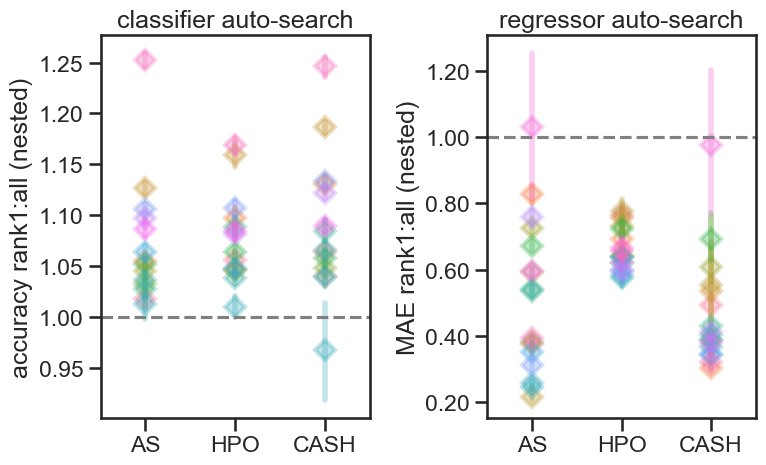

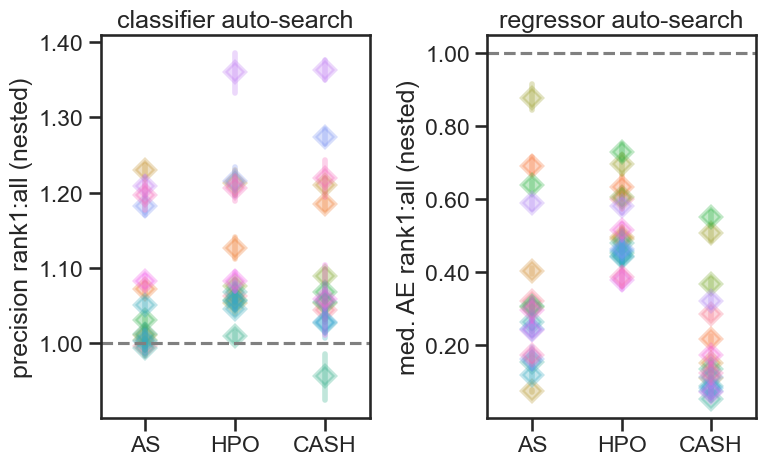

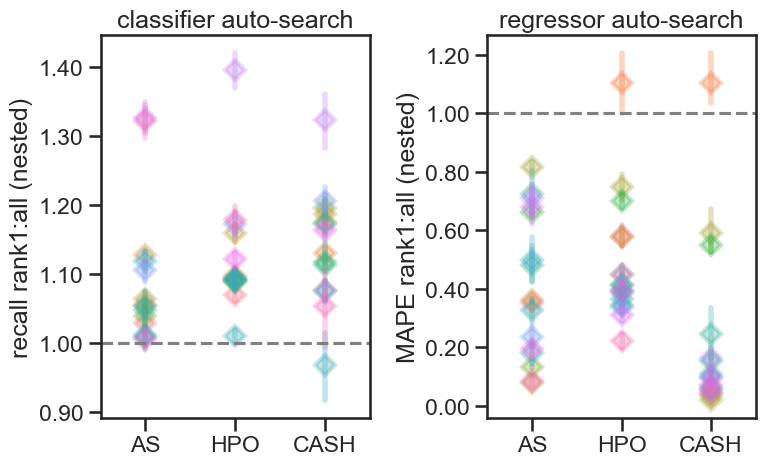

In [31]:
fig,ax=plt.subplots(1,2,figsize=(4*2,5))

holder=[]
metrics=scores_to_analyze_dict[list_class_problems[0]]
for file_name in list_class_problems:
  df=in_agg_out_splits_merge_dict[file_name]
  df_as = (df[df['rank_as_mean_'+metrics[0]]==1].groupby(['iteration', 'outer_k','inner_k'],sort=False)['outer_'+metrics[0]].mean() / df[df['default_config']=='default'].groupby(['iteration', 'outer_k','inner_k'],sort=False)['outer_'+metrics[0]].mean()).reset_index()
  df_hpo = (df[df['rank_hpo_mean_'+metrics[0]]==1].groupby(['iteration', 'outer_k','inner_k','algorithm'],sort=False)['outer_'+metrics[0]].mean() / df.groupby(['iteration', 'outer_k','inner_k','algorithm'],sort=False)['outer_'+metrics[0]].mean()).reset_index()
  df_cash = (df[df['rank_cash_mean_'+metrics[0]]==1].groupby(['iteration', 'outer_k','inner_k'],sort=False)['outer_'+metrics[0]].mean() / df.groupby(['iteration', 'outer_k','inner_k'],sort=False)['outer_'+metrics[0]].mean()).reset_index()
  df_compiled = pd.concat([df_as,df_hpo,df_cash],keys=['AS','HPO','CASH']).reset_index().rename(columns={'level_0':'approach'}).drop(columns='level_1')
  holder.append(df_compiled)
data_to_plot=pd.concat(holder,keys=list_class_problems).reset_index()
sns.pointplot(x='approach',y='outer_'+metrics[0],data=data_to_plot,errorbar='ci',join=False,markers='D',ax=ax[0],hue='level_0')

holder=[]
metrics=scores_to_analyze_dict[list_reg_problems[0]]
for file_name in list_reg_problems:
  df=in_agg_out_splits_merge_dict[file_name]
  df_as = (df[df['rank_as_mean_'+metrics[0]]==1].groupby(['iteration', 'outer_k','inner_k'],sort=False)['outer_'+metrics[0]].mean() / df[df['default_config']=='default'].groupby(['iteration', 'outer_k','inner_k'],sort=False)['outer_'+metrics[0]].mean()).reset_index()
  df_hpo = (df[df['rank_hpo_mean_'+metrics[0]]==1].groupby(['iteration', 'outer_k','inner_k','algorithm'],sort=False)['outer_'+metrics[0]].mean() / df.groupby(['iteration', 'outer_k','inner_k','algorithm'],sort=False)['outer_'+metrics[0]].mean()).reset_index()
  df_cash = (df[df['rank_cash_mean_'+metrics[0]]==1].groupby(['iteration', 'outer_k','inner_k'],sort=False)['outer_'+metrics[0]].mean() / df.groupby(['iteration', 'outer_k','inner_k'],sort=False)['outer_'+metrics[0]].mean()).reset_index()
  df_compiled = pd.concat([df_as,df_hpo,df_cash],keys=['AS','HPO','CASH']).reset_index().rename(columns={'level_0':'approach'}).drop(columns='level_1')
  holder.append(df_compiled)
data_to_plot=pd.concat(holder,keys=list_reg_problems).reset_index()
sns.pointplot(x='approach',y='outer_'+metrics[0],data=data_to_plot,errorbar='ci',join=False,markers='D',ax=ax[1],hue='level_0')

ax[0].set_ylabel('accuracy rank1:all (nested)'); ax[0].set_title('classifier auto-search'); 
ax[1].set_ylabel('MAE rank1:all (nested)'); ax[1].set_title('regressor auto-search'); 

for ax in plt.gcf().axes:
  ax.set_xlabel(''); plt.setp(ax.collections, alpha=.3); plt.setp(ax.lines, alpha=.3); ax.axhline(1,color='grey',linestyle='--'); ax.get_legend().remove(); ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))

fig.tight_layout()


fig,ax=plt.subplots(1,2,figsize=(4*2,5))

holder=[]
metrics=scores_to_analyze_dict[list_class_problems[0]]
for file_name in list_class_problems:
  df=in_agg_out_splits_merge_dict[file_name]
  df_as = (df[df['rank_as_mean_'+metrics[1]]==1].groupby(['iteration', 'outer_k','inner_k'],sort=False)['outer_'+metrics[1]].mean() / df[df['default_config']=='default'].groupby(['iteration', 'outer_k','inner_k'],sort=False)['outer_'+metrics[1]].mean()).reset_index()
  df_hpo = (df[df['rank_hpo_mean_'+metrics[1]]==1].groupby(['iteration', 'outer_k','inner_k','algorithm'],sort=False)['outer_'+metrics[1]].mean() / df.groupby(['iteration', 'outer_k','inner_k','algorithm'],sort=False)['outer_'+metrics[1]].mean()).reset_index()
  df_cash = (df[df['rank_cash_mean_'+metrics[1]]==1].groupby(['iteration', 'outer_k','inner_k'],sort=False)['outer_'+metrics[1]].mean() / df.groupby(['iteration', 'outer_k','inner_k'],sort=False)['outer_'+metrics[1]].mean()).reset_index()
  df_compiled = pd.concat([df_as,df_hpo,df_cash],keys=['AS','HPO','CASH']).reset_index().rename(columns={'level_0':'approach'}).drop(columns='level_1')
  holder.append(df_compiled)
data_to_plot=pd.concat(holder,keys=list_class_problems).reset_index()
sns.pointplot(x='approach',y='outer_'+metrics[1],data=data_to_plot,errorbar='ci',join=False,markers='D',ax=ax[0],hue='level_0')

holder=[]
metrics=scores_to_analyze_dict[list_reg_problems[0]]
for file_name in list_reg_problems:
  df=in_agg_out_splits_merge_dict[file_name]
  df_as = (df[df['rank_as_mean_'+metrics[1]]==1].groupby(['iteration', 'outer_k','inner_k'],sort=False)['outer_'+metrics[1]].mean() / df[df['default_config']=='default'].groupby(['iteration', 'outer_k','inner_k'],sort=False)['outer_'+metrics[1]].mean()).reset_index()
  df_hpo = (df[df['rank_hpo_mean_'+metrics[1]]==1].groupby(['iteration', 'outer_k','inner_k','algorithm'],sort=False)['outer_'+metrics[1]].mean() / df.groupby(['iteration', 'outer_k','inner_k','algorithm'],sort=False)['outer_'+metrics[1]].mean()).reset_index()
  df_cash = (df[df['rank_cash_mean_'+metrics[1]]==1].groupby(['iteration', 'outer_k','inner_k'],sort=False)['outer_'+metrics[1]].mean() / df.groupby(['iteration', 'outer_k','inner_k'],sort=False)['outer_'+metrics[1]].mean()).reset_index()
  df_compiled = pd.concat([df_as,df_hpo,df_cash],keys=['AS','HPO','CASH']).reset_index().rename(columns={'level_0':'approach'}).drop(columns='level_1')
  holder.append(df_compiled)
data_to_plot=pd.concat(holder,keys=list_reg_problems).reset_index()
sns.pointplot(x='approach',y='outer_'+metrics[1],data=data_to_plot,errorbar='ci',join=False,markers='D',ax=ax[1],hue='level_0')

ax[0].set_ylabel('precision rank1:all (nested)'); ax[0].set_title('classifier auto-search'); 
ax[1].set_ylabel('med. AE rank1:all (nested)'); ax[1].set_title('regressor auto-search'); 

for ax in plt.gcf().axes:
  ax.set_xlabel(''); plt.setp(ax.collections, alpha=.3); plt.setp(ax.lines, alpha=.3); ax.axhline(1,color='grey',linestyle='--'); ax.get_legend().remove(); ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))

fig.tight_layout()

fig,ax=plt.subplots(1,2,figsize=(4*2,5))

holder=[]
metrics=scores_to_analyze_dict[list_class_problems[0]]
for file_name in list_class_problems:
  df=in_agg_out_splits_merge_dict[file_name]
  df_as = (df[df['rank_as_mean_'+metrics[2]]==1].groupby(['iteration', 'outer_k','inner_k'],sort=False)['outer_'+metrics[2]].mean() / df[df['default_config']=='default'].groupby(['iteration', 'outer_k','inner_k'],sort=False)['outer_'+metrics[2]].mean()).reset_index()
  df_hpo = (df[df['rank_hpo_mean_'+metrics[2]]==1].groupby(['iteration', 'outer_k','inner_k','algorithm'],sort=False)['outer_'+metrics[2]].mean() / df.groupby(['iteration', 'outer_k','inner_k','algorithm'],sort=False)['outer_'+metrics[2]].mean()).reset_index()
  df_cash = (df[df['rank_cash_mean_'+metrics[2]]==1].groupby(['iteration', 'outer_k','inner_k'],sort=False)['outer_'+metrics[2]].mean() / df.groupby(['iteration', 'outer_k','inner_k'],sort=False)['outer_'+metrics[2]].mean()).reset_index()
  df_compiled = pd.concat([df_as,df_hpo,df_cash],keys=['AS','HPO','CASH']).reset_index().rename(columns={'level_0':'approach'}).drop(columns='level_1')
  holder.append(df_compiled)
data_to_plot=pd.concat(holder,keys=list_class_problems).reset_index()
sns.pointplot(x='approach',y='outer_'+metrics[2],data=data_to_plot,errorbar='ci',join=False,markers='D',ax=ax[0],hue='level_0')

holder=[]
metrics=scores_to_analyze_dict[list_reg_problems[0]]
for file_name in list_reg_problems:
  df=in_agg_out_splits_merge_dict[file_name]
  df_as = (df[df['rank_as_mean_'+metrics[2]]==1].groupby(['iteration', 'outer_k','inner_k'],sort=False)['outer_'+metrics[2]].mean() / df[df['default_config']=='default'].groupby(['iteration', 'outer_k','inner_k'],sort=False)['outer_'+metrics[2]].mean()).reset_index()
  df_hpo = (df[df['rank_hpo_mean_'+metrics[2]]==1].groupby(['iteration', 'outer_k','inner_k','algorithm'],sort=False)['outer_'+metrics[2]].mean() / df.groupby(['iteration', 'outer_k','inner_k','algorithm'],sort=False)['outer_'+metrics[2]].mean()).reset_index()
  df_cash = (df[df['rank_cash_mean_'+metrics[2]]==1].groupby(['iteration', 'outer_k','inner_k'],sort=False)['outer_'+metrics[2]].mean() / df.groupby(['iteration', 'outer_k','inner_k'],sort=False)['outer_'+metrics[2]].mean()).reset_index()
  df_compiled = pd.concat([df_as,df_hpo,df_cash],keys=['AS','HPO','CASH']).reset_index().rename(columns={'level_0':'approach'}).drop(columns='level_1')
  holder.append(df_compiled)
data_to_plot=pd.concat(holder,keys=list_reg_problems).reset_index()
sns.pointplot(x='approach',y='outer_'+metrics[2],data=data_to_plot,errorbar='ci',join=False,markers='D',ax=ax[1],hue='level_0')

ax[0].set_ylabel('recall rank1:all (nested)'); ax[0].set_title('classifier auto-search'); 
ax[1].set_ylabel('MAPE rank1:all (nested)'); ax[1].set_title('regressor auto-search'); 

for ax in plt.gcf().axes:
  ax.set_xlabel(''); plt.setp(ax.collections, alpha=.3); plt.setp(ax.lines, alpha=.3); ax.axhline(1,color='grey',linestyle='--'); ax.get_legend().remove(); ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))

fig.tight_layout()

C:\Users\conno\AppData\Local\Temp\ipykernel_2100\1602295457.py:17: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax[0].vlines(x=row[1][0],ymin=1,ymax=row[1][1],color='grey',linewidth=4,alpha=0.6)
C:\Users\conno\AppData\Local\Temp\ipykernel_2100\1602295457.py:18: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(x='approach',y='ratio_'+metrics[0],data=data_to_plot,errorbar='sd',join=False,markers='D',ax=ax[0],estimator=np.median,color=sns.color_palette("husl")[4])
C:\Users\conno\AppData\Local\Temp\ipykernel_2100\1602295457.py:19: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(x

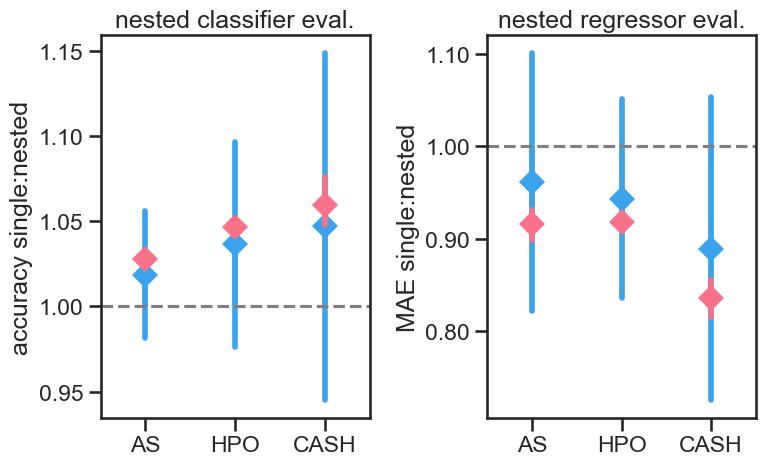

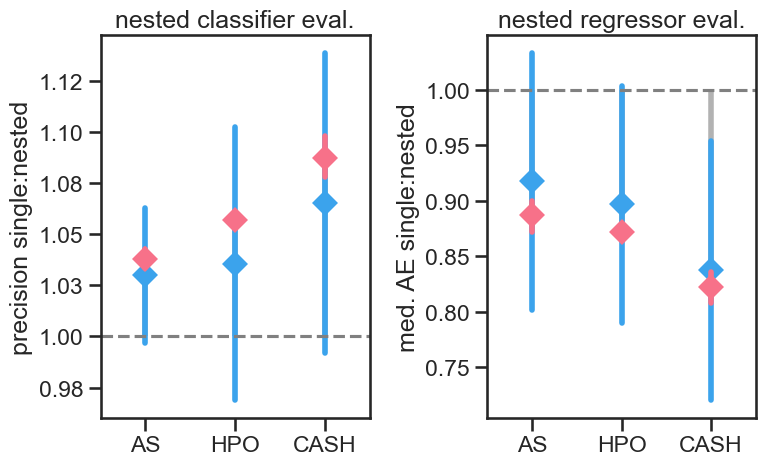

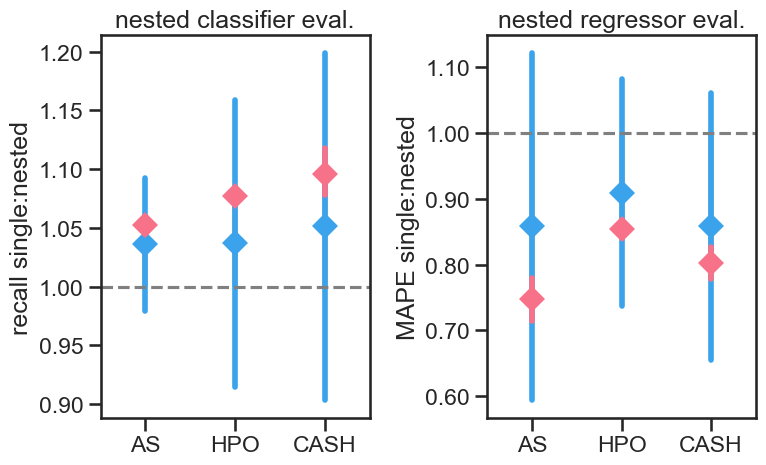

In [32]:
fig,ax=plt.subplots(1,2,figsize=(4*2,5))

holder=[]
metrics=scores_to_analyze_dict[list_class_problems[0]]
for file_name in list_class_problems:
  df=in_agg_out_splits_merge_dict[file_name]; df2=out_agg_dict[file_name]; df2=df2[df2['fold']=='test']
  df_as = (df2[df2['rank_as_mean_'+metrics[0]]==1].groupby(['iteration', 'outer_k',],sort=False)['mean_'+metrics[0]].mean() / df[df['rank_as_mean_'+metrics[0]]==1].groupby(['iteration', 'outer_k'],sort=False)['outer_'+metrics[0]].mean()).reset_index().rename(columns={0:'ratio_'+metrics[0]})
  df_hpo = (df2[df2['rank_hpo_mean_'+metrics[0]]==1].groupby(['iteration', 'outer_k','algorithm'],sort=False)['mean_'+metrics[0]].mean() / df[df['rank_hpo_mean_'+metrics[0]]==1].groupby(['iteration', 'outer_k','algorithm'],sort=False)['outer_'+metrics[0]].mean()).reset_index().rename(columns={0:'ratio_'+metrics[0]})
  df_cash = (df2[df2['rank_cash_mean_'+metrics[0]]==1].groupby(['iteration', 'outer_k',],sort=False)['mean_'+metrics[0]].mean() / df[df['rank_cash_mean_'+metrics[0]]==1].groupby(['iteration', 'outer_k'],sort=False)['outer_'+metrics[0]].mean()).reset_index().rename(columns={0:'ratio_'+metrics[0]})
  df_compiled = pd.concat([df_as,df_hpo,df_cash],keys=['AS','HPO','CASH']).reset_index().rename(columns={'level_0':'approach'}).drop(columns='level_1')
  holder.append(df_compiled)
data_to_plot=pd.concat(holder,keys=list_class_problems).reset_index()

# for row in data_to_plot.groupby('approach',sort=False)['mean_'+metrics[0]].median().reset_index().iterrows():
#   ax[0].vlines(x=row[1][0],ymin=1,ymax=row[1][1],color='grey',linewidth=4,alpha=0.3)
for row in data_to_plot.groupby('approach',sort=False)['ratio_'+metrics[0]].mean().reset_index().iterrows():
  ax[0].vlines(x=row[1][0],ymin=1,ymax=row[1][1],color='grey',linewidth=4,alpha=0.6)
sns.pointplot(x='approach',y='ratio_'+metrics[0],data=data_to_plot,errorbar='sd',join=False,markers='D',ax=ax[0],estimator=np.median,color=sns.color_palette("husl")[4])
sns.pointplot(x='approach',y='ratio_'+metrics[0],data=data_to_plot,errorbar='ci',join=False,markers='D',ax=ax[0])

holder=[]
metrics=scores_to_analyze_dict[list_reg_problems[0]]
for file_name in list_reg_problems:
  df=in_agg_out_splits_merge_dict[file_name]; df2=out_agg_dict[file_name]; df2=df2[df2['fold']=='test']
  df_as = (df2[df2['rank_as_mean_'+metrics[0]]==1].groupby(['iteration', 'outer_k',],sort=False)['mean_'+metrics[0]].mean() / df[df['rank_as_mean_'+metrics[0]]==1].groupby(['iteration', 'outer_k'],sort=False)['outer_'+metrics[0]].mean()).reset_index().rename(columns={0:'ratio_'+metrics[0]})
  df_hpo = (df2[df2['rank_hpo_mean_'+metrics[0]]==1].groupby(['iteration', 'outer_k','algorithm'],sort=False)['mean_'+metrics[0]].mean() / df[df['rank_hpo_mean_'+metrics[0]]==1].groupby(['iteration', 'outer_k','algorithm'],sort=False)['outer_'+metrics[0]].mean()).reset_index().rename(columns={0:'ratio_'+metrics[0]})
  df_cash = (df2[df2['rank_cash_mean_'+metrics[0]]==1].groupby(['iteration', 'outer_k',],sort=False)['mean_'+metrics[0]].mean() / df[df['rank_cash_mean_'+metrics[0]]==1].groupby(['iteration', 'outer_k'],sort=False)['outer_'+metrics[0]].mean()).reset_index().rename(columns={0:'ratio_'+metrics[0]})
  df_compiled = pd.concat([df_as,df_hpo,df_cash],keys=['AS','HPO','CASH']).reset_index().rename(columns={'level_0':'approach'}).drop(columns='level_1')
  holder.append(df_compiled)
data_to_plot=pd.concat(holder,keys=list_reg_problems).reset_index()

# for row in data_to_plot.groupby('approach',sort=False)['mean_'+metrics[0]].median().reset_index().iterrows():
#   ax[1].vlines(x=row[1][0],ymax=1,ymin=row[1][1],color='grey',linewidth=4,alpha=0.3)
for row in data_to_plot.groupby('approach',sort=False)['ratio_'+metrics[0]].mean().reset_index().iterrows():
  ax[1].vlines(x=row[1][0],ymax=1,ymin=row[1][1],color='grey',linewidth=4,alpha=0.6)
sns.pointplot(x='approach',y='ratio_'+metrics[0],data=data_to_plot,errorbar='sd',join=False,markers='D',ax=ax[1],estimator=np.median,color=sns.color_palette("husl")[4])
sns.pointplot(x='approach',y='ratio_'+metrics[0],data=data_to_plot,errorbar='ci',join=False,markers='D',ax=ax[1])

ax[0].set_ylabel('accuracy single:nested'); ax[0].set_title('nested classifier eval.'); 
ax[1].set_ylabel('MAE single:nested'); ax[1].set_title('nested regressor eval.'); 

for ax in plt.gcf().axes:
  ax.set_xlabel(''); ax.axhline(1,color='grey',linestyle='--'); ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))

fig.tight_layout()


fig,ax=plt.subplots(1,2,figsize=(4*2,5))

holder=[]
metrics=scores_to_analyze_dict[list_class_problems[0]]
for file_name in list_class_problems:
  df=in_agg_out_splits_merge_dict[file_name]; df2=out_agg_dict[file_name]; df2=df2[df2['fold']=='test']
  df_as = (df2[df2['rank_as_mean_'+metrics[1]]==1].groupby(['iteration', 'outer_k',],sort=False)['mean_'+metrics[1]].mean() / df[df['rank_as_mean_'+metrics[1]]==1].groupby(['iteration', 'outer_k'],sort=False)['outer_'+metrics[1]].mean()).reset_index().rename(columns={0:'ratio_'+metrics[1]})
  df_hpo = (df2[df2['rank_hpo_mean_'+metrics[1]]==1].groupby(['iteration', 'outer_k','algorithm'],sort=False)['mean_'+metrics[1]].mean() / df[df['rank_hpo_mean_'+metrics[1]]==1].groupby(['iteration', 'outer_k','algorithm'],sort=False)['outer_'+metrics[1]].mean()).reset_index().rename(columns={0:'ratio_'+metrics[1]})
  df_cash = (df2[df2['rank_cash_mean_'+metrics[1]]==1].groupby(['iteration', 'outer_k',],sort=False)['mean_'+metrics[1]].mean() / df[df['rank_cash_mean_'+metrics[1]]==1].groupby(['iteration', 'outer_k'],sort=False)['outer_'+metrics[1]].mean()).reset_index().rename(columns={0:'ratio_'+metrics[1]})
  df_compiled = pd.concat([df_as,df_hpo,df_cash],keys=['AS','HPO','CASH']).reset_index().rename(columns={'level_0':'approach'}).drop(columns='level_1')
  holder.append(df_compiled)
data_to_plot=pd.concat(holder,keys=list_class_problems).reset_index()

# for row in data_to_plot.groupby('approach',sort=False)['mean_'+metrics[1]].median().reset_index().iterrows():
#   ax[0].vlines(x=row[1][0],ymin=1,ymax=row[1][1],color='grey',linewidth=4,alpha=0.3)
for row in data_to_plot.groupby('approach',sort=False)['ratio_'+metrics[1]].mean().reset_index().iterrows():
  ax[0].vlines(x=row[1][0],ymin=1,ymax=row[1][1],color='grey',linewidth=4,alpha=0.6)
sns.pointplot(x='approach',y='ratio_'+metrics[1],data=data_to_plot,errorbar='sd',join=False,markers='D',ax=ax[0],estimator=np.median,color=sns.color_palette("husl")[4])
sns.pointplot(x='approach',y='ratio_'+metrics[1],data=data_to_plot,errorbar='ci',join=False,markers='D',ax=ax[0])

holder=[]
metrics=scores_to_analyze_dict[list_reg_problems[0]]
for file_name in list_reg_problems:
  df=in_agg_out_splits_merge_dict[file_name]; df2=out_agg_dict[file_name]; df2=df2[df2['fold']=='test']
  df_as = (df2[df2['rank_as_mean_'+metrics[1]]==1].groupby(['iteration', 'outer_k',],sort=False)['mean_'+metrics[1]].mean() / df[df['rank_as_mean_'+metrics[1]]==1].groupby(['iteration', 'outer_k'],sort=False)['outer_'+metrics[1]].mean()).reset_index().rename(columns={0:'ratio_'+metrics[1]})
  df_hpo = (df2[df2['rank_hpo_mean_'+metrics[1]]==1].groupby(['iteration', 'outer_k','algorithm'],sort=False)['mean_'+metrics[1]].mean() / df[df['rank_hpo_mean_'+metrics[1]]==1].groupby(['iteration', 'outer_k','algorithm'],sort=False)['outer_'+metrics[1]].mean()).reset_index().rename(columns={0:'ratio_'+metrics[1]})
  df_cash = (df2[df2['rank_cash_mean_'+metrics[1]]==1].groupby(['iteration', 'outer_k',],sort=False)['mean_'+metrics[1]].mean() / df[df['rank_cash_mean_'+metrics[1]]==1].groupby(['iteration', 'outer_k'],sort=False)['outer_'+metrics[1]].mean()).reset_index().rename(columns={0:'ratio_'+metrics[1]})
  df_compiled = pd.concat([df_as,df_hpo,df_cash],keys=['AS','HPO','CASH']).reset_index().rename(columns={'level_0':'approach'}).drop(columns='level_1')
  holder.append(df_compiled)
data_to_plot=pd.concat(holder,keys=list_reg_problems).reset_index()

# for row in data_to_plot.groupby('approach',sort=False)['mean_'+metrics[1]].median().reset_index().iterrows():
#   ax[1].vlines(x=row[1][0],ymax=1,ymin=row[1][1],color='grey',linewidth=4,alpha=0.3)
for row in data_to_plot.groupby('approach',sort=False)['ratio_'+metrics[1]].mean().reset_index().iterrows():
  ax[1].vlines(x=row[1][0],ymax=1,ymin=row[1][1],color='grey',linewidth=4,alpha=0.6)
sns.pointplot(x='approach',y='ratio_'+metrics[1],data=data_to_plot,errorbar='sd',join=False,markers='D',ax=ax[1],estimator=np.median,color=sns.color_palette("husl")[4])
sns.pointplot(x='approach',y='ratio_'+metrics[1],data=data_to_plot,errorbar='ci',join=False,markers='D',ax=ax[1])

ax[0].set_ylabel('precision single:nested'); ax[0].set_title('nested classifier eval.'); 
ax[1].set_ylabel('med. AE single:nested'); ax[1].set_title('nested regressor eval.'); 

for ax in plt.gcf().axes:
  ax.set_xlabel(''); ax.axhline(1,color='grey',linestyle='--'); ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))

fig.tight_layout()


fig,ax=plt.subplots(1,2,figsize=(4*2,5))

holder=[]
metrics=scores_to_analyze_dict[list_class_problems[0]]
for file_name in list_class_problems:
  df=in_agg_out_splits_merge_dict[file_name]; df2=out_agg_dict[file_name]; df2=df2[df2['fold']=='test']
  df_as = (df2[df2['rank_as_mean_'+metrics[2]]==1].groupby(['iteration', 'outer_k',],sort=False)['mean_'+metrics[2]].mean() / df[df['rank_as_mean_'+metrics[2]]==1].groupby(['iteration', 'outer_k'],sort=False)['outer_'+metrics[2]].mean()).reset_index().rename(columns={0:'ratio_'+metrics[2]})
  df_hpo = (df2[df2['rank_hpo_mean_'+metrics[2]]==1].groupby(['iteration', 'outer_k','algorithm'],sort=False)['mean_'+metrics[2]].mean() / df[df['rank_hpo_mean_'+metrics[2]]==1].groupby(['iteration', 'outer_k','algorithm'],sort=False)['outer_'+metrics[2]].mean()).reset_index().rename(columns={0:'ratio_'+metrics[2]})
  df_cash = (df2[df2['rank_cash_mean_'+metrics[2]]==1].groupby(['iteration', 'outer_k',],sort=False)['mean_'+metrics[2]].mean() / df[df['rank_cash_mean_'+metrics[2]]==1].groupby(['iteration', 'outer_k'],sort=False)['outer_'+metrics[2]].mean()).reset_index().rename(columns={0:'ratio_'+metrics[2]})
  df_compiled = pd.concat([df_as,df_hpo,df_cash],keys=['AS','HPO','CASH']).reset_index().rename(columns={'level_0':'approach'}).drop(columns='level_1')
  holder.append(df_compiled)
data_to_plot=pd.concat(holder,keys=list_class_problems).reset_index()

# for row in data_to_plot.groupby('approach',sort=False)['mean_'+metrics[2]].median().reset_index().iterrows():
#   ax[0].vlines(x=row[1][0],ymin=1,ymax=row[1][1],color='grey',linewidth=4,alpha=0.3)
for row in data_to_plot.groupby('approach',sort=False)['ratio_'+metrics[2]].mean().reset_index().iterrows():
  ax[0].vlines(x=row[1][0],ymin=1,ymax=row[1][1],color='grey',linewidth=4,alpha=0.6)
sns.pointplot(x='approach',y='ratio_'+metrics[2],data=data_to_plot,errorbar='sd',join=False,markers='D',ax=ax[0],estimator=np.median,color=sns.color_palette("husl")[4])
sns.pointplot(x='approach',y='ratio_'+metrics[2],data=data_to_plot,errorbar='ci',join=False,markers='D',ax=ax[0])

holder=[]
metrics=scores_to_analyze_dict[list_reg_problems[0]]
for file_name in list_reg_problems:
  df=in_agg_out_splits_merge_dict[file_name]; df2=out_agg_dict[file_name]; df2=df2[df2['fold']=='test']
  df_as = (df2[df2['rank_as_mean_'+metrics[2]]==1].groupby(['iteration', 'outer_k',],sort=False)['mean_'+metrics[2]].mean() / df[df['rank_as_mean_'+metrics[2]]==1].groupby(['iteration', 'outer_k'],sort=False)['outer_'+metrics[2]].mean()).reset_index().rename(columns={0:'ratio_'+metrics[2]})
  df_hpo = (df2[df2['rank_hpo_mean_'+metrics[2]]==1].groupby(['iteration', 'outer_k','algorithm'],sort=False)['mean_'+metrics[2]].mean() / df[df['rank_hpo_mean_'+metrics[2]]==1].groupby(['iteration', 'outer_k','algorithm'],sort=False)['outer_'+metrics[2]].mean()).reset_index().rename(columns={0:'ratio_'+metrics[2]})
  df_cash = (df2[df2['rank_cash_mean_'+metrics[2]]==1].groupby(['iteration', 'outer_k',],sort=False)['mean_'+metrics[2]].mean() / df[df['rank_cash_mean_'+metrics[2]]==1].groupby(['iteration', 'outer_k'],sort=False)['outer_'+metrics[2]].mean()).reset_index().rename(columns={0:'ratio_'+metrics[2]})
  df_compiled = pd.concat([df_as,df_hpo,df_cash],keys=['AS','HPO','CASH']).reset_index().rename(columns={'level_0':'approach'}).drop(columns='level_1')
  holder.append(df_compiled)
data_to_plot=pd.concat(holder,keys=list_reg_problems).reset_index()

# for row in data_to_plot.groupby('approach',sort=False)['mean_'+metrics[2]].median().reset_index().iterrows():
#   ax[1].vlines(x=row[1][0],ymax=1,ymin=row[1][1],color='grey',linewidth=4,alpha=0.3)
for row in data_to_plot.groupby('approach',sort=False)['ratio_'+metrics[2]].mean().reset_index().iterrows():
  ax[1].vlines(x=row[1][0],ymax=1,ymin=row[1][1],color='grey',linewidth=4,alpha=0.6)
sns.pointplot(x='approach',y='ratio_'+metrics[2],data=data_to_plot,errorbar='sd',join=False,markers='D',ax=ax[1],estimator=np.median,color=sns.color_palette("husl")[4])
sns.pointplot(x='approach',y='ratio_'+metrics[2],data=data_to_plot,errorbar='ci',join=False,markers='D',ax=ax[1])

ax[0].set_ylabel('recall single:nested'); ax[0].set_title('nested classifier eval.'); 
ax[1].set_ylabel('MAPE single:nested'); ax[1].set_title('nested regressor eval.'); 

for ax in plt.gcf().axes:
  ax.set_xlabel(''); ax.axhline(1,color='grey',linestyle='--'); ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))

fig.tight_layout()

C:\Users\conno\AppData\Local\Temp\ipykernel_2100\925484365.py:14: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(x='approach',y='ratio_'+metrics[0],data=data_to_plot,errorbar='ci',join=False,markers='D',ax=ax[0],hue='level_0')
C:\Users\conno\AppData\Local\Temp\ipykernel_2100\925484365.py:27: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(x='approach',y='ratio_'+metrics[0],data=data_to_plot,errorbar='ci',join=False,markers='D',ax=ax[1],hue='level_0')
C:\Users\conno\AppData\Local\Temp\ipykernel_2100\925484365.py:50: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(x='approach',y='ratio_'+metrics[1],data=data_to_plot,errorbar='ci',join=False,markers

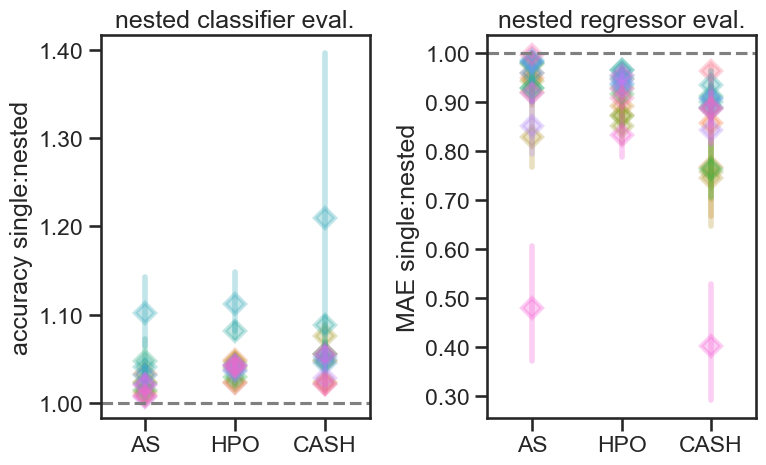

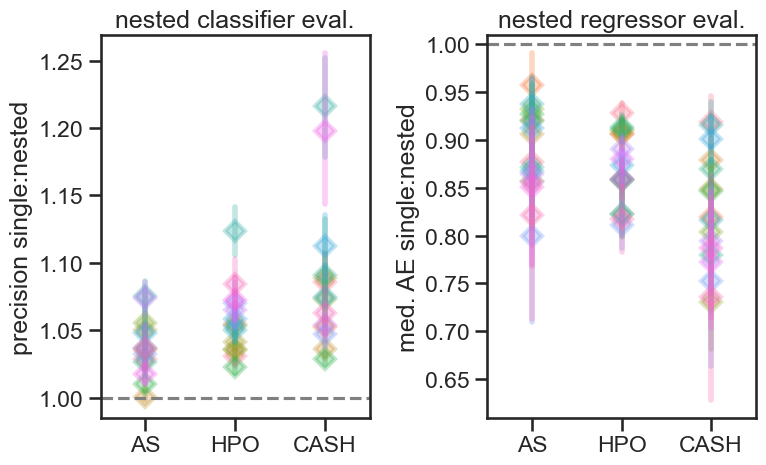

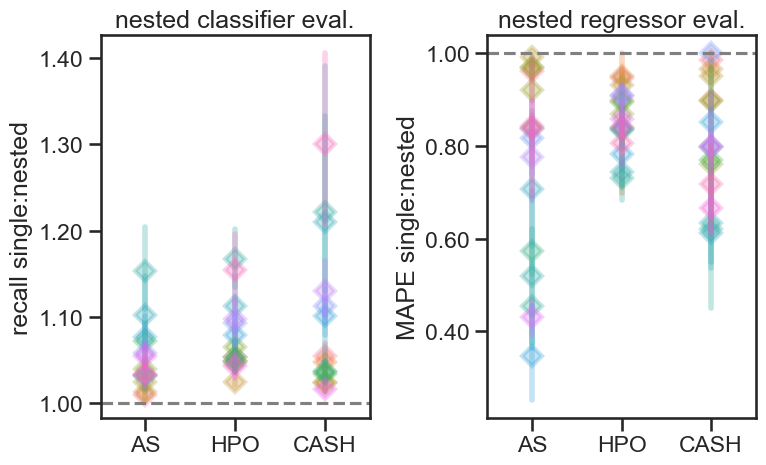

In [33]:
fig,ax=plt.subplots(1,2,figsize=(4*2,5))

holder=[]
metrics=scores_to_analyze_dict[list_class_problems[0]]
for file_name in list_class_problems:
  df=in_agg_out_splits_merge_dict[file_name]; df2=out_agg_dict[file_name]; df2=df2[df2['fold']=='test']
  df_as = (df2[df2['rank_as_mean_'+metrics[0]]==1].groupby(['iteration', 'outer_k',],sort=False)['mean_'+metrics[0]].mean() / df[df['rank_as_mean_'+metrics[0]]==1].groupby(['iteration', 'outer_k'],sort=False)['outer_'+metrics[0]].mean()).reset_index().rename(columns={0:'ratio_'+metrics[0]})
  df_hpo = (df2[df2['rank_hpo_mean_'+metrics[0]]==1].groupby(['iteration', 'outer_k','algorithm'],sort=False)['mean_'+metrics[0]].mean() / df[df['rank_hpo_mean_'+metrics[0]]==1].groupby(['iteration', 'outer_k','algorithm'],sort=False)['outer_'+metrics[0]].mean()).reset_index().rename(columns={0:'ratio_'+metrics[0]})
  df_cash = (df2[df2['rank_cash_mean_'+metrics[0]]==1].groupby(['iteration', 'outer_k',],sort=False)['mean_'+metrics[0]].mean() / df[df['rank_cash_mean_'+metrics[0]]==1].groupby(['iteration', 'outer_k'],sort=False)['outer_'+metrics[0]].mean()).reset_index().rename(columns={0:'ratio_'+metrics[0]})
  df_compiled = pd.concat([df_as,df_hpo,df_cash],keys=['AS','HPO','CASH']).reset_index().rename(columns={'level_0':'approach'}).drop(columns='level_1')
  holder.append(df_compiled)
data_to_plot=pd.concat(holder,keys=list_class_problems).reset_index()

sns.pointplot(x='approach',y='ratio_'+metrics[0],data=data_to_plot,errorbar='ci',join=False,markers='D',ax=ax[0],hue='level_0')

holder=[]
metrics=scores_to_analyze_dict[list_reg_problems[0]]
for file_name in list_reg_problems:
  df=in_agg_out_splits_merge_dict[file_name]; df2=out_agg_dict[file_name]; df2=df2[df2['fold']=='test']
  df_as = (df2[df2['rank_as_mean_'+metrics[0]]==1].groupby(['iteration', 'outer_k',],sort=False)['mean_'+metrics[0]].mean() / df[df['rank_as_mean_'+metrics[0]]==1].groupby(['iteration', 'outer_k'],sort=False)['outer_'+metrics[0]].mean()).reset_index().rename(columns={0:'ratio_'+metrics[0]})
  df_hpo = (df2[df2['rank_hpo_mean_'+metrics[0]]==1].groupby(['iteration', 'outer_k','algorithm'],sort=False)['mean_'+metrics[0]].mean() / df[df['rank_hpo_mean_'+metrics[0]]==1].groupby(['iteration', 'outer_k','algorithm'],sort=False)['outer_'+metrics[0]].mean()).reset_index().rename(columns={0:'ratio_'+metrics[0]})
  df_cash = (df2[df2['rank_cash_mean_'+metrics[0]]==1].groupby(['iteration', 'outer_k',],sort=False)['mean_'+metrics[0]].mean() / df[df['rank_cash_mean_'+metrics[0]]==1].groupby(['iteration', 'outer_k'],sort=False)['outer_'+metrics[0]].mean()).reset_index().rename(columns={0:'ratio_'+metrics[0]})
  df_compiled = pd.concat([df_as,df_hpo,df_cash],keys=['AS','HPO','CASH']).reset_index().rename(columns={'level_0':'approach'}).drop(columns='level_1')
  holder.append(df_compiled)
data_to_plot=pd.concat(holder,keys=list_reg_problems).reset_index()

sns.pointplot(x='approach',y='ratio_'+metrics[0],data=data_to_plot,errorbar='ci',join=False,markers='D',ax=ax[1],hue='level_0')

ax[0].set_ylabel('accuracy single:nested'); ax[0].set_title('nested classifier eval.'); 
ax[1].set_ylabel('MAE single:nested'); ax[1].set_title('nested regressor eval.'); 

for ax in plt.gcf().axes:
  ax.set_xlabel(''); plt.setp(ax.collections, alpha=.3); plt.setp(ax.lines, alpha=.3); ax.axhline(1,color='grey',linestyle='--'); ax.get_legend().remove(); ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))

fig.tight_layout()

fig,ax=plt.subplots(1,2,figsize=(4*2,5))

holder=[]
metrics=scores_to_analyze_dict[list_class_problems[0]]
for file_name in list_class_problems:
  df=in_agg_out_splits_merge_dict[file_name]; df2=out_agg_dict[file_name]; df2=df2[df2['fold']=='test']
  df_as = (df2[df2['rank_as_mean_'+metrics[1]]==1].groupby(['iteration', 'outer_k',],sort=False)['mean_'+metrics[1]].mean() / df[df['rank_as_mean_'+metrics[1]]==1].groupby(['iteration', 'outer_k'],sort=False)['outer_'+metrics[1]].mean()).reset_index().rename(columns={0:'ratio_'+metrics[1]})
  df_hpo = (df2[df2['rank_hpo_mean_'+metrics[1]]==1].groupby(['iteration', 'outer_k','algorithm'],sort=False)['mean_'+metrics[1]].mean() / df[df['rank_hpo_mean_'+metrics[1]]==1].groupby(['iteration', 'outer_k','algorithm'],sort=False)['outer_'+metrics[1]].mean()).reset_index().rename(columns={0:'ratio_'+metrics[1]})
  df_cash = (df2[df2['rank_cash_mean_'+metrics[1]]==1].groupby(['iteration', 'outer_k',],sort=False)['mean_'+metrics[1]].mean() / df[df['rank_cash_mean_'+metrics[1]]==1].groupby(['iteration', 'outer_k'],sort=False)['outer_'+metrics[1]].mean()).reset_index().rename(columns={0:'ratio_'+metrics[1]})
  df_compiled = pd.concat([df_as,df_hpo,df_cash],keys=['AS','HPO','CASH']).reset_index().rename(columns={'level_0':'approach'}).drop(columns='level_1')
  holder.append(df_compiled)
data_to_plot=pd.concat(holder,keys=list_class_problems).reset_index()

sns.pointplot(x='approach',y='ratio_'+metrics[1],data=data_to_plot,errorbar='ci',join=False,markers='D',ax=ax[0],hue='level_0')

holder=[]
metrics=scores_to_analyze_dict[list_reg_problems[0]]
for file_name in list_reg_problems:
  df=in_agg_out_splits_merge_dict[file_name]; df2=out_agg_dict[file_name]; df2=df2[df2['fold']=='test']
  df_as = (df2[df2['rank_as_mean_'+metrics[1]]==1].groupby(['iteration', 'outer_k',],sort=False)['mean_'+metrics[1]].mean() / df[df['rank_as_mean_'+metrics[1]]==1].groupby(['iteration', 'outer_k'],sort=False)['outer_'+metrics[1]].mean()).reset_index().rename(columns={0:'ratio_'+metrics[1]})
  df_hpo = (df2[df2['rank_hpo_mean_'+metrics[1]]==1].groupby(['iteration', 'outer_k','algorithm'],sort=False)['mean_'+metrics[1]].mean() / df[df['rank_hpo_mean_'+metrics[1]]==1].groupby(['iteration', 'outer_k','algorithm'],sort=False)['outer_'+metrics[1]].mean()).reset_index().rename(columns={0:'ratio_'+metrics[1]})
  df_cash = (df2[df2['rank_cash_mean_'+metrics[1]]==1].groupby(['iteration', 'outer_k',],sort=False)['mean_'+metrics[1]].mean() / df[df['rank_cash_mean_'+metrics[1]]==1].groupby(['iteration', 'outer_k'],sort=False)['outer_'+metrics[1]].mean()).reset_index().rename(columns={0:'ratio_'+metrics[1]})
  df_compiled = pd.concat([df_as,df_hpo,df_cash],keys=['AS','HPO','CASH']).reset_index().rename(columns={'level_0':'approach'}).drop(columns='level_1')
  holder.append(df_compiled)
data_to_plot=pd.concat(holder,keys=list_reg_problems).reset_index()

sns.pointplot(x='approach',y='ratio_'+metrics[1],data=data_to_plot,errorbar='ci',join=False,markers='D',ax=ax[1],hue='level_0')

ax[0].set_ylabel('precision single:nested'); ax[0].set_title('nested classifier eval.'); 
ax[1].set_ylabel('med. AE single:nested'); ax[1].set_title('nested regressor eval.'); 

for ax in plt.gcf().axes:
  ax.set_xlabel(''); plt.setp(ax.collections, alpha=.3); plt.setp(ax.lines, alpha=.3); ax.axhline(1,color='grey',linestyle='--'); ax.get_legend().remove(); ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))

fig.tight_layout()

fig,ax=plt.subplots(1,2,figsize=(4*2,5))

holder=[]
metrics=scores_to_analyze_dict[list_class_problems[0]]
for file_name in list_class_problems:
  df=in_agg_out_splits_merge_dict[file_name]; df2=out_agg_dict[file_name]; df2=df2[df2['fold']=='test']
  df_as = (df2[df2['rank_as_mean_'+metrics[2]]==1].groupby(['iteration', 'outer_k',],sort=False)['mean_'+metrics[2]].mean() / df[df['rank_as_mean_'+metrics[2]]==1].groupby(['iteration', 'outer_k'],sort=False)['outer_'+metrics[2]].mean()).reset_index().rename(columns={0:'ratio_'+metrics[2]})
  df_hpo = (df2[df2['rank_hpo_mean_'+metrics[2]]==1].groupby(['iteration', 'outer_k','algorithm'],sort=False)['mean_'+metrics[2]].mean() / df[df['rank_hpo_mean_'+metrics[2]]==1].groupby(['iteration', 'outer_k','algorithm'],sort=False)['outer_'+metrics[2]].mean()).reset_index().rename(columns={0:'ratio_'+metrics[2]})
  df_cash = (df2[df2['rank_cash_mean_'+metrics[2]]==1].groupby(['iteration', 'outer_k',],sort=False)['mean_'+metrics[2]].mean() / df[df['rank_cash_mean_'+metrics[2]]==1].groupby(['iteration', 'outer_k'],sort=False)['outer_'+metrics[2]].mean()).reset_index().rename(columns={0:'ratio_'+metrics[2]})
  df_compiled = pd.concat([df_as,df_hpo,df_cash],keys=['AS','HPO','CASH']).reset_index().rename(columns={'level_0':'approach'}).drop(columns='level_1')
  holder.append(df_compiled)
data_to_plot=pd.concat(holder,keys=list_class_problems).reset_index()

sns.pointplot(x='approach',y='ratio_'+metrics[2],data=data_to_plot,errorbar='ci',join=False,markers='D',ax=ax[0],hue='level_0')

holder=[]
metrics=scores_to_analyze_dict[list_reg_problems[0]]
for file_name in list_reg_problems:
  df=in_agg_out_splits_merge_dict[file_name]; df2=out_agg_dict[file_name]; df2=df2[df2['fold']=='test']
  df_as = (df2[df2['rank_as_mean_'+metrics[2]]==1].groupby(['iteration', 'outer_k',],sort=False)['mean_'+metrics[2]].mean() / df[df['rank_as_mean_'+metrics[2]]==1].groupby(['iteration', 'outer_k'],sort=False)['outer_'+metrics[2]].mean()).reset_index().rename(columns={0:'ratio_'+metrics[2]})
  df_hpo = (df2[df2['rank_hpo_mean_'+metrics[2]]==1].groupby(['iteration', 'outer_k','algorithm'],sort=False)['mean_'+metrics[2]].mean() / df[df['rank_hpo_mean_'+metrics[2]]==1].groupby(['iteration', 'outer_k','algorithm'],sort=False)['outer_'+metrics[2]].mean()).reset_index().rename(columns={0:'ratio_'+metrics[2]})
  df_cash = (df2[df2['rank_cash_mean_'+metrics[2]]==1].groupby(['iteration', 'outer_k',],sort=False)['mean_'+metrics[2]].mean() / df[df['rank_cash_mean_'+metrics[2]]==1].groupby(['iteration', 'outer_k'],sort=False)['outer_'+metrics[2]].mean()).reset_index().rename(columns={0:'ratio_'+metrics[2]})
  df_compiled = pd.concat([df_as,df_hpo,df_cash],keys=['AS','HPO','CASH']).reset_index().rename(columns={'level_0':'approach'}).drop(columns='level_1')
  holder.append(df_compiled)
data_to_plot=pd.concat(holder,keys=list_reg_problems).reset_index()

sns.pointplot(x='approach',y='ratio_'+metrics[2],data=data_to_plot,errorbar='ci',join=False,markers='D',ax=ax[1],hue='level_0')

ax[0].set_ylabel('recall single:nested'); ax[0].set_title('nested classifier eval.'); 
ax[1].set_ylabel('MAPE single:nested'); ax[1].set_title('nested regressor eval.'); 

for ax in plt.gcf().axes:
  ax.set_xlabel(''); plt.setp(ax.collections, alpha=.3); plt.setp(ax.lines, alpha=.3); ax.axhline(1,color='grey',linestyle='--'); ax.get_legend().remove(); ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))

fig.tight_layout()

C:\Users\conno\AppData\Local\Temp\ipykernel_2100\2894035265.py:16: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0.

  sns.pointplot(x='approach',y='outer_'+metrics[0],data=data_to_plot,errorbar='sd',join=True,markers='D',ax=ax[0],estimator=np.median,color=sns.color_palette("husl")[4])
C:\Users\conno\AppData\Local\Temp\ipykernel_2100\2894035265.py:17: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0.

  sns.pointplot(x='approach',y='outer_'+metrics[0],data=data_to_plot,errorbar='ci',join=True,markers='D',ax=ax[0])
C:\Users\conno\AppData\Local\Temp\ipykernel_2100\2894035265.py:32: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0.

  sns.pointplot(x='approach',y='outer_'+metrics[0],data=data_to_plot,errorbar='sd',join=True,markers='D',ax=ax[1],estimator=np.median,color=sns.color_palette("husl")[4])
C:\Users\conno\AppData\Local\Temp\ipykernel_2100\2894035265.py:33: UserWarning: 

The `join` pa

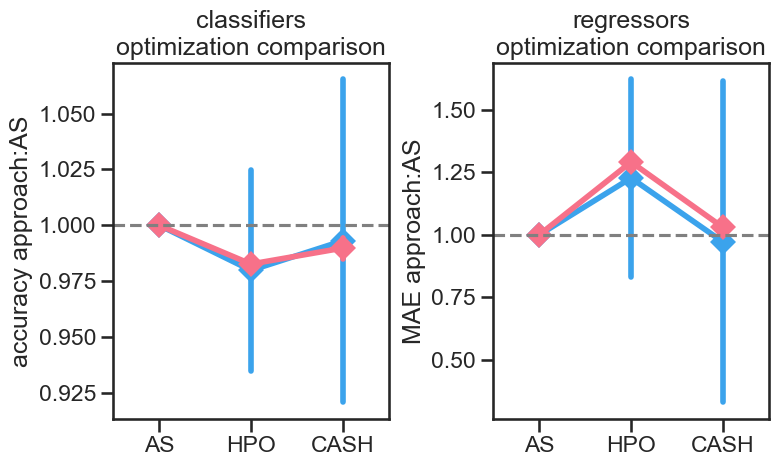

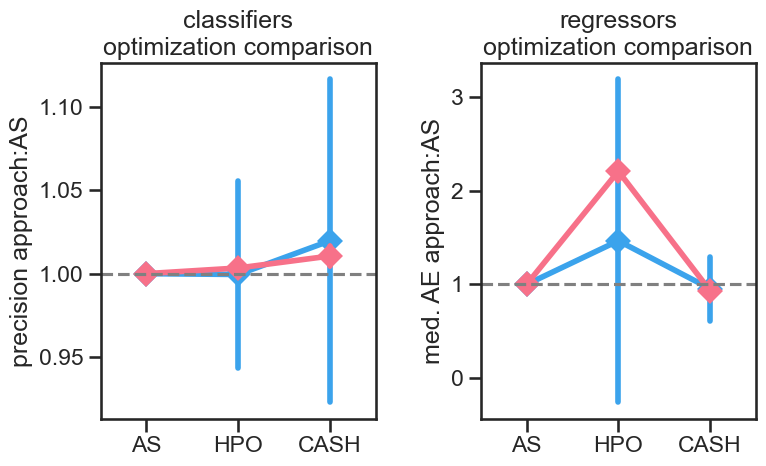

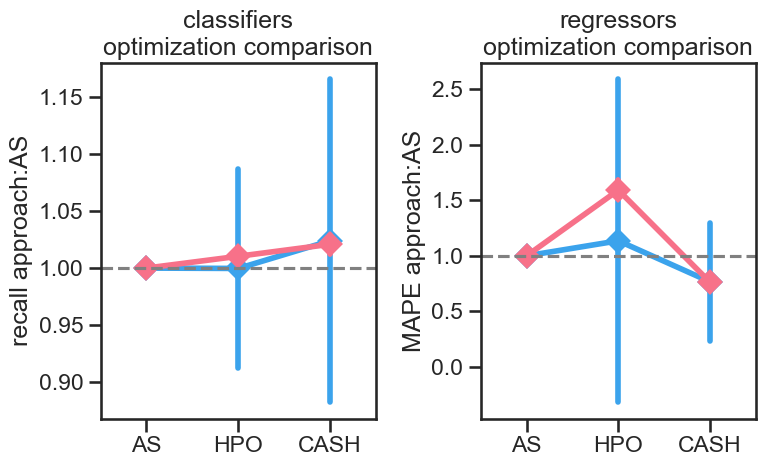

In [34]:
fig,ax=plt.subplots(1,2,figsize=(4*2,5))

holder=[]
metrics=scores_to_analyze_dict[list_class_problems[0]]
for file_name in list_class_problems:
  df=in_agg_out_splits_merge_dict[file_name];
  df_as = (df[df['rank_as_mean_'+metrics[0]]==1].groupby(['iteration', 'outer_k','inner_k'],sort=False)['outer_'+metrics[0]].mean() / df[df['rank_as_mean_'+metrics[0]]==1].groupby(['iteration', 'outer_k','inner_k'],sort=False)['outer_'+metrics[0]].mean()).reset_index()
  df_hpo = (df[df['rank_hpo_mean_'+metrics[0]]==1].groupby(['iteration', 'outer_k','inner_k'],sort=False)['outer_'+metrics[0]].mean() / df[df['rank_as_mean_'+metrics[0]]==1].groupby(['iteration', 'outer_k','inner_k'],sort=False)['outer_'+metrics[0]].mean()).reset_index()
  df_cash = (df[df['rank_cash_mean_'+metrics[0]]==1].groupby(['iteration', 'outer_k','inner_k'],sort=False)['outer_'+metrics[0]].mean() / df[df['rank_as_mean_'+metrics[0]]==1].groupby(['iteration', 'outer_k','inner_k'],sort=False)['outer_'+metrics[0]].mean()).reset_index()
  df_compiled = pd.concat([df_as,df_hpo,df_cash],keys=['AS','HPO','CASH']).reset_index().rename(columns={'level_0':'approach'}).drop(columns='level_1')
  holder.append(df_compiled)
data_to_plot=pd.concat(holder,keys=list_class_problems).reset_index()

# for row in data_to_plot.groupby('approach',sort=False)['outer_'+metrics[0]].mean().reset_index().iterrows():
#   ax[0].vlines(x=row[1][0],ymax=1,ymin=row[1][1],color='grey',linewidth=4,alpha=0.6)
sns.pointplot(x='approach',y='outer_'+metrics[0],data=data_to_plot,errorbar='sd',join=True,markers='D',ax=ax[0],estimator=np.median,color=sns.color_palette("husl")[4])
sns.pointplot(x='approach',y='outer_'+metrics[0],data=data_to_plot,errorbar='ci',join=True,markers='D',ax=ax[0])

holder=[]
metrics=scores_to_analyze_dict[list_reg_problems[0]]
for file_name in list_reg_problems:
  df=in_agg_out_splits_merge_dict[file_name]; 
  df_as = (df[df['rank_as_mean_'+metrics[0]]==1].groupby(['iteration', 'outer_k','inner_k'],sort=False)['outer_'+metrics[0]].mean() / df[df['rank_as_mean_'+metrics[0]]==1].groupby(['iteration', 'outer_k','inner_k'],sort=False)['outer_'+metrics[0]].mean()).reset_index()
  df_hpo = (df[df['rank_hpo_mean_'+metrics[0]]==1].groupby(['iteration', 'outer_k','inner_k'],sort=False)['outer_'+metrics[0]].mean() / df[df['rank_as_mean_'+metrics[0]]==1].groupby(['iteration', 'outer_k','inner_k'],sort=False)['outer_'+metrics[0]].mean()).reset_index()
  df_cash = (df[df['rank_cash_mean_'+metrics[0]]==1].groupby(['iteration', 'outer_k','inner_k'],sort=False)['outer_'+metrics[0]].mean() / df[df['rank_as_mean_'+metrics[0]]==1].groupby(['iteration', 'outer_k','inner_k'],sort=False)['outer_'+metrics[0]].mean()).reset_index()
  df_compiled = pd.concat([df_as,df_hpo,df_cash],keys=['AS','HPO','CASH']).reset_index().rename(columns={'level_0':'approach'}).drop(columns='level_1')
  holder.append(df_compiled)
data_to_plot=pd.concat(holder,keys=list_reg_problems).reset_index()

# for row in data_to_plot.groupby('approach',sort=False)['outer_'+metrics[0]].mean().reset_index().iterrows():
#   ax[1].vlines(x=row[1][0],ymin=1,ymax=row[1][1],color='grey',linewidth=4,alpha=0.6)
sns.pointplot(x='approach',y='outer_'+metrics[0],data=data_to_plot,errorbar='sd',join=True,markers='D',ax=ax[1],estimator=np.median,color=sns.color_palette("husl")[4])
sns.pointplot(x='approach',y='outer_'+metrics[0],data=data_to_plot,errorbar='ci',join=True,markers='D',ax=ax[1])

ax[0].set_ylabel('accuracy approach:AS'); ax[0].set_title('classifiers\noptimization comparison'); 
ax[1].set_ylabel('MAE approach:AS'); ax[1].set_title('regressors\noptimization comparison'); 

for ax in plt.gcf().axes:
  ax.set_xlabel(''); ax.axhline(1,color='grey',linestyle='--'); #ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))

fig.tight_layout()

fig,ax=plt.subplots(1,2,figsize=(4*2,5))

holder=[]
metrics=scores_to_analyze_dict[list_class_problems[0]]
for file_name in list_class_problems:
  df=in_agg_out_splits_merge_dict[file_name];
  df_as = (df[df['rank_as_mean_'+metrics[1]]==1].groupby(['iteration', 'outer_k','inner_k'],sort=False)['outer_'+metrics[1]].mean() / df[df['rank_as_mean_'+metrics[1]]==1].groupby(['iteration', 'outer_k','inner_k'],sort=False)['outer_'+metrics[1]].mean()).reset_index()
  df_hpo = (df[df['rank_hpo_mean_'+metrics[1]]==1].groupby(['iteration', 'outer_k','inner_k'],sort=False)['outer_'+metrics[1]].mean() / df[df['rank_as_mean_'+metrics[1]]==1].groupby(['iteration', 'outer_k','inner_k'],sort=False)['outer_'+metrics[1]].mean()).reset_index()
  df_cash = (df[df['rank_cash_mean_'+metrics[1]]==1].groupby(['iteration', 'outer_k','inner_k'],sort=False)['outer_'+metrics[1]].mean() / df[df['rank_as_mean_'+metrics[1]]==1].groupby(['iteration', 'outer_k','inner_k'],sort=False)['outer_'+metrics[1]].mean()).reset_index()
  df_compiled = pd.concat([df_as,df_hpo,df_cash],keys=['AS','HPO','CASH']).reset_index().rename(columns={'level_0':'approach'}).drop(columns='level_1')
  holder.append(df_compiled)
data_to_plot=pd.concat(holder,keys=list_class_problems).reset_index()

# for row in data_to_plot.groupby('approach',sort=False)['outer_'+metrics[1]].mean().reset_index().iterrows():
#   ax[0].vlines(x=row[1][0],ymax=1,ymin=row[1][1],color='grey',linewidth=4,alpha=0.6)
sns.pointplot(x='approach',y='outer_'+metrics[1],data=data_to_plot,errorbar='sd',join=True,markers='D',ax=ax[0],estimator=np.median,color=sns.color_palette("husl")[4])
sns.pointplot(x='approach',y='outer_'+metrics[1],data=data_to_plot,errorbar='ci',join=True,markers='D',ax=ax[0])

holder=[]
metrics=scores_to_analyze_dict[list_reg_problems[0]]
for file_name in list_reg_problems:
  df=in_agg_out_splits_merge_dict[file_name]; 
  df_as = (df[df['rank_as_mean_'+metrics[1]]==1].groupby(['iteration', 'outer_k','inner_k'],sort=False)['outer_'+metrics[1]].mean() / df[df['rank_as_mean_'+metrics[1]]==1].groupby(['iteration', 'outer_k','inner_k'],sort=False)['outer_'+metrics[1]].mean()).reset_index()
  df_hpo = (df[df['rank_hpo_mean_'+metrics[1]]==1].groupby(['iteration', 'outer_k','inner_k'],sort=False)['outer_'+metrics[1]].mean() / df[df['rank_as_mean_'+metrics[1]]==1].groupby(['iteration', 'outer_k','inner_k'],sort=False)['outer_'+metrics[1]].mean()).reset_index()
  df_cash = (df[df['rank_cash_mean_'+metrics[1]]==1].groupby(['iteration', 'outer_k','inner_k'],sort=False)['outer_'+metrics[1]].mean() / df[df['rank_as_mean_'+metrics[1]]==1].groupby(['iteration', 'outer_k','inner_k'],sort=False)['outer_'+metrics[1]].mean()).reset_index()
  df_compiled = pd.concat([df_as,df_hpo,df_cash],keys=['AS','HPO','CASH']).reset_index().rename(columns={'level_0':'approach'}).drop(columns='level_1')
  holder.append(df_compiled)
data_to_plot=pd.concat(holder,keys=list_reg_problems).reset_index()

# for row in data_to_plot.groupby('approach',sort=False)['outer_'+metrics[1]].mean().reset_index().iterrows():
#   ax[1].vlines(x=row[1][0],ymin=1,ymax=row[1][1],color='grey',linewidth=4,alpha=0.6)
sns.pointplot(x='approach',y='outer_'+metrics[1],data=data_to_plot,errorbar='sd',join=True,markers='D',ax=ax[1],estimator=np.median,color=sns.color_palette("husl")[4])
sns.pointplot(x='approach',y='outer_'+metrics[1],data=data_to_plot,errorbar='ci',join=True,markers='D',ax=ax[1])

ax[0].set_ylabel('precision approach:AS'); ax[0].set_title('classifiers\noptimization comparison'); 
ax[1].set_ylabel('med. AE approach:AS'); ax[1].set_title('regressors\noptimization comparison'); 

for ax in plt.gcf().axes:
  ax.set_xlabel(''); ax.axhline(1,color='grey',linestyle='--'); #ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))

fig.tight_layout()

fig,ax=plt.subplots(1,2,figsize=(4*2,5))

holder=[]
metrics=scores_to_analyze_dict[list_class_problems[0]]
for file_name in list_class_problems:
  df=in_agg_out_splits_merge_dict[file_name];
  df_as = (df[df['rank_as_mean_'+metrics[2]]==1].groupby(['iteration', 'outer_k','inner_k'],sort=False)['outer_'+metrics[2]].mean() / df[df['rank_as_mean_'+metrics[2]]==1].groupby(['iteration', 'outer_k','inner_k'],sort=False)['outer_'+metrics[2]].mean()).reset_index()
  df_hpo = (df[df['rank_hpo_mean_'+metrics[2]]==1].groupby(['iteration', 'outer_k','inner_k'],sort=False)['outer_'+metrics[2]].mean() / df[df['rank_as_mean_'+metrics[2]]==1].groupby(['iteration', 'outer_k','inner_k'],sort=False)['outer_'+metrics[2]].mean()).reset_index()
  df_cash = (df[df['rank_cash_mean_'+metrics[2]]==1].groupby(['iteration', 'outer_k','inner_k'],sort=False)['outer_'+metrics[2]].mean() / df[df['rank_as_mean_'+metrics[2]]==1].groupby(['iteration', 'outer_k','inner_k'],sort=False)['outer_'+metrics[2]].mean()).reset_index()
  df_compiled = pd.concat([df_as,df_hpo,df_cash],keys=['AS','HPO','CASH']).reset_index().rename(columns={'level_0':'approach'}).drop(columns='level_1')
  holder.append(df_compiled)
data_to_plot=pd.concat(holder,keys=list_class_problems).reset_index()

# for row in data_to_plot.groupby('approach',sort=False)['outer_'+metrics[2]].mean().reset_index().iterrows():
#   ax[0].vlines(x=row[1][0],ymax=1,ymin=row[1][1],color='grey',linewidth=4,alpha=0.6)
sns.pointplot(x='approach',y='outer_'+metrics[2],data=data_to_plot,errorbar='sd',join=True,markers='D',ax=ax[0],estimator=np.median,color=sns.color_palette("husl")[4])
sns.pointplot(x='approach',y='outer_'+metrics[2],data=data_to_plot,errorbar='ci',join=True,markers='D',ax=ax[0])

holder=[]
metrics=scores_to_analyze_dict[list_reg_problems[0]]
for file_name in list_reg_problems:
  df=in_agg_out_splits_merge_dict[file_name]; 
  df_as = (df[df['rank_as_mean_'+metrics[2]]==1].groupby(['iteration', 'outer_k','inner_k'],sort=False)['outer_'+metrics[2]].mean() / df[df['rank_as_mean_'+metrics[2]]==1].groupby(['iteration', 'outer_k','inner_k'],sort=False)['outer_'+metrics[2]].mean()).reset_index()
  df_hpo = (df[df['rank_hpo_mean_'+metrics[2]]==1].groupby(['iteration', 'outer_k','inner_k'],sort=False)['outer_'+metrics[2]].mean() / df[df['rank_as_mean_'+metrics[2]]==1].groupby(['iteration', 'outer_k','inner_k'],sort=False)['outer_'+metrics[2]].mean()).reset_index()
  df_cash = (df[df['rank_cash_mean_'+metrics[2]]==1].groupby(['iteration', 'outer_k','inner_k'],sort=False)['outer_'+metrics[2]].mean() / df[df['rank_as_mean_'+metrics[2]]==1].groupby(['iteration', 'outer_k','inner_k'],sort=False)['outer_'+metrics[2]].mean()).reset_index()
  df_compiled = pd.concat([df_as,df_hpo,df_cash],keys=['AS','HPO','CASH']).reset_index().rename(columns={'level_0':'approach'}).drop(columns='level_1')
  holder.append(df_compiled)
data_to_plot=pd.concat(holder,keys=list_reg_problems).reset_index()

# for row in data_to_plot.groupby('approach',sort=False)['outer_'+metrics[2]].mean().reset_index().iterrows():
#   ax[1].vlines(x=row[1][0],ymin=1,ymax=row[1][1],color='grey',linewidth=4,alpha=0.6)
sns.pointplot(x='approach',y='outer_'+metrics[2],data=data_to_plot,errorbar='sd',join=True,markers='D',ax=ax[1],estimator=np.median,color=sns.color_palette("husl")[4])
sns.pointplot(x='approach',y='outer_'+metrics[2],data=data_to_plot,errorbar='ci',join=True,markers='D',ax=ax[1])

ax[0].set_ylabel('recall approach:AS'); ax[0].set_title('classifiers\noptimization comparison'); 
ax[1].set_ylabel('MAPE approach:AS'); ax[1].set_title('regressors\noptimization comparison'); 

for ax in plt.gcf().axes:
  ax.set_xlabel(''); ax.axhline(1,color='grey',linestyle='--'); #ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))

fig.tight_layout()

C:\Users\conno\AppData\Local\Temp\ipykernel_2100\3671030887.py:5: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(x='level_0',y='mean_'+metrics[0],data=df[(df['fold']=='test')],errorbar='ci',join=False,markers='D',ax=ax[0],estimator=np.median,color=sns.color_palette("husl")[4])
C:\Users\conno\AppData\Local\Temp\ipykernel_2100\3671030887.py:6: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(x='level_0',y='mean_'+metrics[0],data=df[(df['fold']=='test')],errorbar='ci',join=False,markers='D',ax=ax[0])
C:\Users\conno\AppData\Local\Temp\ipykernel_2100\3671030887.py:10: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(x='level_0',y='mean_'+metrics[0],data

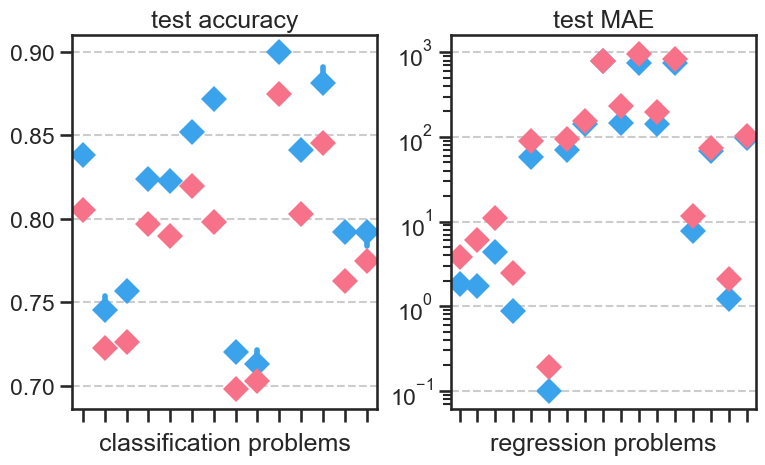

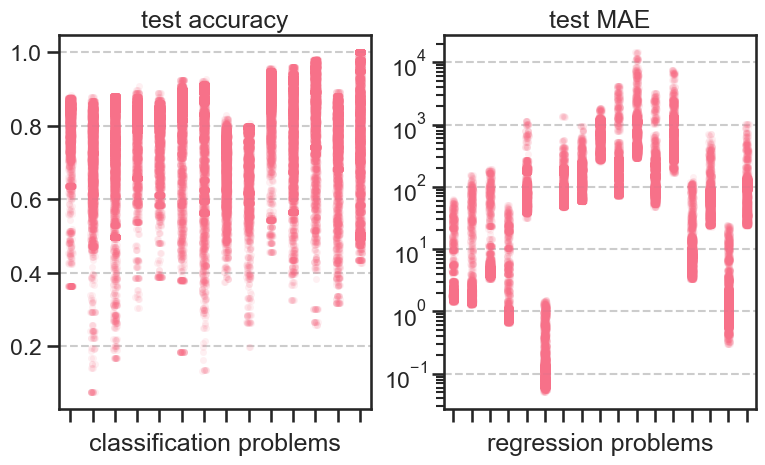

In [35]:
fig,ax=plt.subplots(1,2,figsize=(4*2,5))

df = pd.concat([out_agg_dict[file_name] for file_name in list_class_problems],keys=list_class_problems).reset_index()
metrics=scores_to_analyze_dict[list_class_problems[0]]
sns.pointplot(x='level_0',y='mean_'+metrics[0],data=df[(df['fold']=='test')],errorbar='ci',join=False,markers='D',ax=ax[0],estimator=np.median,color=sns.color_palette("husl")[4])
sns.pointplot(x='level_0',y='mean_'+metrics[0],data=df[(df['fold']=='test')],errorbar='ci',join=False,markers='D',ax=ax[0])

df = pd.concat([out_agg_dict[file_name] for file_name in list_reg_problems],keys=list_reg_problems).reset_index()
metrics=scores_to_analyze_dict[list_reg_problems[0]]
sns.pointplot(x='level_0',y='mean_'+metrics[0],data=df[(df['fold']=='test')],errorbar='ci',join=False,markers='D',ax=ax[1],estimator=np.median,color=sns.color_palette("husl")[4])
sns.pointplot(x='level_0',y='mean_'+metrics[0],data=df[(df['fold']=='test')],errorbar='ci',join=False,markers='D',ax=ax[1])

ax[0].set_xlabel('classification problems');  ax[0].set_title('test accuracy'); ax[0].set_xticks(ticks=np.arange(len(list_class_problems)), labels=['']*len(list_class_problems))
ax[1].set_xlabel('regression problems'); ax[1].set_title('test MAE'); ax[1].set_xticks(ticks=np.arange(len(list_reg_problems)), labels=['']*len(list_reg_problems)); ax[1].set_yscale('log')

for ax in plt.gcf().axes:
  ax.set_ylabel(''); ax.grid(axis='y',linestyle='--')

fig.tight_layout(w_pad=0.5)

fig,ax=plt.subplots(1,2,figsize=(4*2,5))

df = pd.concat([out_agg_dict[file_name] for file_name in list_class_problems],keys=list_class_problems).reset_index()
metrics=scores_to_analyze_dict[list_class_problems[0]]
sns.stripplot(x='level_0',y='mean_'+metrics[0],data=df[(df['fold']=='test')],ax=ax[0],alpha=0.1)

df = pd.concat([out_agg_dict[file_name] for file_name in list_reg_problems],keys=list_reg_problems).reset_index()
metrics=scores_to_analyze_dict[list_reg_problems[0]]
sns.stripplot(x='level_0',y='mean_'+metrics[0],data=df[(df['fold']=='test')],ax=ax[1],alpha=0.1)

ax[0].set_xlabel('classification problems');  ax[0].set_title('test accuracy'); ax[0].set_xticks(ticks=np.arange(len(list_class_problems)), labels=['']*len(list_class_problems))
ax[1].set_xlabel('regression problems'); ax[1].set_title('test MAE'); ax[1].set_xticks(ticks=np.arange(len(list_reg_problems)), labels=['']*len(list_reg_problems)); ax[1].set_yscale('log')

for ax in plt.gcf().axes:
  ax.set_ylabel(''); ax.grid(axis='y',linestyle='--')

fig.tight_layout(w_pad=0.5)

C:\Users\conno\AppData\Local\Temp\ipykernel_2100\1104237373.py:5: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(x='level_0',y='mean_'+metrics[1],data=df[(df['fold']=='test')],errorbar='ci',join=False,markers='D',ax=ax[0],estimator=np.median,color=sns.color_palette("husl")[4])
C:\Users\conno\AppData\Local\Temp\ipykernel_2100\1104237373.py:6: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(x='level_0',y='mean_'+metrics[1],data=df[(df['fold']=='test')],errorbar='ci',join=False,markers='D',ax=ax[0])
C:\Users\conno\AppData\Local\Temp\ipykernel_2100\1104237373.py:10: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(x='level_0',y='mean_'+metrics[1],data

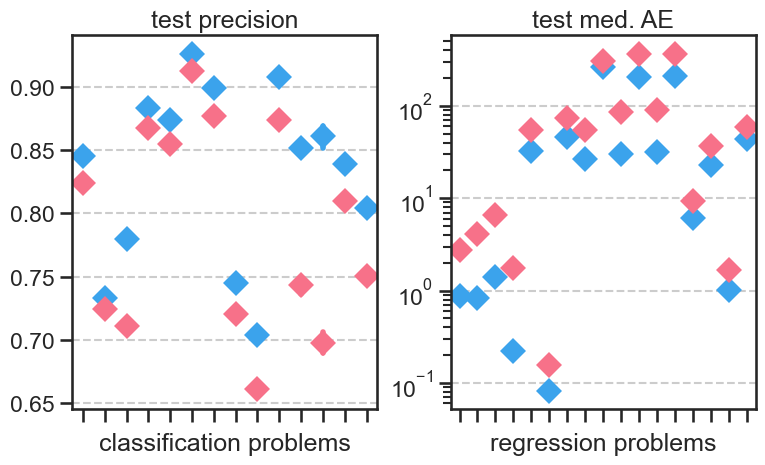

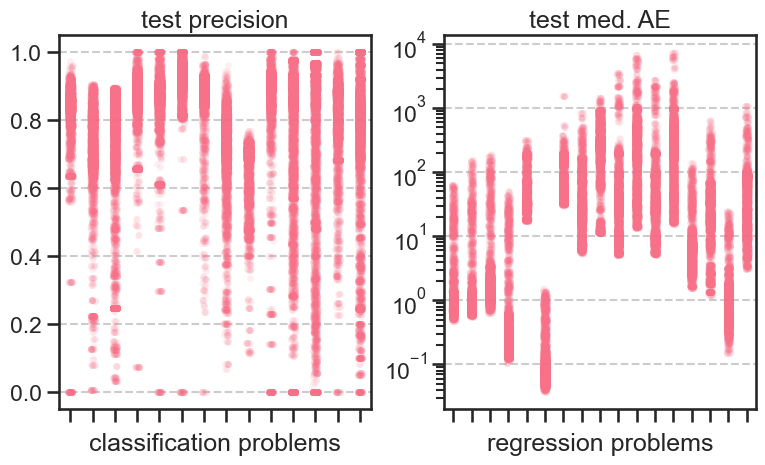

In [36]:
fig,ax=plt.subplots(1,2,figsize=(4*2,5))

df = pd.concat([out_agg_dict[file_name] for file_name in list_class_problems],keys=list_class_problems).reset_index()
metrics=scores_to_analyze_dict[list_class_problems[0]]
sns.pointplot(x='level_0',y='mean_'+metrics[1],data=df[(df['fold']=='test')],errorbar='ci',join=False,markers='D',ax=ax[0],estimator=np.median,color=sns.color_palette("husl")[4])
sns.pointplot(x='level_0',y='mean_'+metrics[1],data=df[(df['fold']=='test')],errorbar='ci',join=False,markers='D',ax=ax[0])

df = pd.concat([out_agg_dict[file_name] for file_name in list_reg_problems],keys=list_reg_problems).reset_index()
metrics=scores_to_analyze_dict[list_reg_problems[0]]
sns.pointplot(x='level_0',y='mean_'+metrics[1],data=df[(df['fold']=='test')],errorbar='ci',join=False,markers='D',ax=ax[1],estimator=np.median,color=sns.color_palette("husl")[4])
sns.pointplot(x='level_0',y='mean_'+metrics[1],data=df[(df['fold']=='test')],errorbar='ci',join=False,markers='D',ax=ax[1])

ax[0].set_xlabel('classification problems');  ax[0].set_title('test precision'); ax[0].set_xticks(ticks=np.arange(len(list_class_problems)), labels=['']*len(list_class_problems))
ax[1].set_xlabel('regression problems'); ax[1].set_title('test med. AE'); ax[1].set_xticks(ticks=np.arange(len(list_reg_problems)), labels=['']*len(list_reg_problems)); ax[1].set_yscale('log')

for ax in plt.gcf().axes:
  ax.set_ylabel(''); ax.grid(axis='y',linestyle='--')

fig.tight_layout(w_pad=0.5)

fig,ax=plt.subplots(1,2,figsize=(4*2,5))

df = pd.concat([out_agg_dict[file_name] for file_name in list_class_problems],keys=list_class_problems).reset_index()
metrics=scores_to_analyze_dict[list_class_problems[0]]
sns.stripplot(x='level_0',y='mean_'+metrics[1],data=df[(df['fold']=='test')],ax=ax[0],alpha=0.1)

df = pd.concat([out_agg_dict[file_name] for file_name in list_reg_problems],keys=list_reg_problems).reset_index()
metrics=scores_to_analyze_dict[list_reg_problems[0]]
sns.stripplot(x='level_0',y='mean_'+metrics[1],data=df[(df['fold']=='test')],ax=ax[1],alpha=0.1)

ax[0].set_xlabel('classification problems');  ax[0].set_title('test precision'); ax[0].set_xticks(ticks=np.arange(len(list_class_problems)), labels=['']*len(list_class_problems))
ax[1].set_xlabel('regression problems'); ax[1].set_title('test med. AE'); ax[1].set_xticks(ticks=np.arange(len(list_reg_problems)), labels=['']*len(list_reg_problems)); ax[1].set_yscale('log')

for ax in plt.gcf().axes:
  ax.set_ylabel(''); ax.grid(axis='y',linestyle='--')

fig.tight_layout(w_pad=0.5)

C:\Users\conno\AppData\Local\Temp\ipykernel_2100\3189351601.py:5: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(x='level_0',y='mean_'+metrics[2],data=df[(df['fold']=='test')],errorbar='ci',join=False,markers='D',ax=ax[0],estimator=np.median,color=sns.color_palette("husl")[4])
C:\Users\conno\AppData\Local\Temp\ipykernel_2100\3189351601.py:6: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(x='level_0',y='mean_'+metrics[2],data=df[(df['fold']=='test')],errorbar='ci',join=False,markers='D',ax=ax[0])
C:\Users\conno\AppData\Local\Temp\ipykernel_2100\3189351601.py:10: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(x='level_0',y='mean_'+metrics[2],data

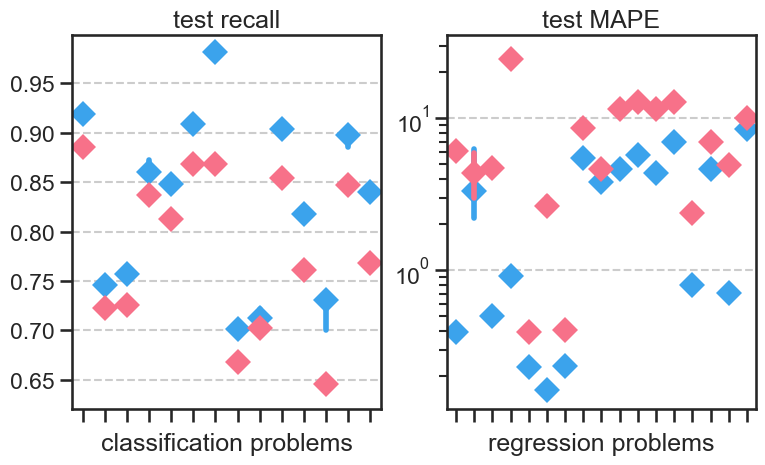

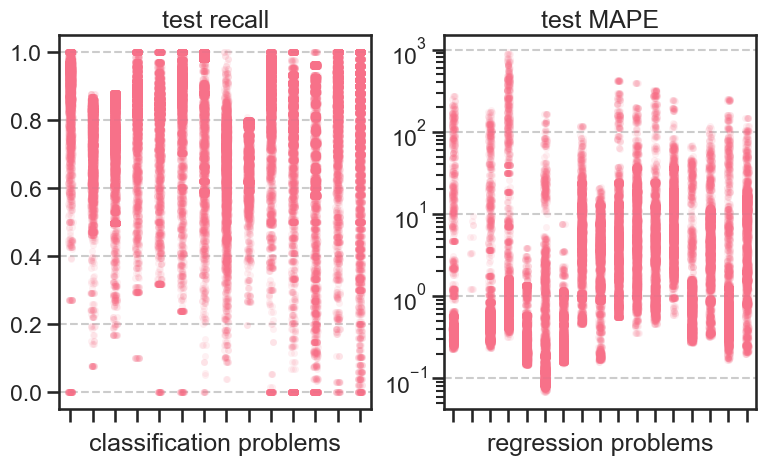

In [37]:
fig,ax=plt.subplots(1,2,figsize=(4*2,5))

df = pd.concat([out_agg_dict[file_name] for file_name in list_class_problems],keys=list_class_problems).reset_index()
metrics=scores_to_analyze_dict[list_class_problems[0]]
sns.pointplot(x='level_0',y='mean_'+metrics[2],data=df[(df['fold']=='test')],errorbar='ci',join=False,markers='D',ax=ax[0],estimator=np.median,color=sns.color_palette("husl")[4])
sns.pointplot(x='level_0',y='mean_'+metrics[2],data=df[(df['fold']=='test')],errorbar='ci',join=False,markers='D',ax=ax[0])

df = pd.concat([out_agg_dict[file_name] for file_name in list_reg_problems],keys=list_reg_problems).reset_index()
metrics=scores_to_analyze_dict[list_reg_problems[0]]
sns.pointplot(x='level_0',y='mean_'+metrics[2],data=df[(df['fold']=='test')],errorbar='ci',join=False,markers='D',ax=ax[1],estimator=np.median,color=sns.color_palette("husl")[4])
sns.pointplot(x='level_0',y='mean_'+metrics[2],data=df[(df['fold']=='test')],errorbar='ci',join=False,markers='D',ax=ax[1])

ax[0].set_xlabel('classification problems');  ax[0].set_title('test recall'); ax[0].set_xticks(ticks=np.arange(len(list_class_problems)), labels=['']*len(list_class_problems))
ax[1].set_xlabel('regression problems'); ax[1].set_title('test MAPE'); ax[1].set_xticks(ticks=np.arange(len(list_reg_problems)), labels=['']*len(list_reg_problems)); ax[1].set_yscale('log')

for ax in plt.gcf().axes:
  ax.set_ylabel(''); ax.grid(axis='y',linestyle='--')

fig.tight_layout(w_pad=0.5)

fig,ax=plt.subplots(1,2,figsize=(4*2,5))

df = pd.concat([out_agg_dict[file_name] for file_name in list_class_problems],keys=list_class_problems).reset_index()
metrics=scores_to_analyze_dict[list_class_problems[0]]
sns.stripplot(x='level_0',y='mean_'+metrics[2],data=df[(df['fold']=='test')],ax=ax[0],alpha=0.1)

df = pd.concat([out_agg_dict[file_name] for file_name in list_reg_problems],keys=list_reg_problems).reset_index()
metrics=scores_to_analyze_dict[list_reg_problems[0]]
sns.stripplot(x='level_0',y='mean_'+metrics[2],data=df[(df['fold']=='test')],ax=ax[1],alpha=0.1)

ax[0].set_xlabel('classification problems');  ax[0].set_title('test recall'); ax[0].set_xticks(ticks=np.arange(len(list_class_problems)), labels=['']*len(list_class_problems))
ax[1].set_xlabel('regression problems'); ax[1].set_title('test MAPE'); ax[1].set_xticks(ticks=np.arange(len(list_reg_problems)), labels=['']*len(list_reg_problems)); ax[1].set_yscale('log')

for ax in plt.gcf().axes:
  ax.set_ylabel(''); ax.grid(axis='y',linestyle='--')

fig.tight_layout(w_pad=0.5)


In [38]:
# Pick one classification task and inspect the merged frame's structure
t = list_class_problems[0]
m = scores_to_analyze_dict[t][0]
df = in_agg_out_splits_merge_dict[t]

print("task:", t, "| metric:", m)
print("shape:", df.shape)
print("columns:", list(df.columns))
print("\nkey cols present?",
      {c: (c in df.columns) for c in
       ['iteration','outer_k','inner_k','outer_split','algorithm','model_config_id',
        'combo_id','rank_as_mean_'+m,'rank_hpo_mean_'+m,'rank_cash_mean_'+m,
        'mean_'+m,'outer_'+m]})

task: ext_qual_binary | metric: accuracy
shape: (135360, 48)
columns: ['iteration', 'outer_k', 'outer_split', 'inner_k', 'fold', 'algorithm', 'model_config_id', 'params', 'mean_accuracy', 'mean_precision', 'mean_recall', 'mean_f1', 'median_accuracy', 'median_precision', 'median_recall', 'median_f1', 'std_accuracy', 'std_precision', 'std_recall', 'std_f1', 'max_accuracy', 'max_precision', 'max_recall', 'max_f1', 'min_accuracy', 'min_precision', 'min_recall', 'min_f1', 'default_config', 'rank_as_mean_accuracy', 'rank_as_mean_precision', 'rank_as_mean_recall', 'rank_as_mean_f1', 'rank_hpo_mean_accuracy', 'rank_hpo_mean_precision', 'rank_hpo_mean_recall', 'rank_hpo_mean_f1', 'rank_cash_mean_accuracy', 'rank_cash_mean_precision', 'rank_cash_mean_recall', 'rank_cash_mean_f1', 'combo_id', 'loopfold', 'nested_cv', 'outer_accuracy', 'outer_precision', 'outer_recall', 'outer_f1']

key cols present? {'iteration': True, 'outer_k': True, 'inner_k': True, 'outer_split': True, 'algorithm': True, 'mod

In [39]:
# Within one selection cell, does rank==1 correspond to the BEST inner mean_<metric>?
cell = df[(df['iteration']==df['iteration'].iloc[0]) &
          (df['outer_k']==df['outer_k'].iloc[0]) &
          (df['inner_k']==df['inner_k'].iloc[0])]
# CASH ranks everything together; check rank vs inner score ordering
chk = cell[['combo_id','mean_'+m,'outer_'+m,'rank_cash_mean_'+m]].sort_values('rank_cash_mean_'+m)
print(chk.head(8).to_string(index=False))
print("\nrank==1 has the max inner mean_%s in this cell?" % m,
      (chk.iloc[0]['mean_'+m] == cell['mean_'+m].max()))

combo_id  mean_accuracy  outer_accuracy  rank_cash_mean_accuracy
   SVM12       0.869863        0.862069                      1.0
   SVM18       0.869863        0.862069                      1.0
   SVM18       0.862158        0.869863                      1.0
     GP0       0.862158        0.869863                      1.0
     GP4       0.862158        0.869863                      1.0
   SVM12       0.862158        0.869863                      1.0
     GP6       0.862158        0.869863                      1.0
     GB5       0.863014        0.855172                      3.0

rank==1 has the max inner mean_accuracy in this cell? True


In [41]:
t = list_class_problems[0]
m = scores_to_analyze_dict[t][0]
df = in_agg_out_splits_merge_dict[t]

# Fully specify a cell INCLUDING outer_split and inner_k, one algorithm/config
sub = df[(df['iteration']==df['iteration'].iloc[0]) &
         (df['outer_k']==df['outer_k'].iloc[0]) &
         (df['combo_id']=='SVM12')]
print("SVM12 rows in this (iteration, outer_k):", len(sub))
print("varying across those rows:")
for c in ['inner_k','outer_split','fold','mean_'+m,'outer_'+m]:
    if c in sub.columns:
        print(f"  {c}: {sorted(sub[c].unique())}")
print()
print(sub[['inner_k','outer_split','fold','mean_'+m,'outer_'+m]].sort_values(['inner_k','outer_split']).to_string(index=False))

SVM12 rows in this (iteration, outer_k): 10
varying across those rows:
  inner_k: [np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(10)]
  outer_split: [np.int64(0), np.int64(1)]
  fold: ['val']
  mean_accuracy: [np.float64(0.8619614666666666), np.float64(0.8620689559999999), np.float64(0.862157525), np.float64(0.862237225), np.float64(0.8623809619999999), np.float64(0.86974475), np.float64(0.869863005), np.float64(0.8700000210000001), np.float64(0.8700396666666667), np.float64(0.870114936)]
  outer_accuracy: [np.float64(0.86206895), np.float64(0.86986303)]

 inner_k  outer_split fold  mean_accuracy  outer_accuracy
       2            0  val       0.862158        0.869863
       2            1  val       0.869863        0.862069
       3            0  val       0.861961        0.869863
       3            1  val       0.870040        0.862069
       4            0  val       0.862237        0.869863
       4            1  val       0.869745        0.862069
       5         

In [40]:
# For one specific model in one iteration/outer_k, how many rows, and how many UNIQUE outer values?
one_model = df[(df['iteration']==df['iteration'].iloc[0]) &
               (df['outer_k']==df['outer_k'].iloc[0]) &
               (df['combo_id']==df['combo_id'].iloc[0])]
print("rows for this (iteration,outer_k,combo_id):", len(one_model))
print("unique inner_k:", one_model['inner_k'].nunique(),
      "| unique outer_split:", one_model['outer_split'].nunique() if 'outer_split' in one_model else 'n/a')
print("unique outer_%s values:" % m, one_model['outer_'+m].nunique(),
      "| unique inner mean_%s values:" % m, one_model['mean_'+m].nunique())
print(one_model[['inner_k','outer_split' if 'outer_split' in one_model else 'combo_id',
                 'mean_'+m,'outer_'+m]].to_string(index=False))

rows for this (iteration,outer_k,combo_id): 10
unique inner_k: 5 | unique outer_split: 2
unique outer_accuracy values: 2 | unique inner mean_accuracy values: 10
 inner_k  outer_split  mean_accuracy  outer_accuracy
       2            0       0.758847        0.643836
       2            1       0.732877        0.806897
       3            0       0.785998        0.643836
       3            1       0.726757        0.806897
       4            0       0.786224        0.643836
       4            1       0.691441        0.806897
       5            0       0.724138        0.643836
       5            1       0.691724        0.806897
      10            0       0.760952        0.643836
      10            1       0.725714        0.806897


In [42]:
t = list_class_problems[0]
m = scores_to_analyze_dict[t][0]
df_nested = in_agg_out_splits_merge_dict[t]      # nested denominator source
df_single = out_agg_dict[t]                       # single numerator source
df_single = df_single[df_single['fold']=='test']

# The two groupby indices that get divided in the direct single:nested plot (AS branch):
num = df_single[df_single['rank_as_mean_'+m]==1].groupby(['iteration','outer_k'],sort=False)['mean_'+m].mean()
den = df_nested[df_nested['rank_as_mean_'+m]==1].groupby(['iteration','outer_k'],sort=False)['outer_'+m].mean()

print("numerator index (out_agg) == denominator index (nested)?", num.index.equals(den.index))
print("num shape:", num.shape, "| den shape:", den.shape)
print("\nnum index sample:", list(num.index[:4]))
print("den index sample:", list(den.index[:4]))
print("\naligned preview:")
import pandas as pd
print(pd.DataFrame({'single(num)':num, 'nested(den)':den, 'ratio':num/den}).head(6).to_string())

numerator index (out_agg) == denominator index (nested)? True
num shape: (15,) | den shape: (15,)

num index sample: [(0, 2), (0, 3), (0, 4), (0, 5)]
den index sample: [(0, 2), (0, 3), (0, 4), (0, 5)]

aligned preview:
                   single(num)  nested(den)     ratio
iteration outer_k                                    
0         2           0.876264     0.866266  1.011541
          3           0.869416     0.861945  1.008667
          4           0.866010     0.856385  1.011239
          5           0.869375     0.867630  1.002010
          10          0.865862     0.854265  1.013576
1         2           0.872839     0.866066  1.007820


In [43]:
tr = list_reg_problems[0]                       # a regression task
mr = scores_to_analyze_dict[tr][0]              # should be 'MAE' AFTER modify_regression_datasets
print("regression task:", tr, "| metric[0]:", mr)

# (A) In the PROCESSED reg frame, is MAE stored POSITIVE (post-flip) and does rank order it correctly?
r = out_agg_dict[tr]
r = r[r['fold']=='test']
print("\n(A) processed frame:")
print("  mean_%s min/max:" % mr, round(r['mean_'+mr].min(),3), "/", round(r['mean_'+mr].max(),3),
      "-> should be POSITIVE (>=0)")
# does rank_as==1 pick the LOWEST MAE among defaults (lower error = better)?
cell = r[(r['iteration']==r['iteration'].iloc[0]) & (r['outer_k']==r['outer_k'].iloc[0]) & (r['default_config']=='default')]
best = cell[cell['rank_as_mean_'+mr]==1]['mean_'+mr].iloc[0]
print("  rank_as==1 mean_%s = %.4f | min default mean_%s = %.4f | match?" %
      (mr, best, mr, cell['mean_'+mr].min()), best == cell['mean_'+mr].min())

# (B) Confirm the column got RENAMED (neg_ -> MAE) and no stray neg_ MAE columns remain
neg_cols = [c for c in r.columns if 'neg_' in c]
print("\n(B) leftover neg_ columns:", neg_cols if neg_cols else "none (rename complete)")

# (C) max_error sign check (we flagged this one specifically)
maxerr = [c for c in r.columns if 'max_error' in c]
print("\n(C) max_error-related columns:", maxerr)
if maxerr:
    print("  sample values:", r[maxerr[0]].dropna().head(3).round(3).tolist(),
          "-> POSITIVE means flipped; NEGATIVE means still neg_ (would break lower-is-better logic)")

regression task: ext_quant_avg_force | metric[0]: MAE

(A) processed frame:
  mean_MAE min/max: 1.424 / 63.652 -> should be POSITIVE (>=0)
  rank_as==1 mean_MAE = 1.6971 | min default mean_MAE = 1.6971 | match? True

(B) leftover neg_ columns: none (rename complete)

(C) max_error-related columns: []
